# PINN flux reconstruction - Koppel-Martin Case 1 no-fracture control (same workflow)


In [1]:
from mpi4py import MPI
from petsc4py import PETSc
import pathlib
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import LogNorm
import ufl
import basix.ufl
import torch
import torch.nn as nn
from tqdm.auto import tqdm

from dolfinx import fem, geometry, mesh

comm = MPI.COMM_WORLD
rank = comm.rank
if comm.size != 1:
    raise RuntimeError('This manual point-trace assembly notebook is serial; run it with one MPI rank.')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(1234)
np.random.seed(1234)

REF = 6  # n_bulk = 128, matching the no-fracture MRST/TPFA export grid
RUN_CONVERGENCE = False
ORDER = 1

K_M_VALUE = 1.0
K_F_VALUE = 10.0
NO_FRACTURE_CASE = True

# Diagnostic line kept only so the inherited plotting/PINN helpers have symbols.
# It is not used as an embedded fracture in this no-fracture control notebook.
FRAC_A = np.array([0.25, 0.0], dtype=float)
FRAC_B = np.array([0.75, 1.0], dtype=float)
TIP_FRAC = 0.05


/home/muchamad/PhD/fenicsx/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def unit(v):
    v = np.asarray(v, dtype=float)
    nrm = np.linalg.norm(v)
    if nrm == 0.0:
        raise ValueError("zero-length vector")
    return v / nrm

tau_np = unit(FRAC_B - FRAC_A)
normal_np = np.array([-tau_np[1], tau_np[0]], dtype=float)
L_gamma = float(np.linalg.norm(FRAC_B - FRAC_A))

_G3 = np.array([0.5 - 0.5 * np.sqrt(3.0 / 5.0), 0.5, 0.5 + 0.5 * np.sqrt(3.0 / 5.0)], dtype=float)
_W3 = np.array([5.0 / 18.0, 4.0 / 9.0, 5.0 / 18.0], dtype=float)
_G3_SYM = np.array([-np.sqrt(3.0 / 5.0), 0.0, np.sqrt(3.0 / 5.0)], dtype=float)
_W3_SYM = np.array([5.0 / 9.0, 8.0 / 9.0, 5.0 / 9.0], dtype=float)


def real_points_np(s):
    s = np.asarray(s, dtype=float).reshape(-1)
    return FRAC_A[None, :] + s[:, None] * tau_np[None, :]


def signed_distance_np(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    if globals().get("NO_FRACTURE_CASE", False):
        # No fracture partition: keep all points on one network branch and
        # avoid masking a fictitious band from the PINN training data.
        return np.ones(pts.shape[0], dtype=float)
    return (pts[:, :2] - FRAC_A) @ normal_np


def s_coord_np(points):
    return (np.asarray(points, dtype=float)[:, :2] - FRAC_A) @ tau_np


def estimate_bulk_h(omega):
    coords = omega.geometry.x

    def min_positive_spacing(values):
        vals = np.unique(np.round(np.sort(values), 14))
        diffs = np.diff(vals)
        diffs = diffs[diffs > 1.0e-12]
        return float(diffs.min()) if diffs.size else np.inf

    return min(min_positive_spacing(coords[:, 0]), min_positive_spacing(coords[:, 1]))


def make_line_mesh_from_s_nodes(s_nodes):
    s_nodes = np.asarray(s_nodes, dtype=float)
    nodes = real_points_np(s_nodes)
    n_cells = len(s_nodes) - 1
    cells = np.column_stack([np.arange(n_cells), np.arange(1, n_cells + 1)]).astype(np.int64)
    coord_el = ufl.Mesh(basix.ufl.element("Lagrange", basix.CellType.interval, 1, shape=(2,)))
    gamma_mesh = mesh.create_mesh(comm, cells, coord_el, nodes)
    return gamma_mesh, float(np.max(np.diff(s_nodes))), int(n_cells)


def make_fracture_pressure_mesh(h):
    # Fracture pressure remains P1 on a relatively fine independent mesh.
    h_gamma_target = 0.5 * h
    n_gamma = max(1, int(np.ceil(L_gamma / h_gamma_target)))
    s_nodes = np.linspace(0.0, L_gamma, n_gamma + 1)
    return make_line_mesh_from_s_nodes(s_nodes)


def make_multiplier_mesh(h):
    # Koppel-Martin case-1 setting for P0 multipliers: h_lambda approx 2h.
    h_lambda_target = 2.0 * h
    n_lambda = max(1, int(round(L_gamma / h_lambda_target)))
    s_nodes = np.linspace(0.0, L_gamma, n_lambda + 1)
    return make_line_mesh_from_s_nodes(s_nodes)


def make_nonconforming_meshes(ref):
    n_bulk = 2 ** (ref + 1)
    omega = mesh.create_unit_square(comm, n_bulk, n_bulk, cell_type=mesh.CellType.quadrilateral)
    h = estimate_bulk_h(omega)
    gamma, h_gamma, n_gamma = make_fracture_pressure_mesh(h)
    gamma_l, h_lambda, n_lambda = make_multiplier_mesh(h)
    return omega, gamma, gamma_l, h, h_gamma, h_lambda, n_bulk, n_gamma, n_lambda


def quad_points_weights():
    pts, weights = [], []
    for i, xi in enumerate(_G3):
        for j, eta in enumerate(_G3):
            pts.append([xi, eta])
            weights.append(_W3[i] * _W3[j])
    return np.asarray(pts, dtype=float), np.asarray(weights, dtype=float)


def _space_ndofs(V):
    return int(V.dofmap.index_map.size_global * V.dofmap.index_map_bs)


def polygon_signed_area(poly):
    x = poly[:, 0]
    y = poly[:, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)


def order_polygon_vertices(pts):
    pts = np.asarray(pts, dtype=float)
    ctr = pts.mean(axis=0)
    ang = np.arctan2(pts[:, 1] - ctr[1], pts[:, 0] - ctr[0])
    poly = pts[np.argsort(ang)]
    if polygon_signed_area(poly) < 0:
        poly = poly[::-1]
    return poly


def build_bulk_cell_data(omega, V_m, n_bulk):
    tdim = omega.topology.dim
    omega.topology.create_connectivity(tdim, 0)
    c2v = omega.topology.connectivity(tdim, 0)
    dof_coords = V_m.tabulate_dof_coordinates()[:, :2]
    geom = omega.geometry.x[:, :2]
    h = 1.0 / n_bulk
    cells = []
    lookup = {}
    num_cells = omega.topology.index_map(tdim).size_local
    for ci in range(num_cells):
        verts = np.asarray(c2v.links(ci), dtype=np.int32)
        poly = order_polygon_vertices(geom[verts])
        x0, y0 = poly.min(axis=0)
        x1, y1 = poly.max(axis=0)
        dofs = np.asarray(V_m.dofmap.cell_dofs(ci), dtype=np.int32)
        cell = {
            "cell_id": int(ci),
            "dofs": dofs,
            "dof_xy": dof_coords[dofs],
            "poly": poly,
            "x0": float(x0),
            "x1": float(x1),
            "y0": float(y0),
            "y1": float(y1),
            "hx": float(x1 - x0),
            "hy": float(y1 - y0),
            "centroid": np.array([0.5 * (x0 + x1), 0.5 * (y0 + y1)], dtype=float),
        }
        cells.append(cell)
        ix = int(round(x0 / h))
        iy = int(round(y0 / h))
        lookup[(ix, iy)] = int(ci)
    return {"cells": cells, "lookup": lookup, "n_bulk": int(n_bulk), "h": float(h)}


def locate_bulk_cell_xy(pt, bulk_data):
    x, y = np.asarray(pt, dtype=float)[:2]
    n = bulk_data["n_bulk"]
    h = bulk_data["h"]
    tol = 1e-12
    ix = n - 1 if x >= 1.0 - tol else int(np.floor(max(x, 0.0) / h))
    iy = n - 1 if y >= 1.0 - tol else int(np.floor(max(y, 0.0) / h))
    ix = min(max(ix, 0), n - 1)
    iy = min(max(iy, 0), n - 1)
    return bulk_data["cells"][bulk_data["lookup"][(ix, iy)]]


def q1_values_grads_on_cell(cell, points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    x = pts[:, 0]
    y = pts[:, 1]
    x0, x1, y0, y1 = cell["x0"], cell["x1"], cell["y0"], cell["y1"]
    hx, hy = cell["hx"], cell["hy"]
    vals = np.zeros((pts.shape[0], len(cell["dofs"])), dtype=float)
    grads = np.zeros((pts.shape[0], len(cell["dofs"]), 2), dtype=float)
    xmid = 0.5 * (x0 + x1)
    ymid = 0.5 * (y0 + y1)
    for a, xy in enumerate(cell["dof_xy"]):
        if xy[0] < xmid:
            px = (x1 - x) / hx
            dpx = np.full_like(x, -1.0 / hx)
        else:
            px = (x - x0) / hx
            dpx = np.full_like(x, 1.0 / hx)
        if xy[1] < ymid:
            py = (y1 - y) / hy
            dpy = np.full_like(y, -1.0 / hy)
        else:
            py = (y - y0) / hy
            dpy = np.full_like(y, 1.0 / hy)
        vals[:, a] = px * py
        grads[:, a, 0] = dpx * py
        grads[:, a, 1] = px * dpy
    return vals, grads


def bulk_breakpoints_on_segment(xa, xb, bulk_data, tol=1e-12):
    xa = np.asarray(xa, dtype=float)
    xb = np.asarray(xb, dtype=float)
    d = xb - xa
    n = bulk_data["n_bulk"]
    h = bulk_data["h"]
    out = [0.0, 1.0]
    if abs(d[0]) > tol:
        lo, hi = sorted([xa[0], xb[0]])
        k0 = max(1, int(np.floor(lo / h)) + 1)
        k1 = min(n - 1, int(np.ceil(hi / h)))
        for k in range(k0, k1 + 1):
            r = (k * h - xa[0]) / d[0]
            if tol < r < 1.0 - tol:
                out.append(float(r))
    if abs(d[1]) > tol:
        lo, hi = sorted([xa[1], xb[1]])
        k0 = max(1, int(np.floor(lo / h)) + 1)
        k1 = min(n - 1, int(np.ceil(hi / h)))
        for k in range(k0, k1 + 1):
            r = (k * h - xa[1]) / d[1]
            if tol < r < 1.0 - tol:
                out.append(float(r))
    return np.asarray(sorted(set(np.round(out, 14))), dtype=float)


In [3]:
def assemble_bulk_stiffness(A, bulk_data):
    qp, qw = quad_points_weights()
    for cell in bulk_data["cells"]:
        x_phys = np.column_stack([
            cell["x0"] + qp[:, 0] * cell["hx"],
            cell["y0"] + qp[:, 1] * cell["hy"],
        ])
        _, grads = q1_values_grads_on_cell(cell, x_phys)
        area = cell["hx"] * cell["hy"]
        Ke = K_M_VALUE * area * np.einsum("q,qid,qjd->ij", qw, grads, grads)
        A.setValues(cell["dofs"], cell["dofs"], Ke, addv=PETSc.InsertMode.ADD_VALUES)


def build_fracture_pressure_data(gamma, V_f):
    coords_f = V_f.tabulate_dof_coordinates()[:, :2]
    cells = []
    s_nodes = []
    num_gamma_cells = gamma.topology.index_map(gamma.topology.dim).size_local
    for ci in range(num_gamma_cells):
        fdofs = np.asarray(V_f.dofmap.cell_dofs(ci), dtype=np.int32)
        s = s_coord_np(coords_f[fdofs])
        order = np.argsort(s)
        fdofs = fdofs[order]
        s = s[order]
        cells.append({"dofs": fdofs, "s0": float(s[0]), "s1": float(s[1])})
        s_nodes.extend([float(s[0]), float(s[1])])
    s_nodes = np.array(sorted(set(np.round(s_nodes, 14))), dtype=float)
    starts = np.array([c["s0"] for c in cells], dtype=float)
    order = np.argsort(starts)
    cells = [cells[i] for i in order]
    return {"cells": cells, "s_nodes": s_nodes}


def locate_pressure_cell_s(s, pressure_data, tol=1e-12):
    cells = pressure_data["cells"]
    if s <= cells[0]["s0"] + tol:
        return cells[0]
    if s >= cells[-1]["s1"] - tol:
        return cells[-1]
    starts = np.array([c["s0"] for c in cells], dtype=float)
    idx = int(np.searchsorted(starts, s, side="right") - 1)
    return cells[min(max(idx, 0), len(cells) - 1)]


def p1_line_basis_on_pressure_cell(cell, s):
    ell = cell["s1"] - cell["s0"]
    return np.array([(cell["s1"] - s) / ell, (s - cell["s0"]) / ell], dtype=float)


def line_mesh_cell_s_intervals(domain):
    domain.topology.create_connectivity(domain.topology.dim, 0)
    c2v = domain.topology.connectivity(domain.topology.dim, 0)
    coords = domain.geometry.x[:, :2]
    intervals = []
    for ci in range(domain.topology.index_map(domain.topology.dim).size_local):
        verts = np.asarray(c2v.links(ci), dtype=np.int32)
        s = np.sort(s_coord_np(coords[verts]))
        intervals.append((float(s[0]), float(s[1])))
    return intervals


def s_breakpoints(s0, s1, s_nodes, tol=1e-12):
    inside = s_nodes[(s_nodes > s0 + tol) & (s_nodes < s1 - tol)]
    return np.concatenate(([s0], inside, [s1])).astype(float)


def assemble_fracture_and_trace_blocks(A, gamma, gamma_l, V_f, V_l, bulk_data, offsets):
    off_m, off_f, off_l = offsets
    pressure_data = build_fracture_pressure_data(gamma, V_f)

    for cell in pressure_data["cells"]:
        fdofs = cell["dofs"]
        ell = cell["s1"] - cell["s0"]
        Kloc = (K_F_VALUE / ell) * np.array([[1.0, -1.0], [-1.0, 1.0]], dtype=float)
        A.setValues(off_f + fdofs, off_f + fdofs, Kloc, addv=PETSc.InsertMode.ADD_VALUES)

    for ci, (s0, s1) in enumerate(line_mesh_cell_s_intervals(gamma_l)):
        ldofs = np.asarray(V_l.dofmap.cell_dofs(ci), dtype=np.int32)
        xa, xb = real_points_np([s0, s1])
        seg = xb - xa
        ell = float(np.linalg.norm(seg))

        pbreaks = s_breakpoints(s0, s1, pressure_data["s_nodes"])
        for a, b in zip(pbreaks[:-1], pbreaks[1:]):
            if b - a <= 1e-14:
                continue
            pcell = locate_pressure_cell_s(0.5 * (a + b), pressure_data)
            fdofs = pcell["dofs"]
            for q, w in zip(_G3, _W3):
                sq = a + (b - a) * q
                psi = p1_line_basis_on_pressure_cell(pcell, sq)
                weight = (b - a) * w
                A.setValues(off_f + fdofs, off_l + ldofs, (weight * psi).reshape(-1, 1), addv=PETSc.InsertMode.ADD_VALUES)
                A.setValues(off_l + ldofs, off_f + fdofs, (-weight * psi).reshape(1, -1), addv=PETSc.InsertMode.ADD_VALUES)

        breaks = bulk_breakpoints_on_segment(xa, xb, bulk_data)
        for r0, r1 in zip(breaks[:-1], breaks[1:]):
            if r1 - r0 <= 1e-14:
                continue
            mid = xa + 0.5 * (r0 + r1) * seg
            bulk_cell = locate_bulk_cell_xy(mid, bulk_data)
            mdofs = bulk_cell["dofs"]
            for q, w in zip(_G3, _W3):
                r = r0 + (r1 - r0) * q
                xq = xa + r * seg
                phi = q1_values_grads_on_cell(bulk_cell, xq[None, :])[0][0]
                weight = ell * (r1 - r0) * w
                A.setValues(mdofs, off_l + ldofs, (-weight * phi).reshape(-1, 1), addv=PETSc.InsertMode.ADD_VALUES)
                A.setValues(off_l + ldofs, mdofs, (weight * phi).reshape(1, -1), addv=PETSc.InsertMode.ADD_VALUES)


def apply_pressure_bcs(A, b, V_m, V_f, offsets):
    off_m, off_f, off_l = offsets
    coords_m = V_m.tabulate_dof_coordinates()[:, :2]
    tol = 1e-12

    left = np.where(np.isclose(coords_m[:, 0], 0.0, atol=tol))[0].astype(np.int32)
    right = np.where(np.isclose(coords_m[:, 0], 1.0, atol=tol))[0].astype(np.int32)

    # Matrix pressure is Dirichlet on x=0 and x=1.  The fracture pressure
    # endpoints are left unconstrained, so the natural boundary condition on
    # Gamma is homogeneous Neumann (no fracture-tip throughflow).
    bc_idx = np.concatenate([off_m + left, off_m + right]).astype(np.int32)
    bc_vals = np.concatenate([
        np.full(len(left), 1.0),
        np.full(len(right), 4.0),
    ]).astype(float)

    x_bc = A.createVecRight()
    x_bc.set(0.0)
    x_bc.setValues(bc_idx, bc_vals)
    x_bc.assemble()
    A.zeroRowsColumns(bc_idx, diag=1.0, x=x_bc, b=b)
    return bc_idx, bc_vals

def solve_petsc_lu(A, b, prefix):
    x = A.createVecRight()
    x.set(0.0)
    last_error = None
    for factor_solver in ("mumps", None):
        try:
            ksp = PETSc.KSP().create(comm)
            ksp.setOptionsPrefix(prefix)
            ksp.setOperators(A)
            ksp.setType(PETSc.KSP.Type.PREONLY)
            pc = ksp.getPC()
            pc.setType(PETSc.PC.Type.LU)
            if factor_solver is not None:
                pc.setFactorSolverType(factor_solver)
            ksp.setFromOptions()
            ksp.solve(b, x)
            reason = ksp.getConvergedReason()
            if reason < 0:
                raise RuntimeError(f"PETSc KSP failed with reason {reason}")
            return x, factor_solver or "petsc-lu"
        except Exception as exc:
            last_error = exc
            if factor_solver is None:
                raise
    raise RuntimeError("LU solve failed") from last_error



def solve_lcg_koppel_martin(ref=REF, order=ORDER, verbose=False):
    """Matrix-only CG solve for the no-fracture control.

    The original notebook name is kept so the downstream workflow can stay
    unchanged. With left/right Dirichlet pressure p=1/4 and no top/bottom flux,
    the Q1 solution is the exact linear field p_h=1+3x on the same 128x128 grid.
    """
    if order != 1:
        raise ValueError("The no-fracture control is implemented for Q1 only.")
    n_bulk = 2 ** (ref + 1)
    omega = mesh.create_unit_square(comm, n_bulk, n_bulk, cell_type=mesh.CellType.quadrilateral)
    h = estimate_bulk_h(omega)
    V_m = fem.functionspace(omega, ("Lagrange", 1))
    bulk_data = build_bulk_cell_data(omega, V_m, n_bulk)

    p_m = fem.Function(V_m, name="p_m")
    coords_m = V_m.tabulate_dof_coordinates()[:, :2]
    p_m.x.array[:] = 1.0 + 3.0 * coords_m[:, 0]
    p_m.x.scatter_forward()

    k_m = fem.Constant(omega, np.eye(2, dtype=np.float64))
    coords = omega.geometry.x
    xmin, xmax = float(coords[:, 0].min()), float(coords[:, 0].max())
    ymin, ymax = float(coords[:, 1].min()), float(coords[:, 1].max())

    left = np.where(np.isclose(coords_m[:, 0], 0.0, atol=1e-12))[0].astype(np.int32)
    right = np.where(np.isclose(coords_m[:, 0], 1.0, atol=1e-12))[0].astype(np.int32)
    bc_idx = np.concatenate([left, right]).astype(np.int32)
    bc_vals = np.concatenate([np.full(len(left), 1.0), np.full(len(right), 4.0)]).astype(float)

    n_m = _space_ndofs(V_m)
    if verbose:
        print("Matrix-only no-fracture pressure field: p_h(x,y)=1+3x")
        print(f"n_bulk={n_bulk}, h={h:.3e}")
        print(f"dofs: matrix={n_m}, fracture=0, lambda=0, total={n_m}")

    return {
        "ref": int(ref),
        "omega": omega,
        "gamma": None,
        "gamma_l": None,
        "V_m": V_m,
        "V_f": None,
        "V_l": None,
        "p_m": p_m,
        "p_f": None,
        "lmbd": None,
        "k_m": k_m,
        "k_f": None,
        "h": float(h),
        "h_gamma": np.nan,
        "h_lambda": np.nan,
        "n_bulk": int(n_bulk),
        "n_gamma": 0,
        "n_lambda": 0,
        "bulk_data": bulk_data,
        "bbox": (xmin, xmax, ymin, ymax),
        "bc_idx": bc_idx,
        "bc_vals": bc_vals,
        "ndof_total": int(n_m),
        "factor_solver": "exact-linear-no-fracture",
    }


t0 = time.perf_counter()
sol = solve_lcg_koppel_martin(REF, ORDER, verbose=True)
print(f"LCG solve complete in {time.perf_counter() - t0:.2f} s")
print(
    f"ref={sol['ref']} h={sol['h']:.3e} n_bulk={sol['n_bulk']} "
    f"total dofs={sol['ndof_total']} (no fracture)"
)
omega = sol["omega"]; gamma = sol["gamma"]; gamma_l = sol["gamma_l"]
V_m = sol["V_m"]; V_f = sol["V_f"]; V_l = sol["V_l"]
p_m = sol["p_m"]; p_f = sol["p_f"]; lmbd = sol["lmbd"]; k_m = sol["k_m"]
h = sol["h"]; h_est = h
xmin, xmax, ymin, ymax = sol["bbox"]


Matrix-only no-fracture pressure field: p_h(x,y)=1+3x
n_bulk=128, h=7.812e-03
dofs: matrix=16641, fracture=0, lambda=0, total=16641
LCG solve complete in 1.76 s
ref=6 h=7.812e-03 n_bulk=128 total dofs=16641 (no fracture)


In [4]:
def edge_length(a, b):
    return float(np.linalg.norm(np.asarray(b, dtype=float) - np.asarray(a, dtype=float)))


def outward_edge_normal(a, b, centroid):
    t = np.asarray(b, dtype=float) - np.asarray(a, dtype=float)
    n1 = np.array([t[1], -t[0]], dtype=float)
    n2 = -n1
    mid = 0.5 * (np.asarray(a, dtype=float) + np.asarray(b, dtype=float))
    chosen = n1 if np.dot(n1, mid - centroid) > 0.0 else n2
    return chosen / (np.linalg.norm(chosen) + 1e-30)


tdim = omega.topology.dim
gdim = omega.geometry.dim
omega.topology.create_connectivity(tdim, 0)
c2v = omega.topology.connectivity(tdim, 0)
omega_geometry = omega.geometry.x
num_cells = omega.topology.index_map(tdim).size_local
local_cell_vertices = [np.asarray(c2v.links(c), dtype=np.int32) for c in range(num_cells)]

# Actual 2D mesh-cell polygons, ordered counter-clockwise for geometry work.
cell_polys = [order_polygon_vertices(omega_geometry[verts, :2]) for verts in local_cell_vertices]
cell_centroids = np.vstack([poly.mean(axis=0) for poly in cell_polys])
cell_areas = np.asarray([abs(polygon_signed_area(poly)) for poly in cell_polys])


def edge_key(x0, x1, decimals=12):
    a = tuple(np.round(x0, decimals))
    b = tuple(np.round(x1, decimals))
    return tuple(sorted((a, b)))


shadow_edges = []
seen_edges = set()
for poly in cell_polys:
    for j in range(len(poly)):
        key = edge_key(poly[j], poly[(j + 1) % len(poly)])
        if key not in seen_edges:
            seen_edges.add(key)
            shadow_edges.append((poly[j].copy(), poly[(j + 1) % len(poly)].copy()))
print("2D quad cells:", num_cells, "unique edges:", len(shadow_edges))

Wq = fem.functionspace(omega, ("DG", ORDER, (gdim,)))
_q_pts = Wq.element.interpolation_points
q_cg_expr = fem.Expression(-ufl.dot(k_m, ufl.grad(p_m)), _q_pts)
q_cg_fun = fem.Function(Wq, name="q_cg")
q_cg_fun.interpolate(q_cg_expr)


def as_eval_points(points):
    points = np.asarray(points, dtype=float)
    if points.ndim == 1:
        points = points.reshape(1, -1)
    if points.shape[1] == 3:
        return points.copy()
    return np.column_stack([points[:, :2], np.zeros(points.shape[0])])


_BBTREE_CACHE = {}


def _get_bbtree(domain):
    key = id(domain)
    tree = _BBTREE_CACHE.get(key)
    if tree is None:
        tree = geometry.bb_tree(domain, domain.topology.dim)
        _BBTREE_CACHE[key] = tree
    return tree


def eval_fem_function(fun, points, domain=None):
    if domain is None:
        domain = fun.function_space.mesh
    pts3 = as_eval_points(points)
    tree = _get_bbtree(domain)
    candidates = geometry.compute_collisions_points(tree, pts3)
    colliding = geometry.compute_colliding_cells(domain, candidates, pts3)
    valid_ids, valid_points, valid_cells = [], [], []
    for i in range(pts3.shape[0]):
        links = colliding.links(i)
        if len(links) > 0:
            valid_ids.append(i)
            valid_points.append(pts3[i])
            valid_cells.append(links[0])
    if not valid_ids:
        return np.full((pts3.shape[0], 1), np.nan)
    vals = np.asarray(fun.eval(np.asarray(valid_points), np.asarray(valid_cells, dtype=np.int32)))
    if vals.ndim == 1:
        vals = vals.reshape(len(valid_points), -1)
    out = np.full((pts3.shape[0], vals.shape[1]), np.nan)
    out[np.asarray(valid_ids, dtype=int), :] = vals
    return out


def q_cg_numpy(points):
    vals = eval_fem_function(q_cg_fun, points, omega)
    return vals[:, :2]


def f_numpy(points):
    pts = np.asarray(points)
    return np.zeros(pts.reshape(-1, pts.shape[-1]).shape[0], dtype=float)


2D quad cells: 16384 unique edges: 33024


In [5]:
def extend_line_to_bbox(a, tau, bbox, tol=1e-14):
    xmin_b, xmax_b, ymin_b, ymax_b = bbox
    ts = []
    if abs(tau[0]) > tol:
        for xval in [xmin_b, xmax_b]:
            t = (xval - a[0]) / tau[0]
            y = a[1] + t * tau[1]
            if ymin_b - tol <= y <= ymax_b + tol:
                ts.append(t)
    if abs(tau[1]) > tol:
        for yval in [ymin_b, ymax_b]:
            t = (yval - a[1]) / tau[1]
            x = a[0] + t * tau[0]
            if xmin_b - tol <= x <= xmax_b + tol:
                ts.append(t)
    if len(ts) < 2:
        raise RuntimeError("Could not extend fracture line to bounding box")
    return min(ts), max(ts)


t_min, t_max = extend_line_to_bbox(FRAC_A, tau_np, (xmin, xmax, ymin, ymax))
GHOST_START = FRAC_A + t_min * tau_np
GHOST_END = FRAC_A + t_max * tau_np


def ghost_points_np(n_each=160):
    pts = []
    if -t_min > 1e-14:
        s_left = np.linspace(t_min, 0.0, n_each, endpoint=False)
        pts.append(FRAC_A[None, :] + s_left[:, None] * tau_np[None, :])
    if t_max - L_gamma > 1e-14:
        s_right = np.linspace(L_gamma, t_max, n_each, endpoint=True)
        pts.append(FRAC_A[None, :] + s_right[:, None] * tau_np[None, :])
    return np.vstack(pts) if pts else np.zeros((0, 2))


def point_in_convex_polygon(pt, poly, tol=1e-12):
    pt = np.asarray(pt, dtype=float)
    for j in range(len(poly)):
        a = poly[j]
        b = poly[(j + 1) % len(poly)]
        edge = b - a
        cross = edge[0] * (pt[1] - a[1]) - edge[1] * (pt[0] - a[0])
        if cross < -tol:
            return False
    return True


def segment_edge_s_intersection(edge_a, edge_b, tol=1e-12):
    v = edge_b - edge_a
    A = np.column_stack((tau_np, -v))
    det = np.linalg.det(A)
    if abs(det) < tol:
        return None
    rhs = edge_a - FRAC_A
    s, u = np.linalg.solve(A, rhs)
    if -tol <= s <= L_gamma + tol and -tol <= u <= 1.0 + tol:
        return float(np.clip(s, 0.0, L_gamma))
    return None


def fracture_intervals_in_polygon(poly, tol=1e-11):
    if globals().get("NO_FRACTURE_CASE", False):
        return []
    candidates = [0.0, L_gamma]
    for j in range(len(poly)):
        s_int = segment_edge_s_intersection(poly[j], poly[(j + 1) % len(poly)])
        if s_int is not None:
            candidates.append(s_int)
    candidates = np.array(sorted(candidates), dtype=float)
    unique = []
    for s in candidates:
        if not unique or abs(s - unique[-1]) > tol:
            unique.append(float(s))
    intervals = []
    for s0, s1 in zip(unique[:-1], unique[1:]):
        if s1 - s0 <= tol:
            continue
        sm = 0.5 * (s0 + s1)
        if point_in_convex_polygon(real_points_np([sm])[0], poly, tol=1e-10):
            intervals.append((s0, s1))
    return intervals


def lambda_raw_on_s(s_query):
    s_query = np.asarray(s_query, dtype=float).reshape(-1)
    if globals().get("NO_FRACTURE_CASE", False) or lmbd is None or gamma_l is None:
        return np.zeros_like(s_query, dtype=float)
    return eval_fem_function(lmbd, real_points_np(s_query), gamma_l).reshape(-1)


def multiplier_s_nodes():
    if globals().get("NO_FRACTURE_CASE", False) or gamma_l is None:
        return np.array([0.0, L_gamma], dtype=float)
    gamma_l.topology.create_connectivity(gamma_l.topology.dim, 0)
    c2v_l = gamma_l.topology.connectivity(gamma_l.topology.dim, 0)
    coords_l = gamma_l.geometry.x[:, :2]
    vals = []
    for ci in range(gamma_l.topology.index_map(gamma_l.topology.dim).size_local):
        verts = np.asarray(c2v_l.links(ci), dtype=np.int32)
        vals.extend(s_coord_np(coords_l[verts]))
    return np.unique(np.round(np.asarray(vals, dtype=float), 12))


_LAM_S_NODES = multiplier_s_nodes()
_GS2 = np.array([-1.0 / np.sqrt(3.0), 1.0 / np.sqrt(3.0)])


def _split_at_lambda_nodes(s0, s1, tol=1e-12):
    lo, hi = (s0, s1) if s0 <= s1 else (s1, s0)
    inner = _LAM_S_NODES[(_LAM_S_NODES > lo + tol) & (_LAM_S_NODES < hi - tol)]
    knots = np.concatenate(([lo], inner, [hi]))
    return list(zip(knots[:-1], knots[1:]))


def integrate_lambda_interval_raw(s0, s1):
    total = 0.0
    for a, b in _split_at_lambda_nodes(s0, s1):
        mid = 0.5 * (a + b)
        half = 0.5 * (b - a)
        sq = mid + half * _GS2
        total += half * np.sum(lambda_raw_on_s(sq))
    return float(total)


EDGE_XI = np.array([0.5 * (1.0 - 1.0 / np.sqrt(3.0)), 0.5 * (1.0 + 1.0 / np.sqrt(3.0))], dtype=float)
EDGE_WI = np.array([0.5, 0.5], dtype=float)


def integrate_flux_polygon(poly):
    flux = 0.0
    centroid = poly.mean(axis=0)
    for j in range(len(poly)):
        x0 = poly[j]
        x1 = poly[(j + 1) % len(poly)]
        edge = x1 - x0
        n_len = outward_edge_normal(x0, x1, centroid) * edge_length(x0, x1)
        for q, w in zip(EDGE_XI, EDGE_WI):
            pt = x0 + q * edge
            flux += w * np.dot(q_cg_numpy(pt[None, :])[0], n_len)
    return float(flux)


def integrate_cg_flux_cell_local(cell_id, poly=None):
    poly = cell_polys[int(cell_id)] if poly is None else poly
    bulk_cell = sol["bulk_data"]["cells"][int(cell_id)]
    uvals = p_m.x.array[bulk_cell["dofs"]]
    flux = 0.0
    centroid = poly.mean(axis=0)
    for j in range(len(poly)):
        x0 = poly[j]
        x1 = poly[(j + 1) % len(poly)]
        edge = x1 - x0
        n_len = outward_edge_normal(x0, x1, centroid) * edge_length(x0, x1)
        for q, w in zip(EDGE_XI, EDGE_WI):
            pt = x0 + q * edge
            _, grads = q1_values_grads_on_cell(bulk_cell, pt[None, :])
            grad = grads[0].T @ uvals
            flux += w * np.dot(-(K_M_VALUE) * grad, n_len)
    return float(flux)


lambda_h_cell_int_raw = np.zeros(num_cells, dtype=float)
gamma_facet_records = []
for cell_id, poly in enumerate(cell_polys):
    for s0, s1 in fracture_intervals_in_polygon(poly):
        lambda_h_cell_int_raw[cell_id] += integrate_lambda_interval_raw(s0, s1)
        gamma_facet_records.append((int(cell_id), float(s0), float(s1), float(s1 - s0)))

cell_flux_cg = np.array([
    integrate_cg_flux_cell_local(_cid, _poly) for _cid, _poly in enumerate(cell_polys)
], dtype=float)
cell_source = np.zeros(num_cells, dtype=float)

# The manual PETSc system is assembled with the weak-form signs in this notebook,
# so lambda enters the local balance directly as the line source.
LAMBDA_SIGN = 1.0
lambda_h_cell_int = lambda_h_cell_int_raw


def lambda_h_on_s(s_query):
    return LAMBDA_SIGN * lambda_raw_on_s(s_query)


print("fracture-cut cells:", len(np.unique([cid for cid, _, _, _ in gamma_facet_records])))
print("LAMBDA_SIGN:", LAMBDA_SIGN)
print("mean |R_CG| with weak-form lambda sign:", np.mean(np.abs(cell_flux_cg - cell_source - lambda_h_cell_int)))
print("max  |R_CG| with weak-form lambda sign:", np.max(np.abs(cell_flux_cg - cell_source - lambda_h_cell_int)))


fracture-cut cells: 0
LAMBDA_SIGN: 1.0
mean |R_CG| with weak-form lambda sign: 6.581446000165914e-19
max  |R_CG| with weak-form lambda sign: 1.6653345369377348e-16


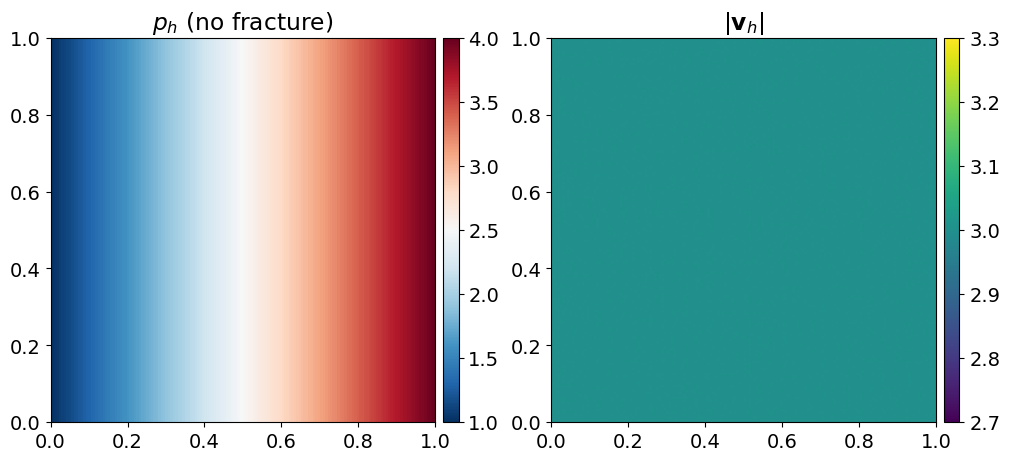

In [6]:
# ============================================================
# Pre-reconstruction visualization of the matrix-only CG solution
# ============================================================
from mpl_toolkits.axes_grid1 import make_axes_locatable
plt.rcParams.update({"font.size": 14})

_nx = _ny = 160
_xg = np.linspace(xmin, xmax, _nx)
_yg = np.linspace(ymin, ymax, _ny)
_Xg, _Yg = np.meshgrid(_xg, _yg)
_pts = np.column_stack([_Xg.ravel(), _Yg.ravel()])
_P = eval_fem_function(p_m, _pts, omega).reshape(_ny, _nx)
_Q = q_cg_numpy(_pts)
_Qmag = np.linalg.norm(_Q, axis=1).reshape(_ny, _nx)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)
_pc = axes[0].pcolormesh(_Xg, _Yg, _P, cmap="RdBu_r", shading="auto")
axes[0].set_aspect("equal")
axes[0].set_title(r"$p_h$ (no fracture)")
_div = make_axes_locatable(axes[0])
_cax = _div.append_axes("right", size="4%", pad=0.08)
fig.colorbar(_pc, cax=_cax)

_qc = axes[1].pcolormesh(_Xg, _Yg, _Qmag, cmap="viridis", shading="auto")
axes[1].set_aspect("equal")
axes[1].set_title(r"$|\mathbf{v}_h|$")
_divq = make_axes_locatable(axes[1])
_caxq = _divq.append_axes("right", size="4%", pad=0.08)
fig.colorbar(_qc, cax=_caxq)
for ax in axes:
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.grid(False)
plt.show()


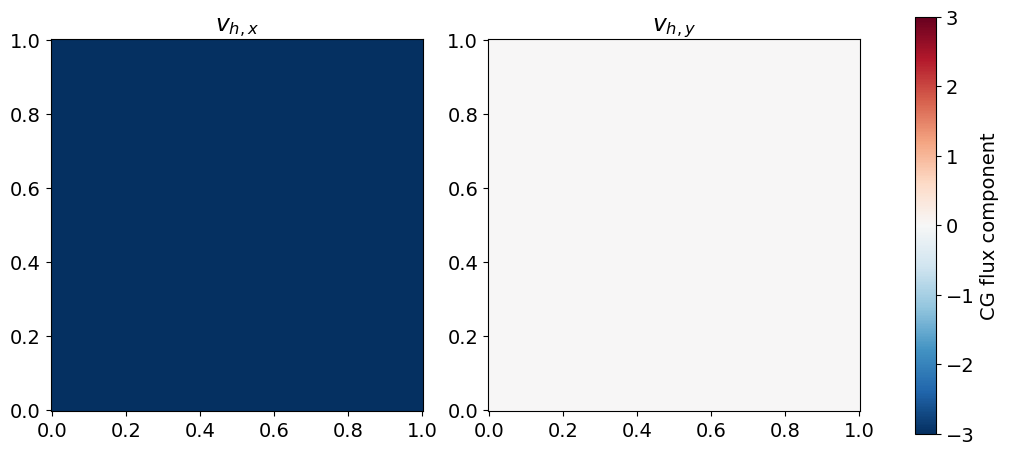

In [7]:
# Raw CG Darcy-flux components v_h = -k_m grad(p_h).
_nx_v = _ny_v = 160
_xv = np.linspace(xmin, xmax, _nx_v)
_yv = np.linspace(ymin, ymax, _ny_v)
_Xv, _Yv = np.meshgrid(_xv, _yv)
_Qv = q_cg_numpy(np.column_stack([_Xv.ravel(), _Yv.ravel()]))
v_h_x = _Qv[:, 0].reshape(_ny_v, _nx_v)
v_h_y = _Qv[:, 1].reshape(_ny_v, _nx_v)

_flux_vals = np.concatenate([v_h_x[np.isfinite(v_h_x)], v_h_y[np.isfinite(v_h_y)]])
_vlim = np.nanmax(np.abs(_flux_vals)) if _flux_vals.size else 1.0
if not np.isfinite(_vlim) or _vlim <= 0.0:
    _vlim = 1.0

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)
for ax, vals, title in [
    (axes[0], v_h_x, r"$v_{h,x}$"),
    (axes[1], v_h_y, r"$v_{h,y}$"),
]:
    _pc = ax.pcolormesh(_Xv, _Yv, vals, cmap="RdBu_r", shading="auto", vmin=-_vlim, vmax=_vlim)
    ax.set_aspect("equal")
    ax.set_title(title)
fig.colorbar(_pc, ax=axes.ravel().tolist(), label=r"CG flux component")
plt.show()


In [8]:
def cg_jump_on_fracture(s_query, eps=None):
    s_query = np.asarray(s_query, dtype=float).reshape(-1)
    return np.zeros_like(s_query, dtype=float)

TARGET_MODE = "none"
N_REAL = 2
s_real = np.linspace(0.0, L_gamma, N_REAL)
x_real = real_points_np(s_real)[:, :2]
x_ghost = np.zeros((0, 2), dtype=float)
lambda_target = np.zeros_like(s_real, dtype=float)


def tip_weight(s, tip_frac=TIP_FRAC):
    return np.ones_like(np.asarray(s, dtype=float), dtype=float)

w_tip = tip_weight(s_real)
print("No fracture: jump/lambda target and ghost-line losses are disabled by TRAINING_STAGE='matrix_only'.")


No fracture: jump/lambda target and ghost-line losses are disabled by TRAINING_STAGE='matrix_only'.


In [9]:
class AdaptiveTanh(nn.Module):
    def __init__(self, n=5.0):
        super().__init__()
        self.a = nn.Parameter(torch.tensor(1.0 / n))
    def forward(self, x):
        return torch.tanh(self.a * x)

class FluxNet(nn.Module):
    def __init__(self, in_dim=2, out_dim=2, hidden_dim=64, num_hidden_layers=4, n=5.0):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), AdaptiveTanh(n=n)]
        for _ in range(num_hidden_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), AdaptiveTanh(n=n)]
        layers.append(nn.Linear(hidden_dim, out_dim))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)
    def slope_recovery_term(self):
        slopes = [m.a for m in self.net if isinstance(m, AdaptiveTanh)]
        return 1.0 / torch.mean(torch.exp(torch.stack(slopes)))

xy_center_np = np.array([(xmin + xmax) / 2.0, (ymin + ymax) / 2.0], dtype=float)
xy_scale = float(max(xmax - xmin, ymax - ymin))
xy_center_t = torch.tensor(xy_center_np, dtype=torch.float32, device=device)
tau_t = torch.tensor(tau_np, dtype=torch.float32, device=device)
normal_t = torch.tensor(normal_np, dtype=torch.float32, device=device)
frac_a_t = torch.tensor(FRAC_A, dtype=torch.float32, device=device)

def to_torch(x, requires_grad=False):
    t = torch.as_tensor(np.asarray(x, dtype=np.float32), device=device)
    if requires_grad:
        t = t.clone().detach().requires_grad_(True)
    return t

def normalize_xy(x):
    return (x - xy_center_t) / xy_scale

q_plus_net = FluxNet(hidden_dim=32, num_hidden_layers=2).to(device)
q_minus_net = FluxNet(hidden_dim=32, num_hidden_layers=2).to(device)

def signed_distance_torch(x):
    if globals().get("NO_FRACTURE_CASE", False):
        return torch.ones(x.shape[0], dtype=x.dtype, device=x.device)
    return (x - frac_a_t) @ normal_t

def q_plus(x):
    return q_plus_net(normalize_xy(x))

def q_minus(x):
    return q_minus_net(normalize_xy(x))

def q_piecewise(x):
    phi = signed_distance_torch(x)
    qp = q_plus(x)
    qm = q_minus(x)
    return torch.where((phi >= 0.0).reshape(-1, 1), qp, qm)

def div_of_q(net_fn, x):
    x = x.clone().detach().requires_grad_(True)
    q = net_fn(x)
    dq0 = torch.autograd.grad(q[:, 0].sum(), x, create_graph=True)[0][:, 0]
    dq1 = torch.autograd.grad(q[:, 1].sum(), x, create_graph=True)[0][:, 1]
    return dq0 + dq1


In [10]:
# Optional R_xi fracture-conservation target on vertex-centered control volumes.
def normal_from_C_to_ti(centroid, midpoint, vi):
    t = midpoint - centroid
    n1 = np.array([t[1], -t[0]], dtype=float)
    n2 = -n1
    seg_mid = 0.5 * (centroid + midpoint)
    chosen = n1 if np.dot(n1, vi - seg_mid) < 0.0 else n2
    return chosen / (np.linalg.norm(chosen) + 1e-30)


def split_segment_at_partition_line(a, b, tol=1e-12):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    phi_a, phi_b = signed_distance_np(np.vstack([a, b]))
    cuts = [0.0, 1.0]
    if phi_a * phi_b < -tol ** 2:
        t = float(phi_a / (phi_a - phi_b))
        if tol < t < 1.0 - tol:
            cuts.append(t)
    cuts = np.array(sorted(cuts), dtype=float)
    return [(a + t0 * (b - a), a + t1 * (b - a)) for t0, t1 in zip(cuts[:-1], cuts[1:])]


def prepare_cv_rect_from_quad_mesh():
    vertex_key_to_id = {}
    vertices_xy = []
    cells = []

    def key_xy(xy):
        return tuple(np.round(np.asarray(xy, dtype=float), 12))

    def get_vid(xy):
        key = key_xy(xy)
        if key not in vertex_key_to_id:
            vertex_key_to_id[key] = len(vertices_xy)
            vertices_xy.append(np.asarray(xy, dtype=float))
        return vertex_key_to_id[key]

    for ci, poly in enumerate(cell_polys):
        x0, y0 = poly.min(axis=0)
        x1, y1 = poly.max(axis=0)
        xy = np.array([[x0, y0], [x1, y0], [x0, y1], [x1, y1]], dtype=float)
        cells.append({
            "xy": xy,
            "vids": np.array([get_vid(corner) for corner in xy], dtype=np.int32),
            "centroid": np.array([0.5 * (x0 + x1), 0.5 * (y0 + y1)], dtype=float),
            "cell_id": int(ci),
        })

    vertices_xy = np.asarray(vertices_xy, dtype=float)
    vtc = [[] for _ in range(len(vertices_xy))]
    for ci, cell in enumerate(cells):
        for vid in cell["vids"]:
            vtc[int(vid)].append(ci)
    return {"cells": cells, "vertices_xy": vertices_xy, "vtc": vtc, "num_vertices": len(vertices_xy)}


def integrate_lambda_interval_signed(s0, s1):
    total = 0.0
    for a, b in _split_at_lambda_nodes(s0, s1):
        mid = 0.5 * (a + b)
        half = 0.5 * (b - a)
        sq = mid + half * _GS2
        total += half * np.sum(lambda_h_on_s(sq))
    return float(total)


def build_cv_quadrature_rect(cv_rect):
    next_ccw = {0: 1, 1: 3, 3: 2, 2: 0}
    prev_ccw = {0: 2, 2: 3, 3: 1, 1: 0}
    edge_points, edge_nw, edge_vids, edge_cell_ids = [], [], [], []
    source = np.zeros(cv_rect["num_vertices"], dtype=float)
    frac_source_abs = np.zeros(cv_rect["num_vertices"], dtype=float)

    for ci, cell in enumerate(cv_rect["cells"]):
        xy = cell["xy"]
        centroid = cell["centroid"]
        cell_id = int(cell["cell_id"])
        for gi, vid in enumerate(cell["vids"]):
            vi = xy[gi]
            mid_next = 0.5 * (vi + xy[next_ccw[gi]])
            mid_prev = 0.5 * (vi + xy[prev_ccw[gi]])
            cv_poly = np.array([vi, mid_next, centroid, mid_prev], dtype=float)
            source_piece = 0.0
            for s0, s1 in fracture_intervals_in_polygon(order_polygon_vertices(cv_poly)):
                source_piece += integrate_lambda_interval_signed(s0, s1)
            source[int(vid)] += source_piece
            frac_source_abs[int(vid)] += abs(source_piece)

            for midp in [mid_next, mid_prev]:
                n_seg = normal_from_C_to_ti(centroid, midp, vi)
                for xa, xb in split_segment_at_partition_line(centroid, midp):
                    seg_len = edge_length(xa, xb)
                    if seg_len <= 1e-15:
                        continue
                    for t, w in zip(_G3, _W3):
                        x = xa + t * (xb - xa)
                        edge_points.append(x)
                        edge_nw.append(w * n_seg * seg_len)
                        edge_vids.append(int(vid))
                        edge_cell_ids.append(cell_id)

    return {
        "edge_points": np.asarray(edge_points, dtype=float),
        "edge_nw": np.asarray(edge_nw, dtype=float),
        "edge_vids": np.asarray(edge_vids, dtype=np.int64),
        "edge_cell_ids": np.asarray(edge_cell_ids, dtype=np.int32),
        "source": source,
        "frac_source_abs": frac_source_abs,
    }


def q_cg_cell_local_numpy(points, cell_ids):
    pts = np.asarray(points, dtype=float)
    cids = np.asarray(cell_ids, dtype=np.int32)
    out = np.zeros((pts.shape[0], 2), dtype=float)
    for cid in np.unique(cids):
        idx = np.nonzero(cids == cid)[0]
        bulk_cell = sol["bulk_data"]["cells"][int(cid)]
        uvals = p_m.x.array[bulk_cell["dofs"]]
        _, grads = q1_values_grads_on_cell(bulk_cell, pts[idx])
        grad = np.einsum("qad,a->qd", grads, uvals)
        out[idx] = -(K_M_VALUE) * grad
    return out


def compute_cg_cv_residual(data, num_vertices):
    q_cg = q_cg_cell_local_numpy(data["edge_points"], data["edge_cell_ids"])
    flux_cg_q = np.sum(q_cg * data["edge_nw"], axis=1)
    flux_cg = np.zeros(num_vertices, dtype=float)
    np.add.at(flux_cg, data["edge_vids"], flux_cg_q)
    return flux_cg - data["source"]


def compute_lce_for_vertices(cv_rect, data=None):
    data = build_cv_quadrature_rect(cv_rect) if data is None else data
    q_cg = q_cg_cell_local_numpy(data["edge_points"], data["edge_cell_ids"])
    q_rec = q_rec_numpy(data["edge_points"])
    flux_cg_q = np.sum(q_cg * data["edge_nw"], axis=1)
    flux_rec_q = np.sum(q_rec * data["edge_nw"], axis=1)
    flux_cg = np.zeros(cv_rect["num_vertices"], dtype=float)
    flux_rec = np.zeros(cv_rect["num_vertices"], dtype=float)
    np.add.at(flux_cg, data["edge_vids"], flux_cg_q)
    np.add.at(flux_rec, data["edge_vids"], flux_rec_q)
    return data, flux_cg - data["source"], flux_rec - data["source"]


def boundary_vertex_mask_rect(cv_rect):
    xy = cv_rect["vertices_xy"]
    tol = 1e-12
    return (
        np.isclose(xy[:, 0], 0.0, atol=tol)
        | np.isclose(xy[:, 0], 1.0, atol=tol)
        | np.isclose(xy[:, 1], 0.0, atol=tol)
        | np.isclose(xy[:, 1], 1.0, atol=tol)
    )


def restrict_cv_quadrature_to_vertices(data, num_vertices, vertex_ids):
    vertex_ids = np.asarray(vertex_ids, dtype=np.int64)
    local_of_vertex = np.full(num_vertices, -1, dtype=np.int64)
    local_of_vertex[vertex_ids] = np.arange(len(vertex_ids), dtype=np.int64)
    local_edge_vids = local_of_vertex[data["edge_vids"]]
    keep = local_edge_vids >= 0
    return {
        "edge_points": data["edge_points"][keep],
        "edge_nw": data["edge_nw"][keep],
        "edge_vids": local_edge_vids[keep],
        "edge_cell_ids": data["edge_cell_ids"][keep],
        "source": data["source"][vertex_ids],
        "vertex_ids": vertex_ids,
    }


cv_rect = prepare_cv_rect_from_quad_mesh()
cv_data = build_cv_quadrature_rect(cv_rect)
is_bnd = boundary_vertex_mask_rect(cv_rect)
interior_vertex_ids = np.where(~is_bnd)[0]
R_cv_cg_pre = compute_cg_cv_residual(cv_data, cv_rect["num_vertices"])
frac_cv_ids = np.where((cv_data["frac_source_abs"] > 1e-14) & (~is_bnd))[0]
cv_frac_quad = restrict_cv_quadrature_to_vertices(cv_data, cv_rect["num_vertices"], frac_cv_ids)
N_cv_frac_cons = len(frac_cv_ids)
cv_frac_eq_pts_t = to_torch(cv_frac_quad["edge_points"])
cv_frac_eq_nw_t = to_torch(cv_frac_quad["edge_nw"])
cv_frac_eq_vids_t = torch.tensor(cv_frac_quad["edge_vids"], dtype=torch.long, device=device)
cv_frac_source_t = to_torch(cv_frac_quad["source"])
cv_frac_cg_res_np = R_cv_cg_pre[frac_cv_ids]
cv_frac_cg_res_t = to_torch(cv_frac_cg_res_np)
cv_frac_s_np = s_coord_np(cv_rect["vertices_xy"][frac_cv_ids]) if N_cv_frac_cons else np.zeros(0, dtype=float)
cv_frac_cons_tip_np = (cv_frac_s_np < TIP_FRAC * L_gamma) | (cv_frac_s_np > (1.0 - TIP_FRAC) * L_gamma)
cv_frac_cons_int_np = ~cv_frac_cons_tip_np
cv_frac_cons_tip_t = torch.tensor(cv_frac_cons_tip_np, dtype=torch.bool, device=device)
cv_frac_cons_int_t = torch.tensor(cv_frac_cons_int_np, dtype=torch.bool, device=device)

print(f"fracture-cut CVs available for R_xi conservation loss: {N_cv_frac_cons}")


fracture-cut CVs available for R_xi conservation loss: 0


In [11]:
TRAINING_STAGE = "matrix_only"  # no-fracture control: train only matrix flux/divergence/no-flow
FRACTURE_CONS_TARGET = "R_tau"  # choose "R_tau" or "R_xi"
DATA_SAMPLE_MODE = "auto"  # "auto", "element_edge", "cv_edge", or "cell_interior"
if TRAINING_STAGE not in {"matrix_only", "full"}:
    raise ValueError("TRAINING_STAGE must be 'matrix_only' or 'full'")
if FRACTURE_CONS_TARGET not in {"R_tau", "R_xi"}:
    raise ValueError("FRACTURE_CONS_TARGET must be 'R_tau' or 'R_xi'")

N_PTS_PER_EDGE = 3
N_PTS_PER_CELL_AXIS = 2
N_DIV_PTS_PER_CV_AXIS = 2
DIV_R_XI_THRESHOLD = 1e-7
MASK_FACTOR_START = 0.15
MASK_FACTOR_END = 1.15


def build_element_edge_data_points():
    xi = np.linspace(0.0, 1.0, N_PTS_PER_EDGE + 2)[1:-1]
    pts, cell_ids = [], []
    for cell_id, poly in enumerate(cell_polys):
        for j in range(len(poly)):
            x0 = poly[j]
            x1 = poly[(j + 1) % len(poly)]
            edge = x1 - x0
            for t in xi:
                pts.append(x0 + t * edge)
                cell_ids.append(cell_id)
    return np.asarray(pts, dtype=float), np.asarray(cell_ids, dtype=np.int32)


def build_cell_interior_data_points():
    xis = np.linspace(0.0, 1.0, N_PTS_PER_CELL_AXIS + 2)[1:-1]
    pts, cell_ids = [], []
    for cell_id, cell in enumerate(sol["bulk_data"]["cells"]):
        for xi in xis:
            for eta in xis:
                pts.append([
                    cell["x0"] + xi * cell["hx"],
                    cell["y0"] + eta * cell["hy"],
                ])
                cell_ids.append(cell_id)
    return np.asarray(pts, dtype=float), np.asarray(cell_ids, dtype=np.int32)


def build_cv_edge_data_points():
    return cv_data["edge_points"].copy(), cv_data["edge_cell_ids"].copy()


def resolve_data_sample_mode(mode, fracture_cons_target):
    if mode == "auto":
        return "cv_edge" if fracture_cons_target == "R_xi" else "element_edge"
    if mode not in {"element_edge", "cv_edge", "cell_interior"}:
        raise ValueError("DATA_SAMPLE_MODE must be 'auto', 'element_edge', 'cv_edge', or 'cell_interior'")
    return mode


DATA_SKELETON = resolve_data_sample_mode(DATA_SAMPLE_MODE, FRACTURE_CONS_TARGET)
if DATA_SKELETON == "element_edge":
    data_sample_pts, data_sample_cell_ids = build_element_edge_data_points()
elif DATA_SKELETON == "cv_edge":
    data_sample_pts, data_sample_cell_ids = build_cv_edge_data_points()
elif DATA_SKELETON == "cell_interior":
    data_sample_pts, data_sample_cell_ids = build_cell_interior_data_points()

phi_all = signed_distance_np(data_sample_pts)
Q_data_all = q_cg_cell_local_numpy(data_sample_pts, data_sample_cell_ids)
valid = np.all(np.isfinite(Q_data_all), axis=1)
X_data = data_sample_pts[valid]
Q_data = Q_data_all[valid]
X_data_cell_ids = data_sample_cell_ids[valid]
phi_data = phi_all[valid]
data_mask = np.abs(phi_data) > MASK_FACTOR_START * h_est
data_mask_final = np.abs(phi_data) > MASK_FACTOR_END * h_est

X_data_t = to_torch(X_data)
Q_data_t = to_torch(Q_data)
data_idx_start_t = torch.tensor(np.nonzero(data_mask)[0], dtype=torch.long, device=device)
data_idx_final_t = torch.tensor(np.nonzero(data_mask_final)[0], dtype=torch.long, device=device)

def bilinear_quad_sample_points(quad, n_axis):
    n_axis = int(n_axis)
    if n_axis < 1:
        raise ValueError("N_DIV_PTS_PER_CV_AXIS must be at least 1")
    xis = np.linspace(0.0, 1.0, n_axis + 2)[1:-1]
    pts = []
    x00, x10, x11, x01 = [np.asarray(p, dtype=float) for p in quad]
    for r in xis:
        for s in xis:
            pts.append((1.0 - r) * (1.0 - s) * x00 + r * (1.0 - s) * x10 + r * s * x11 + (1.0 - r) * s * x01)
    return pts


def build_cv_interior_div_points(cv_rect, vertex_ids, n_axis):
    next_ccw = {0: 1, 1: 3, 3: 2, 2: 0}
    prev_ccw = {0: 2, 2: 3, 3: 1, 1: 0}
    pts = []
    for vid in np.asarray(vertex_ids, dtype=np.int64):
        for ci in cv_rect["vtc"][int(vid)]:
            cell = cv_rect["cells"][int(ci)]
            loc = np.nonzero(cell["vids"] == int(vid))[0]
            if len(loc) == 0:
                continue
            gi = int(loc[0])
            xy = cell["xy"]
            vi = xy[gi]
            mid_next = 0.5 * (vi + xy[next_ccw[gi]])
            mid_prev = 0.5 * (vi + xy[prev_ccw[gi]])
            quad = np.array([vi, mid_next, cell["centroid"], mid_prev], dtype=float)
            pts.extend(bilinear_quad_sample_points(quad, n_axis))
    if not pts:
        return np.zeros((0, 2), dtype=float)
    return np.asarray(pts, dtype=float)


if FRACTURE_CONS_TARGET == "R_xi":
    div_cv_candidate_ids = interior_vertex_ids.copy()
    div_cv_ids = div_cv_candidate_ids[np.abs(R_cv_cg_pre[div_cv_candidate_ids]) > DIV_R_XI_THRESHOLD]
    X_div = build_cv_interior_div_points(cv_rect, div_cv_ids, N_DIV_PTS_PER_CV_AXIS)
    div_collocation_label = f"R_xi-selected CV interiors: {len(div_cv_ids)} CVs, {N_DIV_PTS_PER_CV_AXIS}x{N_DIV_PTS_PER_CV_AXIS} points per CV subcell"
else:
    div_cv_ids = np.zeros(0, dtype=np.int64)
    X_div = cell_centroids.copy()
    div_collocation_label = "cell centroids"

if len(X_div) == 0:
    raise RuntimeError("No divergence collocation points were generated. Lower DIV_R_XI_THRESHOLD.")
phi_div = signed_distance_np(X_div)
div_mask = np.abs(phi_div) > MASK_FACTOR_START * h_est
div_mask_final = np.abs(phi_div) > MASK_FACTOR_END * h_est
div_idx_start_np = np.nonzero(div_mask)[0]
div_idx_final_np = np.nonzero(div_mask_final)[0]
if len(div_idx_start_np) == 0:
    raise RuntimeError("No divergence collocation points survived the start fracture-distance mask.")
if len(div_idx_final_np) == 0:
    div_idx_final_np = div_idx_start_np.copy()
X_div_t = to_torch(X_div)
F_div_t = torch.zeros(len(X_div), dtype=torch.float32, device=device)
div_idx_start_t = torch.tensor(div_idx_start_np, dtype=torch.long, device=device)
div_idx_final_t = torch.tensor(div_idx_final_np, dtype=torch.long, device=device)
side_div_t = signed_distance_torch(X_div_t) >= 0.0

X_real_t = to_torch(x_real)
Lambda_target_t = to_torch(lambda_target)
W_tip_t = to_torch(w_tip)
X_ghost_t = to_torch(x_ghost)

def build_edge_quadrature_for_cells(cell_ids):
    xi = np.array([0.5 * (1 - 1 / np.sqrt(3)), 0.5 * (1 + 1 / np.sqrt(3))], dtype=float)
    wi = np.array([0.5, 0.5], dtype=float)
    edge_points, edge_nw, edge_cells = [], [], []
    source, cg_flux, lambda_h_int = [], [], []
    local_id_of_cell = {}
    for local_i, cell_id in enumerate(cell_ids):
        local_id_of_cell[int(cell_id)] = local_i
        poly = cell_polys[int(cell_id)]
        source.append(cell_source[int(cell_id)])
        cg_flux.append(cell_flux_cg[int(cell_id)])
        lambda_h_int.append(lambda_h_cell_int[int(cell_id)])
        centroid = poly.mean(axis=0)
        for j in range(len(poly)):
            x0 = poly[j]
            x1 = poly[(j + 1) % len(poly)]
            edge = x1 - x0
            n_len = outward_edge_normal(x0, x1, centroid) * edge_length(x0, x1)
            for q, w in zip(xi, wi):
                edge_points.append(x0 + q * edge)
                edge_nw.append(w * n_len)
                edge_cells.append(local_i)
    return {
        "cell_ids": np.asarray(cell_ids, dtype=np.int32),
        "edge_points": np.asarray(edge_points, dtype=float).reshape(-1, 2),
        "edge_nw": np.asarray(edge_nw, dtype=float).reshape(-1, 2),
        "edge_cells": np.asarray(edge_cells, dtype=np.int64),
        "source": np.asarray(source),
        "cg_flux": np.asarray(cg_flux),
        "lambda_h_int": np.asarray(lambda_h_int),
        "local_id_of_cell": local_id_of_cell,
    }

_frac_cids = np.unique([cid for cid, _, _, _ in gamma_facet_records])
_frac_quad = build_edge_quadrature_for_cells(_frac_cids)
N_frac_cons = len(_frac_cids)
frac_eq_pts_t = to_torch(_frac_quad["edge_points"])
frac_eq_nw_t = to_torch(_frac_quad["edge_nw"])
frac_eq_cells_t = torch.tensor(_frac_quad["edge_cells"], dtype=torch.long, device=device)
frac_source_t = to_torch(_frac_quad["source"])
frac_lambda_t = to_torch(_frac_quad["lambda_h_int"])
frac_cg_res_np = _frac_quad["cg_flux"] - _frac_quad["source"] - _frac_quad["lambda_h_int"]
frac_cg_res_t = to_torch(frac_cg_res_np)
frac_s_np = s_coord_np(cell_centroids[_frac_cids])
frac_cons_tip_np = (frac_s_np < TIP_FRAC * L_gamma) | (frac_s_np > (1.0 - TIP_FRAC) * L_gamma)
frac_cons_int_np = ~frac_cons_tip_np
frac_cons_tip_t = torch.tensor(frac_cons_tip_np, dtype=torch.bool, device=device)
frac_cons_int_t = torch.tensor(frac_cons_int_np, dtype=torch.bool, device=device)

print(f"training stage: {TRAINING_STAGE}")
print(f"fracture conservation target: {FRACTURE_CONS_TARGET}")
print(f"flux data mode: {DATA_SAMPLE_MODE} -> {DATA_SKELETON}")
print(f"flux data pool: {len(X_data)}")
print(f"data_mask points ({MASK_FACTOR_START:.2f}h -> {MASK_FACTOR_END:.2f}h):", np.count_nonzero(data_mask), "->", np.count_nonzero(data_mask_final))
print(f"div collocation mode: {div_collocation_label}")
if FRACTURE_CONS_TARGET == "R_xi":
    print(f"div R_xi threshold: {DIV_R_XI_THRESHOLD:.1e}")
print("div collocation pool:", len(X_div))
print(f"div_mask points ({MASK_FACTOR_START:.2f}h -> {MASK_FACTOR_END:.2f}h):", len(div_idx_start_np), "->", len(div_idx_final_np))
print(f"fracture-cut cells for conservation loss: {N_frac_cons}")


IndexError: arrays used as indices must be of integer (or boolean) type

In [ ]:
MATRIX_ONLY = TRAINING_STAGE == "matrix_only"
if TRAINING_STAGE not in {"matrix_only", "full"}:
    raise ValueError("TRAINING_STAGE must be 'matrix_only' or 'full'")
if FRACTURE_CONS_TARGET not in {"R_tau", "R_xi"}:
    raise ValueError("FRACTURE_CONS_TARGET must be 'R_tau' or 'R_xi'")
print("training stage:", TRAINING_STAGE)
print("fracture conservation target:", FRACTURE_CONS_TARGET)
print("flux data skeleton:", DATA_SKELETON)

W_DATA = 10.0
W_DIV = 1.0
W_CONS_INT = 0.0 if MATRIX_ONLY else 0.10
W_CONS_TIP = 0.0 if MATRIX_ONLY else 0.10
CONS_INT_BETA = 1.0
CONS_R_FLOOR = 1e-5
CONS_INT_GAMMA = 4.0
W_JUMP = 0.0 if MATRIX_ONLY else 1.0
W_GHOST = 0.0 if MATRIX_ONLY else 2.0
W_BC_NOFLOW = 10.0
W_SLOPE = 1e-4

EPOCHS = 5000
if MATRIX_ONLY:
    CONS_RAMP_START = EPOCHS + 1
    CONS_RAMP_END = EPOCHS + 2
    BEST_START_EPOCH = int(0.8 * EPOCHS)
else:
    CONS_RAMP_START = int(1.0 * EPOCHS)
    CONS_RAMP_END = int(1.2 * EPOCHS)
    BEST_START_EPOCH = CONS_RAMP_END
BATCH_DATA = 8192
BATCH_DIV = 4096

# Homogeneous Neumann boundary penalty on the matrix no-flow sides y=0 and y=1.
# Points are face midpoints, so the penalty targets the transport CV faces where
# spurious top/bottom inflow can otherwise inject oil into the saturation solve.
N_BC_NOFLOW = int(sol["n_bulk"])
_bc_x = np.linspace(xmin, xmax, N_BC_NOFLOW, endpoint=False) + 0.5 * (xmax - xmin) / N_BC_NOFLOW
_bc_bottom = np.column_stack([_bc_x, np.full_like(_bc_x, ymin)])
_bc_top = np.column_stack([_bc_x, np.full_like(_bc_x, ymax)])
X_bc_noflow_t = to_torch(np.vstack([_bc_bottom, _bc_top]))
N_bc_noflow_t = to_torch(np.vstack([
    np.tile([0.0, -1.0], (N_BC_NOFLOW, 1)),
    np.tile([0.0,  1.0], (N_BC_NOFLOW, 1)),
]))

optimizer_plus = torch.optim.Adam(q_plus_net.parameters(), lr=2e-3)
optimizer_minus = torch.optim.Adam(q_minus_net.parameters(), lr=2e-3)
scheduler_plus = torch.optim.lr_scheduler.MultiStepLR(optimizer_plus, milestones=[int(0.45 * EPOCHS), int(0.75 * EPOCHS)], gamma=0.35)
scheduler_minus = torch.optim.lr_scheduler.MultiStepLR(optimizer_minus, milestones=[int(0.45 * EPOCHS), int(0.75 * EPOCHS)], gamma=0.35)

def mse(x):
    return torch.mean(x ** 2)

def smoothstep01(t):
    t = float(np.clip(t, 0.0, 1.0))
    return t * t * (3.0 - 2.0 * t)

def curriculum_for_epoch(epoch):
    t = (epoch - CONS_RAMP_START) / max(CONS_RAMP_END - CONS_RAMP_START, 1)
    ramp = smoothstep01(t)
    use_final_mask = epoch >= CONS_RAMP_START
    data_pool = data_idx_final_t if use_final_mask else data_idx_start_t
    div_pool = div_idx_final_t if use_final_mask else div_idx_start_t
    mask_factor = MASK_FACTOR_END if use_final_mask else MASK_FACTOR_START
    return ramp, mask_factor, data_pool, div_pool

def compute_loss_terms(epoch):
    cons_ramp, mask_factor, data_pool, div_pool = curriculum_for_epoch(epoch)
    n_data_epoch = data_pool.numel()
    idx_d = data_pool[torch.randint(0, n_data_epoch, (min(BATCH_DATA, n_data_epoch),), device=device)]
    loss_data = mse(q_piecewise(X_data_t[idx_d]) - Q_data_t[idx_d])

    n_div_epoch = div_pool.numel()
    idx_v = div_pool[torch.randint(0, n_div_epoch, (min(BATCH_DIV, n_div_epoch),), device=device)]
    x_div_b = X_div_t[idx_v]
    side_b = side_div_t[idx_v]
    div_loss = torch.tensor(0.0, device=device)
    Xp = x_div_b[side_b]
    Xm = x_div_b[~side_b]
    if Xp.numel() > 0:
        div_loss = div_loss + mse(div_of_q(q_plus, Xp))
    if Xm.numel() > 0:
        div_loss = div_loss + mse(div_of_q(q_minus, Xm))

    if FRACTURE_CONS_TARGET == "R_tau":
        q_edge = q_piecewise(frac_eq_pts_t)
        flux_q = torch.sum(q_edge * frac_eq_nw_t, dim=1)
        flux_K = torch.zeros(N_frac_cons, device=device)
        flux_K.scatter_add_(0, frac_eq_cells_t, flux_q)
        R_cons = flux_K - frac_source_t - frac_lambda_t
        R_cg_cons = frac_cg_res_t
        cons_int_t = frac_cons_int_t
        cons_tip_t = frac_cons_tip_t
    else:
        q_cv = q_piecewise(cv_frac_eq_pts_t)
        flux_q = torch.sum(q_cv * cv_frac_eq_nw_t, dim=1)
        flux_cv = torch.zeros(N_cv_frac_cons, device=device)
        if N_cv_frac_cons:
            flux_cv.scatter_add_(0, cv_frac_eq_vids_t, flux_q)
        R_cons = flux_cv - cv_frac_source_t
        R_cg_cons = cv_frac_cg_res_t
        cons_int_t = cv_frac_cons_int_t
        cons_tip_t = cv_frac_cons_tip_t

    loss_cons_frac = mse(R_cons) if R_cons.numel() > 0 else torch.tensor(0.0, device=device)

    loss_cons_int = torch.tensor(0.0, device=device)
    if cons_int_t.any().item():
        R_rec_int = R_cons[cons_int_t]
        R_cg_int = R_cg_cons[cons_int_t]
        R_cg_abs = torch.abs(R_cg_int)
        denom = torch.clamp(R_cg_abs, min=CONS_R_FLOOR)
        excess = torch.relu(torch.abs(R_rec_int) - CONS_INT_BETA * R_cg_abs)
        loss_cons_int = torch.mean((R_rec_int / denom) ** 2) + CONS_INT_GAMMA * torch.mean((excess / denom) ** 2)

    loss_cons_tip = torch.tensor(0.0, device=device)
    if cons_tip_t.any().item():
        loss_cons_tip = mse(R_cons[cons_tip_t])

    qp_real = q_plus(X_real_t)
    qm_real = q_minus(X_real_t)
    jump_real = torch.sum((qp_real - qm_real) * normal_t.reshape(1, 2), dim=1)
    loss_jump = torch.mean(W_tip_t * (jump_real - Lambda_target_t) ** 2)
    loss_ghost = mse(q_plus(X_ghost_t) - q_minus(X_ghost_t)) if X_ghost_t.numel() > 0 else torch.tensor(0.0, device=device)
    q_bc = q_piecewise(X_bc_noflow_t)
    loss_bc_noflow = mse(torch.sum(q_bc * N_bc_noflow_t, dim=1))
    loss_slope = q_plus_net.slope_recovery_term() + q_minus_net.slope_recovery_term()

    total = (
        W_DATA * loss_data
        + W_DIV * div_loss
        + cons_ramp * W_CONS_INT * loss_cons_int
        + cons_ramp * W_CONS_TIP * loss_cons_tip
        + W_JUMP * loss_jump
        + W_GHOST * loss_ghost
        + W_BC_NOFLOW * loss_bc_noflow
        + W_SLOPE * loss_slope
    )
    parts = {
        "data": loss_data.detach(),
        "div": div_loss.detach(),
        "cons_frac": loss_cons_frac.detach(),
        "cons_int": loss_cons_int.detach(),
        "cons_tip": loss_cons_tip.detach(),
        "jump": loss_jump.detach(),
        "ghost": loss_ghost.detach(),
        "bc_noflow": loss_bc_noflow.detach(),
        "slope": loss_slope.detach(),
        "cons_ramp": torch.tensor(cons_ramp, device=device),
        "mask_factor": torch.tensor(mask_factor, device=device),
    }
    return total, parts

history = []
best_state = None
best_loss = float("inf")
t0 = time.perf_counter()
for epoch in range(1, EPOCHS + 1):
    optimizer_plus.zero_grad(set_to_none=True)
    optimizer_minus.zero_grad(set_to_none=True)
    total, parts = compute_loss_terms(epoch)
    total.backward()
    torch.nn.utils.clip_grad_norm_(list(q_plus_net.parameters()) + list(q_minus_net.parameters()), max_norm=1.0)
    optimizer_plus.step()
    optimizer_minus.step()
    scheduler_plus.step()
    scheduler_minus.step()

    row = {"epoch": epoch, "total": float(total.detach().cpu())}
    row.update({k: float(v.detach().cpu()) for k, v in parts.items()})
    history.append(row)
    if epoch >= BEST_START_EPOCH and row["total"] < best_loss:
        best_loss = row["total"]
        best_state = {
            "plus": {k: v.detach().cpu().clone() for k, v in q_plus_net.state_dict().items()},
            "minus": {k: v.detach().cpu().clone() for k, v in q_minus_net.state_dict().items()},
            "epoch": epoch,
        }
    if epoch == 1 or epoch % 250 == 0:
        print(
            f"{epoch:6d} total={row['total']:.3e} ramp={row['cons_ramp']:.2f} "
            f"data={row['data']:.3e} div={row['div']:.3e} cons={row['cons_frac']:.3e} "
            f"jump={row['jump']:.3e} ghost={row['ghost']:.3e} bc0={row['bc_noflow']:.3e}"
        )

if best_state is not None:
    q_plus_net.load_state_dict(best_state["plus"])
    q_minus_net.load_state_dict(best_state["minus"])
    print("restored best epoch:", best_state["epoch"], "loss:", best_loss)
print(f"training time: {time.perf_counter() - t0:.1f} s")


In [ ]:
@torch.no_grad()
def q_rec_numpy(points, batch=200000):
    pts = np.asarray(points, dtype=float)
    out = []
    for i in range(0, len(pts), batch):
        xb = to_torch(pts[i:i + batch, :2])
        out.append(q_piecewise(xb).detach().cpu().numpy())
    return np.vstack(out) if out else np.zeros((0, 2))

@torch.no_grad()
def jump_rec_numpy(s):
    pts = real_points_np(s)[:, :2]
    xb = to_torch(pts)
    qp = q_plus(xb)
    qm = q_minus(xb)
    return torch.sum((qp - qm) * normal_t.reshape(1, 2), dim=1).detach().cpu().numpy()

# Reconstructed PINN Darcy-flux components v_theta.
_nx_theta = _ny_theta = 160
_x_theta = np.linspace(xmin, xmax, _nx_theta)
_y_theta = np.linspace(ymin, ymax, _ny_theta)
_Xtheta, _Ytheta = np.meshgrid(_x_theta, _y_theta)
_Qtheta = q_rec_numpy(np.column_stack([_Xtheta.ravel(), _Ytheta.ravel()]))
v_theta_x = _Qtheta[:, 0].reshape(_ny_theta, _nx_theta)
v_theta_y = _Qtheta[:, 1].reshape(_ny_theta, _nx_theta)

if "v_h_x" in globals() and "v_h_y" in globals():
    _theta_cg_vals = np.concatenate([v_h_x[np.isfinite(v_h_x)], v_h_y[np.isfinite(v_h_y)]])
else:
    _Qh_theta = q_cg_numpy(np.column_stack([_Xtheta.ravel(), _Ytheta.ravel()]))
    _theta_cg_vals = _Qh_theta[np.isfinite(_Qh_theta)]
_theta_vlim = np.nanmax(np.abs(_theta_cg_vals)) if _theta_cg_vals.size else 1.0
if not np.isfinite(_theta_vlim) or _theta_vlim <= 0.0:
    _theta_vlim = 1.0

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=False)
fig.subplots_adjust(left=0.07, right=0.88, bottom=0.12, top=0.86, wspace=0.18)
for ax, vals, title in [
    (axes[0], v_theta_x, r"$v_{\theta,x}$"),
    (axes[1], v_theta_y, r"$v_{\theta,y}$"),
]:
    _pc = ax.pcolormesh(_Xtheta, _Ytheta, vals, cmap="RdBu_r", shading="auto", vmin=-_theta_vlim, vmax=_theta_vlim)
    ax.set_aspect("equal")
    ax.set_title(title)
fig.colorbar(_pc, ax=axes.ravel().tolist(), label=r"PINN flux component")
plt.show()

if FRACTURE_CONS_TARGET == "R_xi":
    err_pts = cv_data["edge_points"].copy()
    err_cell_ids = cv_data["edge_cell_ids"].copy()
    err_skeleton_label = r"control-volume edges"
else:
    err_pts, err_cell_ids = build_element_edge_data_points()
    err_skeleton_label = r"element edges"

q_h_err = q_cg_cell_local_numpy(err_pts, err_cell_ids)
q_theta_err = q_rec_numpy(err_pts)
err_vec = q_theta_err - q_h_err
err_norm = np.linalg.norm(err_vec, axis=1)
valid_err = np.isfinite(err_norm)
print(f"pointwise |v_theta - v_h| on {err_skeleton_label}:", {
    "mean": float(np.mean(err_norm[valid_err])),
    "median": float(np.median(err_norm[valid_err])),
    "max": float(np.max(err_norm[valid_err])),
})
if np.any(valid_err):
    _valid_ids = np.flatnonzero(valid_err)
    _imax = int(_valid_ids[np.argmax(err_norm[valid_err])])
    _xmax = err_pts[_imax]
    print("  max |v_theta-v_h| location:", {
        "x": float(_xmax[0]),
        "y": float(_xmax[1]),
        "cell_id": int(err_cell_ids[_imax]),
        "signed_dist_to_Gamma": float(signed_distance_np(_xmax.reshape(1, 2))[0]),
        "v_h": q_h_err[_imax].tolist(),
        "v_theta": q_theta_err[_imax].tolist(),
        "delta": err_vec[_imax].tolist(),
    })

err_x = err_vec[:, 0]
err_y = err_vec[:, 1]
_err_log_x = np.log10(np.abs(err_x) + 1e-16)
_err_log_y = np.log10(np.abs(err_y) + 1e-16)
_err_comp_vals = np.concatenate([_err_log_x[valid_err], _err_log_y[valid_err]])
_err_comp_vmin, _err_comp_vmax = np.percentile(_err_comp_vals, [0.1, 99.9]) if _err_comp_vals.size else (-16.0, 0.0)
if not np.isfinite(_err_comp_vmin) or not np.isfinite(_err_comp_vmax) or _err_comp_vmin >= _err_comp_vmax:
    _err_comp_vmin = float(np.nanmin(_err_comp_vals)) if _err_comp_vals.size else -16.0
    _err_comp_vmax = float(np.nanmax(_err_comp_vals)) if _err_comp_vals.size else 0.0
    if _err_comp_vmin >= _err_comp_vmax:
        _err_comp_vmin, _err_comp_vmax = _err_comp_vmax - 1.0, _err_comp_vmax

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)
for ax, vals, title in [
    (axes[0], _err_log_x, r"$\log_{10}|v_{\theta,x}-v_{h,x}|$"),
    (axes[1], _err_log_y, r"$\log_{10}|v_{\theta,y}-v_{h,y}|$"),
]:
    _sc_comp = ax.scatter(
        err_pts[valid_err, 0], err_pts[valid_err, 1],
        c=vals[valid_err], s=1.5, cmap="RdBu_r", vmin=_err_comp_vmin, vmax=_err_comp_vmax, rasterized=True,
    )
    ax.set_aspect("equal")
    ax.set_title(title + " on " + err_skeleton_label)
fig.colorbar(_sc_comp, ax=axes.ravel().tolist(), label=r"$\log_{10}$ component absolute error")
plt.show()

_err_log = np.log10(err_norm + 1e-16)
_err_vals = _err_log[valid_err]
_err_vmin, _err_vmax = np.percentile(_err_vals, [0.1, 99.9]) if _err_vals.size else (-16.0, 0.0)
if not np.isfinite(_err_vmin) or not np.isfinite(_err_vmax) or _err_vmin >= _err_vmax:
    _err_vmin = float(np.nanmin(_err_vals)) if _err_vals.size else -16.0
    _err_vmax = float(np.nanmax(_err_vals)) if _err_vals.size else 0.0
    if _err_vmin >= _err_vmax:
        _err_vmin, _err_vmax = _err_vmax - 1.0, _err_vmax

fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
_sc = ax.scatter(
    err_pts[valid_err, 0], err_pts[valid_err, 1],
    c=_err_log[valid_err], s=1.5, cmap="magma", vmin=_err_vmin, vmax=_err_vmax, rasterized=True,
)
ax.set_aspect("equal")
ax.set_title(r"$\log_{10}\Vert v_{\theta}-v_h\Vert$ on " + err_skeleton_label)
fig.colorbar(_sc, ax=ax, label=r"$\log_{10}\Vert v_{\theta}-v_h\Vert$")
plt.show()

def compute_lce_for_cells(cell_ids):
    data = build_edge_quadrature_for_cells(cell_ids)
    q_rec = q_rec_numpy(data["edge_points"])
    flux_rec_q = np.sum(q_rec * data["edge_nw"], axis=1)
    flux_rec = np.zeros(len(data["cell_ids"]), dtype=float)
    np.add.at(flux_rec, data["edge_cells"], flux_rec_q)
    flux_cg = data["cg_flux"].copy()
    R_rec = flux_rec - data["source"] - data["lambda_h_int"]
    R_cg = flux_cg - data["source"] - data["lambda_h_int"]
    return data, R_cg, R_rec

all_cell_ids = np.arange(num_cells, dtype=np.int32)
diag_data, R_cg, R_rec = compute_lce_for_cells(all_cell_ids)
frac_cell_ids = np.unique([cid for cid, _, _, _ in gamma_facet_records]).astype(np.int32)

def residual_stats(vals, ids=None):
    vals = np.asarray(vals if ids is None else vals[ids], dtype=float)
    return {
        "mean": float(np.mean(np.abs(vals))),
        "median": float(np.median(np.abs(vals))),
        "max": float(np.max(np.abs(vals))),
    }

print("Ghost-partition PINN reconstruction:")
print("  all CG :", residual_stats(R_cg))
print("  all PINN:", residual_stats(R_rec))
print("  fracture CG :", residual_stats(R_cg, frac_cell_ids))
print("  fracture PINN:", residual_stats(R_rec, frac_cell_ids))

hist = {k: np.array([row[k] for row in history]) for k in history[0].keys()}
fig, ax = plt.subplots(figsize=(8, 4))
for key in ["total", "data", "div", "cons_frac", "jump", "ghost", "bc_noflow"]:
    if key in hist:
        ax.semilogy(hist["epoch"], hist[key], label=key)
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.legend(ncol=2, frameon=False)
ax.grid(True, which="both", alpha=0.3)
plt.show()

jump_rec = jump_rec_numpy(s_real)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(s_real, lambda_target, lw=2, label="lambda_h")
ax.plot(s_real, jump_rec, "--", lw=2, label="PINN jump")
ax.plot(s_real, cg_jump_on_fracture(s_real), ":", lw=1.5, label="CG jump")
ax.set_xlabel("arc length s")
ax.legend(frameon=False)
ax.grid(False)
plt.show()

eps = 1e-16
log_R_cg = np.log10(np.abs(R_cg) + eps)
log_R_rec = np.log10(np.abs(R_rec) + eps)
res_color_values = np.concatenate([log_R_cg[np.isfinite(log_R_cg)], log_R_rec[np.isfinite(log_R_rec)]])
res_vmin, res_vmax = np.percentile(res_color_values, [0.1, 99.9])
if not np.isfinite(res_vmin) or not np.isfinite(res_vmax) or res_vmin >= res_vmax:
    res_vmin = min(np.nanmin(log_R_cg), np.nanmin(log_R_rec))
    res_vmax = max(np.nanmax(log_R_cg), np.nanmax(log_R_rec))

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)
for ax, vals, title in [
    (axes[0], log_R_cg, "CG residual"),
    (axes[1], log_R_rec, "PINN residual"),
]:
    sc = ax.scatter(cell_centroids[:, 0], cell_centroids[:, 1], c=vals, s=8, cmap="RdBu_r", vmin=res_vmin, vmax=res_vmax)
    ax.set_aspect("equal")
    ax.set_title(title)
fig.colorbar(sc, ax=axes.ravel().tolist(), label="log10 |R_K|")
plt.show()

hist_vmin, hist_vmax = res_vmin, res_vmax
log_R_cg_hist = np.clip(log_R_cg[np.isfinite(log_R_cg)], hist_vmin, hist_vmax)
log_R_rec_hist = np.clip(log_R_rec[np.isfinite(log_R_rec)], hist_vmin, hist_vmax)
hist_bins = np.linspace(hist_vmin, hist_vmax, 40)

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.hist(log_R_cg_hist, bins=hist_bins, alpha=0.55, color="C0", label="CG before reconstruction")
ax.hist(log_R_rec_hist, bins=hist_bins, alpha=0.55, color="C1", label="PINN after reconstruction")
ax.axvline(np.median(log_R_cg_hist), color="C0", ls="--", lw=1.2)
ax.axvline(np.median(log_R_rec_hist), color="C1", ls="--", lw=1.2)
ax.set_xlabel(r"$\log_{10}|R_K|$ clipped to residual-map color range")
ax.set_ylabel("count")
ax.set_title(r"Whole-domain residual histogram")
ax.legend(frameon=False)
ax.grid(False)
plt.show()


In [ ]:
# R_xi diagnostic on vertex-centered control volumes.
cv_data, R_cv_cg, R_cv_rec = compute_lce_for_vertices(cv_rect, cv_data)
frac_cv_ids = np.where((cv_data["frac_source_abs"] > 1e-14) & (~is_bnd))[0]

print("Interior control-volume residual R_xi")
print("  CG  :", residual_stats(R_cv_cg, interior_vertex_ids))
print("  PINN:", residual_stats(R_cv_rec, interior_vertex_ids))
print("Fracture-cut interior control-volume residual R_xi")
print("  CG  :", residual_stats(R_cv_cg, frac_cv_ids))
print("  PINN:", residual_stats(R_cv_rec, frac_cv_ids))

xyv = cv_rect["vertices_xy"]
_rx = np.log10(np.abs(np.concatenate([R_cv_cg, R_cv_rec])) + eps)
_vmin, _vmax = float(_rx.min()), float(_rx.max())
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for ax, vals, title in [
    (axes[0], R_cv_cg, "CG CV residual"),
    (axes[1], R_cv_rec, "PINN CV residual"),
]:
    sc = ax.scatter(
        xyv[:, 0], xyv[:, 1],
        c=np.log10(np.abs(vals) + eps), s=10, cmap="RdBu_r", vmin=_vmin, vmax=_vmax,
    )
    ax.set_aspect("equal")
    ax.set_title(title)
fig.colorbar(sc, ax=axes.ravel().tolist(), label="log10 |R_xi|")
plt.show()

if len(frac_cv_ids):
    s_cv = ((xyv[frac_cv_ids, :2] - FRAC_A[None, :]) @ tau_np) / L_gamma
    cv_order = np.argsort(s_cv)
    s_cv = s_cv[cv_order]
    cut_Rxi_cg = np.abs(R_cv_cg[frac_cv_ids][cv_order]) + eps
    cut_Rxi_rec = np.abs(R_cv_rec[frac_cv_ids][cv_order]) + eps

    fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
    ax.plot(s_cv, cut_Rxi_cg, lw=1.2, alpha=0.7, color="C0")
    ax.plot(s_cv, cut_Rxi_rec, lw=1.2, alpha=0.7, color="C1")
    ax.scatter(s_cv, cut_Rxi_cg, s=30, alpha=0.85, color="C0", label="CG")
    ax.scatter(s_cv, cut_Rxi_rec, s=30, alpha=0.85, color="C1", label="PINN")
    ax.set_xlabel(r"$s/L_\Gamma$")
    ax.set_ylabel(r"$|R_\xi|$")
    ax.set_title(r"$|R_\xi|$ on fracture-cut interior CVs")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(1e-16, 1e-1)
    ax.set_yscale("log")
    ax.legend(frameon=False)
    ax.grid(False)
    plt.show()
else:
    print("No fracture-cut interior CVs were found.")


In [ ]:
# Shifted rectangular transport-grid CV diagnostic.
from matplotlib.collections import PolyCollection

# User inputs. Edit these values directly before running this cell.
SHIFTED_RECT_H = 2.0 * h_est
SHIFTED_RECT_HX = 1.0 * h_est
SHIFTED_RECT_HY = 1.0 * h_est
SHIFTED_RECT_SHIFT_FRACTION = np.asarray((0.31, 0.47), dtype=float)
SHIFTED_RECT_SHIFT_X = float(SHIFTED_RECT_SHIFT_FRACTION[0] * SHIFTED_RECT_HX)
SHIFTED_RECT_SHIFT_Y = float(SHIFTED_RECT_SHIFT_FRACTION[1] * SHIFTED_RECT_HY)
SHIFTED_RECT_EDGE_NQ = 4
SHIFTED_RECT_SOURCE_NQ = 3
SHIFTED_RECT_MIN_AREA = 1.0e-14
SHIFTED_RECT_CMAP = "RdBu_r"
# Default: inherit the same log-color limits as the preceding R_xi plot.
# Override with SHIFTED_RECT_LOG_CLIM=(vmin, vmax) if needed.
SHIFTED_RECT_LOG_CLIM = None


def _legendre_01(nq):
    xi, wi = np.polynomial.legendre.leggauss(max(1, int(nq)))
    return 0.5 * (xi + 1.0), 0.5 * wi


def shifted_rect_grid_lines(lo, hi, H, shift, tol=1.0e-12):
    lo = float(lo)
    hi = float(hi)
    H = float(H)
    if H <= 0.0:
        raise ValueError("The shifted-rectangle CV spacing must be positive.")
    shift = float(np.mod(shift, H))
    lines = [lo, hi]
    x = lo + shift
    if x <= lo + tol:
        x += H
    while x < hi - tol:
        lines.append(float(x))
        x += H
    return np.asarray(sorted(lines), dtype=float)


def build_shifted_rectangles():
    x_lines = shifted_rect_grid_lines(xmin, xmax, SHIFTED_RECT_HX, SHIFTED_RECT_SHIFT_X)
    y_lines = shifted_rect_grid_lines(ymin, ymax, SHIFTED_RECT_HY, SHIFTED_RECT_SHIFT_Y)
    rects, centers, areas = [], [], []
    for x0, x1 in zip(x_lines[:-1], x_lines[1:]):
        for y0, y1 in zip(y_lines[:-1], y_lines[1:]):
            area = float((x1 - x0) * (y1 - y0))
            if area <= SHIFTED_RECT_MIN_AREA:
                continue
            rects.append(np.array([[x0, y0], [x1, y0], [x1, y1], [x0, y1]], dtype=float))
            centers.append([0.5 * (x0 + x1), 0.5 * (y0 + y1)])
            areas.append(area)
    return np.asarray(rects, dtype=float), np.asarray(centers, dtype=float), np.asarray(areas, dtype=float)


def integrate_source_rectangle(poly):
    if SHIFTED_RECT_SOURCE_NQ <= 0:
        return 0.0
    xi, wi = _legendre_01(SHIFTED_RECT_SOURCE_NQ)
    x0, y0 = poly[0]
    x1, y1 = poly[2]
    pts, weights = [], []
    for i, qx in enumerate(xi):
        for j, qy in enumerate(xi):
            pts.append([x0 + qx * (x1 - x0), y0 + qy * (y1 - y0)])
            weights.append(wi[i] * wi[j] * (x1 - x0) * (y1 - y0))
    return float(np.sum(f_numpy(np.asarray(pts, dtype=float)) * np.asarray(weights, dtype=float)))


def integrate_lambda_polygon_signed(poly):
    total = 0.0
    total_abs = 0.0
    for s0, s1 in fracture_intervals_in_polygon(order_polygon_vertices(poly)):
        piece = integrate_lambda_interval_signed(s0, s1)
        total += piece
        total_abs += abs(piece)
    return float(total), float(total_abs)


def build_shifted_rect_cv_quadrature(rects):
    edge_q, edge_w = _legendre_01(SHIFTED_RECT_EDGE_NQ)
    edge_points, edge_nw, edge_rect_ids, edge_cell_ids = [], [], [], []
    source = np.zeros(len(rects), dtype=float)
    frac_source = np.zeros(len(rects), dtype=float)
    frac_source_abs = np.zeros(len(rects), dtype=float)

    for rid, poly in enumerate(rects):
        source[rid] = integrate_source_rectangle(poly)
        frac_source[rid], frac_source_abs[rid] = integrate_lambda_polygon_signed(poly)
        centroid = poly.mean(axis=0)

        for j in range(len(poly)):
            x0 = poly[j]
            x1 = poly[(j + 1) % len(poly)]
            edge = x1 - x0
            breaks = bulk_breakpoints_on_segment(x0, x1, sol["bulk_data"])
            for a, b in zip(breaks[:-1], breaks[1:]):
                if b - a <= 1.0e-14:
                    continue
                xa0 = x0 + a * edge
                xb0 = x0 + b * edge
                for xa, xb in split_segment_at_partition_line(xa0, xb0):
                    seg = xb - xa
                    seg_len = edge_length(xa, xb)
                    if seg_len <= 1.0e-15:
                        continue
                    n_len = outward_edge_normal(xa, xb, centroid) * seg_len
                    cell_id = int(locate_bulk_cell_xy(0.5 * (xa + xb), sol["bulk_data"])["cell_id"])
                    for q, w in zip(edge_q, edge_w):
                        edge_points.append(xa + q * seg)
                        edge_nw.append(w * n_len)
                        edge_rect_ids.append(int(rid))
                        edge_cell_ids.append(cell_id)

    return {
        "edge_points": np.asarray(edge_points, dtype=float),
        "edge_nw": np.asarray(edge_nw, dtype=float),
        "edge_rect_ids": np.asarray(edge_rect_ids, dtype=np.int32),
        "edge_cell_ids": np.asarray(edge_cell_ids, dtype=np.int32),
        "source": source,
        "frac_source": frac_source,
        "frac_source_abs": frac_source_abs,
    }


def compute_shifted_rect_residuals(data, n_rects):
    q_cg = q_cg_cell_local_numpy(data["edge_points"], data["edge_cell_ids"])
    q_rec = q_rec_numpy(data["edge_points"])
    flux_cg_q = np.sum(q_cg * data["edge_nw"], axis=1)
    flux_rec_q = np.sum(q_rec * data["edge_nw"], axis=1)
    flux_cg = np.zeros(n_rects, dtype=float)
    flux_rec = np.zeros(n_rects, dtype=float)
    np.add.at(flux_cg, data["edge_rect_ids"], flux_cg_q)
    np.add.at(flux_rec, data["edge_rect_ids"], flux_rec_q)
    total_source = data["source"] + data["frac_source"]
    return flux_cg - total_source, flux_rec - total_source


shifted_rect_polys, shifted_rect_centers, shifted_rect_areas = build_shifted_rectangles()
shifted_rect_data = build_shifted_rect_cv_quadrature(shifted_rect_polys)
R_shifted_rect_cg, R_shifted_rect_rec = compute_shifted_rect_residuals(shifted_rect_data, len(shifted_rect_polys))
shifted_rect_frac_ids = np.where(shifted_rect_data["frac_source_abs"] > 1.0e-14)[0]

print("Shifted rectangular transport-CV residual R_C")
print(f"  rectangles: {len(shifted_rect_polys)}")
print(f"  Hx={SHIFTED_RECT_HX:.6g}, Hy={SHIFTED_RECT_HY:.6g}, shift=({SHIFTED_RECT_SHIFT_X:.6g}, {SHIFTED_RECT_SHIFT_Y:.6g})")
print("  CG  :", residual_stats(R_shifted_rect_cg))
print("  PINN:", residual_stats(R_shifted_rect_rec))
if len(shifted_rect_frac_ids):
    print("Fracture-cut shifted rectangular transport-CV residual R_C")
    print("  CG  :", residual_stats(R_shifted_rect_cg, shifted_rect_frac_ids))
    print("  PINN:", residual_stats(R_shifted_rect_rec, shifted_rect_frac_ids))

log_shift_cg = np.log10(np.abs(R_shifted_rect_cg) + eps)
log_shift_rec = np.log10(np.abs(R_shifted_rect_rec) + eps)
if SHIFTED_RECT_LOG_CLIM is None:
    if "_vmin" in globals() and "_vmax" in globals():
        _rvmin, _rvmax = float(_vmin), float(_vmax)
    elif "R_cv_cg" in globals() and "R_cv_rec" in globals():
        _rxi_vals = np.log10(np.abs(np.concatenate([R_cv_cg, R_cv_rec])) + eps)
        _rvmin, _rvmax = float(_rxi_vals.min()), float(_rxi_vals.max())
    else:
        _vals = np.concatenate([log_shift_cg[np.isfinite(log_shift_cg)], log_shift_rec[np.isfinite(log_shift_rec)]])
        _rvmin, _rvmax = np.percentile(_vals, [0.1, 99.9])
else:
    _rvmin, _rvmax = map(float, SHIFTED_RECT_LOG_CLIM)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for ax, vals, title in [
    (axes[0], log_shift_cg, "CG shifted-rectangle CV residual"),
    (axes[1], log_shift_rec, "PINN shifted-rectangle CV residual"),
]:
    pc = PolyCollection(shifted_rect_polys, edgecolors="none", linewidths=0.0, cmap=SHIFTED_RECT_CMAP)
    pc.set_array(vals)
    pc.set_clim(_rvmin, _rvmax)
    ax.add_collection(pc)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.grid(False)
fig.colorbar(pc, ax=axes.ravel().tolist(), label="log10 |R_C|")
plt.show()

if len(shifted_rect_frac_ids):
    s_rect = ((shifted_rect_centers[shifted_rect_frac_ids, :2] - FRAC_A[None, :]) @ tau_np) / L_gamma
    rect_order = np.argsort(s_rect)
    s_rect = s_rect[rect_order]
    cut_Rc_cg = np.abs(R_shifted_rect_cg[shifted_rect_frac_ids][rect_order]) + eps
    cut_Rc_rec = np.abs(R_shifted_rect_rec[shifted_rect_frac_ids][rect_order]) + eps

    fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
    ax.plot(s_rect, cut_Rc_cg, lw=1.2, alpha=0.7, color="C0")
    ax.plot(s_rect, cut_Rc_rec, lw=1.2, alpha=0.7, color="C1")
    ax.scatter(s_rect, cut_Rc_cg, s=30, alpha=0.85, color="C0", label="CG")
    ax.scatter(s_rect, cut_Rc_rec, s=30, alpha=0.85, color="C1", label="PINN")
    ax.set_xlabel("s/L_gamma")
    ax.set_ylabel("|R_C|")
    ax.set_title("|R_C| on fracture-cut shifted rectangles")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(1e-16, 1e-1)
    ax.set_yscale("log")
    ax.legend(frameon=False)
    ax.grid(False)
    plt.show()
else:
    print("No fracture-cut shifted rectangles were found.")


In [ ]:
# Rotated rectangular transport-grid CV diagnostic.
# User inputs. Edit these values directly before running this cell.
ROT_RECT_ANGLE_DEG = 45.0
ROT_RECT_HU = 1.0 * h_est
ROT_RECT_HV = 1.0 * h_est
ROT_RECT_SHIFT_FRACTION = np.asarray((0.31, 0.47), dtype=float)
ROT_RECT_SHIFT_U = float(ROT_RECT_SHIFT_FRACTION[0] * ROT_RECT_HU)
ROT_RECT_SHIFT_V = float(ROT_RECT_SHIFT_FRACTION[1] * ROT_RECT_HV)
ROT_RECT_EDGE_NQ = 4
ROT_RECT_SOURCE_NQ = 3
ROT_RECT_MIN_AREA = 1.0e-14
ROT_RECT_CMAP = "RdBu_r"
ROT_RECT_OUTLINE_COLOR = "0.25"
ROT_RECT_OUTLINE_WIDTH = 0.15
# Fixed to match the Deng/NLR rotated R_zeta panel in the companion notebook.
ROT_RECT_LOG_CLIM = (-8.0, -2.0)
# "independent": one colorbar per panel using each method's min/max.
# "shared": one shared colorbar, using ROT_RECT_LOG_CLIM if provided.
ROT_RECT_COLORBAR_MODE = "shared"


def clip_polygon_axis_bound(poly, axis, bound, keep_less, tol=1.0e-12):
    poly = [np.asarray(p, dtype=float) for p in poly]
    if not poly:
        return []

    def inside(p):
        return p[axis] <= bound + tol if keep_less else p[axis] >= bound - tol

    out = []
    prev = poly[-1]
    prev_in = inside(prev)
    for cur in poly:
        cur_in = inside(cur)
        if cur_in != prev_in:
            denom = cur[axis] - prev[axis]
            if abs(denom) > 1.0e-15:
                t = (bound - prev[axis]) / denom
                out.append(prev + t * (cur - prev))
        if cur_in:
            out.append(cur)
        prev, prev_in = cur, cur_in
    return out


def clip_polygon_to_bbox(poly):
    out = [np.asarray(p, dtype=float) for p in poly]
    for axis, bound, keep_less in [
        (0, xmin, False),
        (0, xmax, True),
        (1, ymin, False),
        (1, ymax, True),
    ]:
        out = clip_polygon_axis_bound(out, axis, bound, keep_less)
        if len(out) == 0:
            return np.zeros((0, 2), dtype=float)
    return order_polygon_vertices(np.asarray(out, dtype=float))


def integrate_source_polygon(poly):
    if ROT_RECT_SOURCE_NQ <= 0 or len(poly) < 3:
        return 0.0
    poly = order_polygon_vertices(poly)
    p0 = poly[0]
    total = 0.0
    for i in range(1, len(poly) - 1):
        tri = np.array([p0, poly[i], poly[i + 1]], dtype=float)
        area = abs(polygon_signed_area(tri))
        if area <= 1.0e-15:
            continue
        if ROT_RECT_SOURCE_NQ == 1:
            pts = tri.mean(axis=0, keepdims=True)
            weights = np.array([area], dtype=float)
        else:
            bary = np.array([[2.0 / 3.0, 1.0 / 6.0, 1.0 / 6.0],
                             [1.0 / 6.0, 2.0 / 3.0, 1.0 / 6.0],
                             [1.0 / 6.0, 1.0 / 6.0, 2.0 / 3.0]], dtype=float)
            pts = bary @ tri
            weights = np.full(3, area / 3.0, dtype=float)
        total += float(np.sum(f_numpy(pts) * weights))
    return total


def rotated_rect_grid_lines(lo, hi, H, shift, tol=1.0e-12):
    H = float(H)
    if H <= 0.0:
        raise ValueError("The rotated-rectangle CV spacing must be positive.")
    shift = float(np.mod(shift, H))
    lines = [float(lo), float(hi)]
    x = float(lo) + shift
    if x <= lo + tol:
        x += H
    while x < hi - tol:
        lines.append(float(x))
        x += H
    return np.asarray(sorted(lines), dtype=float)


def build_rotated_rectangles():
    theta = np.deg2rad(ROT_RECT_ANGLE_DEG)
    e_u = np.array([np.cos(theta), np.sin(theta)], dtype=float)
    e_v = np.array([-np.sin(theta), np.cos(theta)], dtype=float)
    origin = np.array([xmin, ymin], dtype=float)
    bbox_poly = np.array([[xmin, ymin], [xmax, ymin], [xmax, ymax], [xmin, ymax]], dtype=float)
    bbox_uv = np.column_stack(((bbox_poly - origin) @ e_u, (bbox_poly - origin) @ e_v))
    u_lines = rotated_rect_grid_lines(bbox_uv[:, 0].min(), bbox_uv[:, 0].max(), ROT_RECT_HU, ROT_RECT_SHIFT_U)
    v_lines = rotated_rect_grid_lines(bbox_uv[:, 1].min(), bbox_uv[:, 1].max(), ROT_RECT_HV, ROT_RECT_SHIFT_V)
    polys, centers, areas = [], [], []
    for u0, u1 in zip(u_lines[:-1], u_lines[1:]):
        for v0, v1 in zip(v_lines[:-1], v_lines[1:]):
            corners_uv = np.array([[u0, v0], [u1, v0], [u1, v1], [u0, v1]], dtype=float)
            rect_xy = origin + corners_uv[:, 0:1] * e_u[None, :] + corners_uv[:, 1:2] * e_v[None, :]
            poly = clip_polygon_to_bbox(rect_xy)
            if len(poly) < 3:
                continue
            area = abs(polygon_signed_area(poly))
            if area <= ROT_RECT_MIN_AREA:
                continue
            polys.append(poly)
            centers.append(poly.mean(axis=0))
            areas.append(float(area))
    return polys, np.asarray(centers, dtype=float), np.asarray(areas, dtype=float)


def build_rotated_rect_cv_quadrature(polys):
    edge_q, edge_w = _legendre_01(ROT_RECT_EDGE_NQ)
    edge_points, edge_nw, edge_rect_ids, edge_cell_ids = [], [], [], []
    source = np.zeros(len(polys), dtype=float)
    frac_source = np.zeros(len(polys), dtype=float)
    frac_source_abs = np.zeros(len(polys), dtype=float)

    for rid, poly in enumerate(polys):
        poly = order_polygon_vertices(poly)
        source[rid] = integrate_source_polygon(poly)
        frac_source[rid], frac_source_abs[rid] = integrate_lambda_polygon_signed(poly)
        centroid = poly.mean(axis=0)

        for j in range(len(poly)):
            x0 = poly[j]
            x1 = poly[(j + 1) % len(poly)]
            edge = x1 - x0
            breaks = bulk_breakpoints_on_segment(x0, x1, sol["bulk_data"])
            for a, b in zip(breaks[:-1], breaks[1:]):
                if b - a <= 1.0e-14:
                    continue
                xa0 = x0 + a * edge
                xb0 = x0 + b * edge
                for xa, xb in split_segment_at_partition_line(xa0, xb0):
                    seg = xb - xa
                    seg_len = edge_length(xa, xb)
                    if seg_len <= 1.0e-15:
                        continue
                    n_len = outward_edge_normal(xa, xb, centroid) * seg_len
                    cell_id = int(locate_bulk_cell_xy(0.5 * (xa + xb), sol["bulk_data"])["cell_id"])
                    for q, w in zip(edge_q, edge_w):
                        edge_points.append(xa + q * seg)
                        edge_nw.append(w * n_len)
                        edge_rect_ids.append(int(rid))
                        edge_cell_ids.append(cell_id)

    return {
        "edge_points": np.asarray(edge_points, dtype=float),
        "edge_nw": np.asarray(edge_nw, dtype=float),
        "edge_rect_ids": np.asarray(edge_rect_ids, dtype=np.int32),
        "edge_cell_ids": np.asarray(edge_cell_ids, dtype=np.int32),
        "source": source,
        "frac_source": frac_source,
        "frac_source_abs": frac_source_abs,
    }


def compute_rotated_rect_residuals(data, n_rects):
    q_cg = q_cg_cell_local_numpy(data["edge_points"], data["edge_cell_ids"])
    q_rec = q_rec_numpy(data["edge_points"])
    flux_cg_q = np.sum(q_cg * data["edge_nw"], axis=1)
    flux_rec_q = np.sum(q_rec * data["edge_nw"], axis=1)
    flux_cg = np.zeros(n_rects, dtype=float)
    flux_rec = np.zeros(n_rects, dtype=float)
    np.add.at(flux_cg, data["edge_rect_ids"], flux_cg_q)
    np.add.at(flux_rec, data["edge_rect_ids"], flux_rec_q)
    total_source = data["source"] + data["frac_source"]
    return flux_cg - total_source, flux_rec - total_source


rotated_rect_polys, rotated_rect_centers, rotated_rect_areas = build_rotated_rectangles()
rotated_rect_poly_counts = np.asarray([len(poly) for poly in rotated_rect_polys], dtype=np.int32)
rotated_rect_max_vertices = int(rotated_rect_poly_counts.max()) if len(rotated_rect_poly_counts) else 0
rotated_rect_polys_padded = np.full((len(rotated_rect_polys), rotated_rect_max_vertices, 2), np.nan, dtype=float)
for _rid, _poly in enumerate(rotated_rect_polys):
    rotated_rect_polys_padded[_rid, :len(_poly), :] = _poly
rotated_rect_data = build_rotated_rect_cv_quadrature(rotated_rect_polys)
R_rotated_rect_cg, R_rotated_rect_rec = compute_rotated_rect_residuals(rotated_rect_data, len(rotated_rect_polys))
rotated_rect_frac_ids = np.where(rotated_rect_data["frac_source_abs"] > 1.0e-14)[0]

print("Rotated rectangular transport-CV residual R_zeta")
print(f"  rectangles: {len(rotated_rect_polys)}")
print(f"  angle={ROT_RECT_ANGLE_DEG:.6g} deg, Hu={ROT_RECT_HU:.6g}, Hv={ROT_RECT_HV:.6g}, shift=({ROT_RECT_SHIFT_U:.6g}, {ROT_RECT_SHIFT_V:.6g})")
print("  CG  :", residual_stats(R_rotated_rect_cg))
print("  PINN:", residual_stats(R_rotated_rect_rec))


def rotated_rect_squared_stats(vals):
    vals = np.asarray(vals, dtype=float).reshape(-1)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return "n=0"
    sum_r2 = float(np.sum(vals ** 2))
    rmse = float(np.sqrt(sum_r2 / vals.size))
    return f"n={vals.size:d} sum(R_zeta^2)={sum_r2:.6e} RMSE={rmse:.6e}"

print("Rotated rectangular transport-CV squared residual over all zeta CVs")
print("  CG  :", rotated_rect_squared_stats(R_rotated_rect_cg))
print("  PINN:", rotated_rect_squared_stats(R_rotated_rect_rec))
if len(rotated_rect_frac_ids):
    print("Fracture-cut rotated rectangular transport-CV residual R_zeta")
    print("  CG  :", residual_stats(R_rotated_rect_cg, rotated_rect_frac_ids))
    print("  PINN:", residual_stats(R_rotated_rect_rec, rotated_rect_frac_ids))

_abs_R_rot_cg = np.abs(R_rotated_rect_cg)
_abs_R_rot_rec = np.abs(R_rotated_rect_rec)
log_rot_cg = np.log10(np.maximum(_abs_R_rot_cg, eps))
log_rot_rec = np.log10(np.maximum(_abs_R_rot_rec, eps))


def _rotated_log_clim(vals, abs_vals=None):
    if abs_vals is not None:
        abs_vals = np.asarray(abs_vals, dtype=float).reshape(-1)
        positive = abs_vals[np.isfinite(abs_vals) & (abs_vals > 0.0)]
        finite = np.log10(positive) if positive.size else np.array([], dtype=float)
    else:
        finite = np.asarray(vals, dtype=float).reshape(-1)
        finite = finite[np.isfinite(finite)]
    if finite.size == 0:
        return -16.0, -1.0
    vmin = float(np.min(finite))
    vmax = float(np.max(finite))
    if not np.isfinite(vmin) or not np.isfinite(vmax):
        return -16.0, -1.0
    if vmin >= vmax:
        pad = 0.5 if abs(vmin) < 1.0e-14 else 0.05 * abs(vmin)
        vmin -= pad
        vmax += pad
    return vmin, vmax


def _format_abs_residual_tick(log_value):
    value = 10.0 ** float(log_value)
    if value == 0.0 or (1.0e-3 <= value < 1.0e3):
        return f"{value:.3g}"
    return f"{value:.1e}"


_RZETA_COLORBAR_TICKS = np.arange(-8.0, -1.0, 1.0)
_RZETA_COLORBAR_TICKLABELS = [rf"$10^{{{int(t)}}}$" for t in _RZETA_COLORBAR_TICKS]


_rot_panels = [
    (log_rot_cg, _abs_R_rot_cg, r"$R_\zeta(\mathbf{v}_h)$"),
    (log_rot_rec, _abs_R_rot_rec, r"$R_\zeta(\mathbf{v}_\theta)$"),
]
_rot_cbar_mode = str(ROT_RECT_COLORBAR_MODE).strip().lower()
if _rot_cbar_mode not in {"independent", "shared"}:
    raise ValueError('ROT_RECT_COLORBAR_MODE must be either "independent" or "shared".')

if _rot_cbar_mode == "shared":
    if ROT_RECT_LOG_CLIM is None:
        _vals = np.concatenate([vals[np.isfinite(vals)] for vals, _, _ in _rot_panels])
        _abs_vals = np.concatenate([abs_vals[np.isfinite(abs_vals)] for _, abs_vals, _ in _rot_panels])
        _rot_vmin, _rot_vmax = _rotated_log_clim(_vals, _abs_vals)
    else:
        _rot_vmin, _rot_vmax = map(float, ROT_RECT_LOG_CLIM)
    fig, axes = plt.subplots(1, 2, figsize=(6.9, 3.1), constrained_layout=False)
    fig.subplots_adjust(left=0.07, right=0.88, bottom=0.12, top=0.86, wspace=0.18)
    pc = None
    for ax, (vals, abs_vals, title) in zip(axes, _rot_panels):
        pc = PolyCollection(
            rotated_rect_polys,
            edgecolors=ROT_RECT_OUTLINE_COLOR,
            linewidths=ROT_RECT_OUTLINE_WIDTH,
            cmap=ROT_RECT_CMAP,
        )
        pc.set_array(vals)
        pc.set_clim(_rot_vmin, _rot_vmax)
        ax.add_collection(pc)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect("equal")
        ax.set_title(title, fontsize=14)
        ax.tick_params(labelsize=14)
        ax.grid(False)
    fig.canvas.draw()
    _axpos = axes[-1].get_position()
    _cax = fig.add_axes([_axpos.x1 + 0.015, _axpos.y0, 0.018, _axpos.height])
    cbar = fig.colorbar(pc, cax=_cax)
    cbar.set_label(r"$|R_\zeta|$", fontsize=14)
    cbar.set_ticks(_RZETA_COLORBAR_TICKS)
    cbar.set_ticklabels(_RZETA_COLORBAR_TICKLABELS)
    cbar.ax.tick_params(labelsize=14)
else:
    fig, axes = plt.subplots(1, 2, figsize=(7.8, 3.1), constrained_layout=True)
    for ax, (vals, abs_vals, title) in zip(axes, _rot_panels):
        _vmin, _vmax = _rotated_log_clim(vals, abs_vals)
        pc = PolyCollection(
            rotated_rect_polys,
            edgecolors=ROT_RECT_OUTLINE_COLOR,
            linewidths=ROT_RECT_OUTLINE_WIDTH,
            cmap=ROT_RECT_CMAP,
        )
        pc.set_array(vals)
        pc.set_clim(_vmin, _vmax)
        ax.add_collection(pc)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect("equal")
        ax.set_title(title, fontsize=14)
        ax.tick_params(labelsize=14)
        ax.grid(False)
        cbar = fig.colorbar(pc, ax=ax, fraction=0.046, pad=0.02)
        cbar.set_label(r"$|R_\zeta|$", fontsize=14)
        _ticks = np.linspace(_vmin, _vmax, 5)
        cbar.set_ticks(_ticks)
        cbar.set_ticklabels([_format_abs_residual_tick(t) for t in _ticks])
        cbar.ax.tick_params(labelsize=14)
plt.show()

if len(rotated_rect_frac_ids):
    s_rot = ((rotated_rect_centers[rotated_rect_frac_ids, :2] - FRAC_A[None, :]) @ tau_np) / L_gamma
    rot_order = np.argsort(s_rot)
    s_rot = s_rot[rot_order]
    cut_Rc_rot_cg = np.abs(R_rotated_rect_cg[rotated_rect_frac_ids][rot_order]) + eps
    cut_Rc_rot_rec = np.abs(R_rotated_rect_rec[rotated_rect_frac_ids][rot_order]) + eps

    fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
    ax.plot(s_rot, cut_Rc_rot_cg, lw=1.2, alpha=0.7, color="C0")
    ax.plot(s_rot, cut_Rc_rot_rec, lw=1.2, alpha=0.7, color="C1")
    ax.scatter(s_rot, cut_Rc_rot_cg, s=30, alpha=0.85, color="C0", label="CG")
    ax.scatter(s_rot, cut_Rc_rot_rec, s=30, alpha=0.85, color="C1", label="PINN")
    ax.set_xlabel("s/L_gamma")
    ax.set_ylabel(r"$|R_\zeta|$")
    ax.set_title(r"$|R_\zeta|$ on fracture-cut rotated rectangles")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(1e-16, 1e-1)
    ax.set_yscale("log")
    ax.legend(frameon=False)
    ax.grid(False)
    plt.show()
else:
    print("No fracture-cut rotated rectangles were found.")


In [ ]:
from matplotlib.collections import LineCollection

# Geometry-only visualization of the independent rotated CV grid eta over primal mesh tau.
ROT_CV_GEOM_WINDOW = (0.0, 4.0 * h_est, 0.0, 4.0 * h_est)  # xmin, xmax, ymin, ymax
ROT_CV_GEOM_FONTSIZE = 18
ROT_CV_GEOM_FIGSIZE = (4.5, 4.5)

_x0, _x1, _y0, _y1 = ROT_CV_GEOM_WINDOW

def _poly_intersects_window(poly, x0, x1, y0, y1):
    poly = np.asarray(poly, dtype=float)
    return (
        (poly[:, 0].max() >= x0) and (poly[:, 0].min() <= x1)
        and (poly[:, 1].max() >= y0) and (poly[:, 1].min() <= y1)
    )

# Primal mesh tau edges in the selected window.
_tau_segments = []
for poly in cell_polys:
    if not _poly_intersects_window(poly, _x0, _x1, _y0, _y1):
        continue
    for j in range(len(poly)):
        _tau_segments.append([poly[j], poly[(j + 1) % len(poly)]])

# Rotated CV eta polygons in the selected window.
_eta_polys = [
    poly for poly in rotated_rect_polys
    if _poly_intersects_window(poly, _x0, _x1, _y0, _y1)
]

fig, ax = plt.subplots(figsize=ROT_CV_GEOM_FIGSIZE, constrained_layout=True)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
_eta_dash_style = (0, (3.0, 2.0))

ax.add_collection(LineCollection(_tau_segments, colors="k", linewidths=0.75, zorder=2))

_eta_segments = []
_eta_seen_edges = set()
_eta_key_decimals = 12
for poly in _eta_polys:
    for j in range(len(poly)):
        p0 = np.asarray(poly[j], dtype=float)
        p1 = np.asarray(poly[(j + 1) % len(poly)], dtype=float)
        k0 = tuple(np.round(p0, _eta_key_decimals))
        k1 = tuple(np.round(p1, _eta_key_decimals))
        eta_edge_key = tuple(sorted((k0, k1)))
        if eta_edge_key in _eta_seen_edges:
            continue
        _eta_seen_edges.add(eta_edge_key)
        _eta_segments.append([p0, p1])

_eta_lines = LineCollection(
    _eta_segments,
    colors="red",
    linewidths=1.05,
    linestyles=_eta_dash_style,
    zorder=3,
)
ax.add_collection(_eta_lines)
_dx = _x1 - _x0
_dy = _y1 - _y0

# Keep the primal/window boundary visible behind dashed CV-boundary strokes.
_primal_boundary_segments = [
    [[_x0, _y0], [_x1, _y0]],
    [[_x1, _y0], [_x1, _y1]],
    [[_x1, _y1], [_x0, _y1]],
    [[_x0, _y1], [_x0, _y0]],
]
_primal_boundary = LineCollection(_primal_boundary_segments, colors="k", linewidths=0.75, zorder=2.8)
_primal_boundary.set_clip_on(False)
ax.add_collection(_primal_boundary)

# Complete the displayed boundary of retained cut CVs on the cropped top/right sides.
ax.plot([_x0, _x1], [_y1, _y1], color="red", lw=1.05, ls=_eta_dash_style, zorder=3.5, clip_on=False)
ax.plot([_x1, _x1], [_y0, _y1], color="red", lw=1.05, ls=_eta_dash_style, zorder=3.5, clip_on=False)


ax.text(
    _x0 + 0.04 * _dx, _y1 - 0.04 * _dy,
    r"$\tau\in\mathcal{T}_h$", fontsize=ROT_CV_GEOM_FONTSIZE, ha="left", va="top",
)
ax.text(
    0.45 * (_x0 + _x1), 0.55 * (_y0 + _y1),
    r"$\zeta$", fontsize=ROT_CV_GEOM_FONTSIZE, color="red", ha="center", va="center",
)

ax.set_xlim(_x0, _x1)
ax.set_ylim(_y0, _y1)
ax.set_aspect("equal")
ax.axis("off")
plt.show()

In [ ]:
# Midpoint-diamond CV diagnostic: eta is obtained by connecting edge midpoints of each primal quad tau.
MID_DIAMOND_EDGE_NQ = 4
MID_DIAMOND_SOURCE_NQ = 3
MID_DIAMOND_MIN_AREA = 1.0e-14
MID_DIAMOND_CMAP = "RdBu_r"
MID_DIAMOND_OUTLINE_COLOR = "none"
MID_DIAMOND_OUTLINE_WIDTH = 0.0
MID_DIAMOND_LOG_CLIM = None


def _mid_diamond_legendre_01(nq):
    xi, wi = np.polynomial.legendre.leggauss(max(1, int(nq)))
    return 0.5 * (xi + 1.0), 0.5 * wi


def build_midpoint_diamond_cvs():
    polys, centers, areas, cell_ids = [], [], [], []
    for cid, poly in enumerate(cell_polys):
        mids = np.array([
            0.5 * (poly[j] + poly[(j + 1) % len(poly)])
            for j in range(len(poly))
        ], dtype=float)
        eta_poly = order_polygon_vertices(mids)
        area = abs(polygon_signed_area(eta_poly))
        if area <= MID_DIAMOND_MIN_AREA:
            continue
        polys.append(eta_poly)
        centers.append(eta_poly.mean(axis=0))
        areas.append(float(area))
        cell_ids.append(int(cid))
    return (
        np.asarray(polys, dtype=float),
        np.asarray(centers, dtype=float),
        np.asarray(areas, dtype=float),
        np.asarray(cell_ids, dtype=np.int32),
    )


def integrate_source_midpoint_diamond(poly):
    if MID_DIAMOND_SOURCE_NQ <= 0 or len(poly) < 3:
        return 0.0
    poly = order_polygon_vertices(poly)
    p0 = poly[0]
    total = 0.0
    for i in range(1, len(poly) - 1):
        tri = np.array([p0, poly[i], poly[i + 1]], dtype=float)
        area = abs(polygon_signed_area(tri))
        if area <= 1.0e-15:
            continue
        if MID_DIAMOND_SOURCE_NQ == 1:
            pts = tri.mean(axis=0, keepdims=True)
            weights = np.array([area], dtype=float)
        else:
            bary = np.array([[2.0 / 3.0, 1.0 / 6.0, 1.0 / 6.0],
                             [1.0 / 6.0, 2.0 / 3.0, 1.0 / 6.0],
                             [1.0 / 6.0, 1.0 / 6.0, 2.0 / 3.0]], dtype=float)
            pts = bary @ tri
            weights = np.full(3, area / 3.0, dtype=float)
        total += float(np.sum(f_numpy(pts) * weights))
    return total


def build_midpoint_diamond_cv_quadrature(polys, cell_ids):
    edge_q, edge_w = _mid_diamond_legendre_01(MID_DIAMOND_EDGE_NQ)
    edge_points, edge_nw, edge_eta_ids, edge_cell_ids = [], [], [], []
    source = np.zeros(len(polys), dtype=float)
    frac_source = np.zeros(len(polys), dtype=float)
    frac_source_abs = np.zeros(len(polys), dtype=float)

    for eid, poly in enumerate(polys):
        poly = order_polygon_vertices(poly)
        source[eid] = integrate_source_midpoint_diamond(poly)
        frac_source[eid], frac_source_abs[eid] = integrate_lambda_polygon_signed(poly)
        centroid = poly.mean(axis=0)
        cell_id = int(cell_ids[eid])

        for j in range(len(poly)):
            x0 = poly[j]
            x1 = poly[(j + 1) % len(poly)]
            for xa, xb in split_segment_at_partition_line(x0, x1):
                seg = xb - xa
                seg_len = edge_length(xa, xb)
                if seg_len <= 1.0e-15:
                    continue
                n_len = outward_edge_normal(xa, xb, centroid) * seg_len
                for q, w in zip(edge_q, edge_w):
                    edge_points.append(xa + q * seg)
                    edge_nw.append(w * n_len)
                    edge_eta_ids.append(int(eid))
                    edge_cell_ids.append(cell_id)

    return {
        "edge_points": np.asarray(edge_points, dtype=float),
        "edge_nw": np.asarray(edge_nw, dtype=float),
        "edge_eta_ids": np.asarray(edge_eta_ids, dtype=np.int32),
        "edge_cell_ids": np.asarray(edge_cell_ids, dtype=np.int32),
        "source": source,
        "frac_source": frac_source,
        "frac_source_abs": frac_source_abs,
    }


def compute_midpoint_diamond_residuals(data, n_eta):
    q_cg = q_cg_cell_local_numpy(data["edge_points"], data["edge_cell_ids"])
    q_rec = q_rec_numpy(data["edge_points"])
    flux_cg_q = np.sum(q_cg * data["edge_nw"], axis=1)
    flux_rec_q = np.sum(q_rec * data["edge_nw"], axis=1)
    flux_cg = np.zeros(n_eta, dtype=float)
    flux_rec = np.zeros(n_eta, dtype=float)
    np.add.at(flux_cg, data["edge_eta_ids"], flux_cg_q)
    np.add.at(flux_rec, data["edge_eta_ids"], flux_rec_q)
    total_source = data["source"] + data["frac_source"]
    return flux_cg - total_source, flux_rec - total_source


mid_diamond_polys, mid_diamond_centers, mid_diamond_areas, mid_diamond_cell_ids = build_midpoint_diamond_cvs()
mid_diamond_data = build_midpoint_diamond_cv_quadrature(mid_diamond_polys, mid_diamond_cell_ids)
R_mid_diamond_cg, R_mid_diamond_rec = compute_midpoint_diamond_residuals(mid_diamond_data, len(mid_diamond_polys))
mid_diamond_frac_ids = np.where(mid_diamond_data["frac_source_abs"] > 1.0e-14)[0]

print("Midpoint-diamond CV residual R_eta")
print(f"  diamonds: {len(mid_diamond_polys)}")
print("  CG  :", residual_stats(R_mid_diamond_cg))
print("  PINN:", residual_stats(R_mid_diamond_rec))
if len(mid_diamond_frac_ids):
    print("Fracture-cut midpoint-diamond CV residual R_eta")
    print("  CG  :", residual_stats(R_mid_diamond_cg, mid_diamond_frac_ids))
    print("  PINN:", residual_stats(R_mid_diamond_rec, mid_diamond_frac_ids))

log_mid_cg = np.log10(np.abs(R_mid_diamond_cg) + eps)
log_mid_rec = np.log10(np.abs(R_mid_diamond_rec) + eps)
if MID_DIAMOND_LOG_CLIM is None:
    _vals = np.concatenate([log_mid_cg[np.isfinite(log_mid_cg)], log_mid_rec[np.isfinite(log_mid_rec)]])
    _mid_vmin = float(np.percentile(_vals, 1.0))
    _mid_vmax = float(_vals.max())
    if not np.isfinite(_mid_vmin) or not np.isfinite(_mid_vmax) or _mid_vmin >= _mid_vmax:
        _mid_vmin, _mid_vmax = -16.0, -1.0
else:
    _mid_vmin, _mid_vmax = map(float, MID_DIAMOND_LOG_CLIM)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=False)
fig.subplots_adjust(left=0.07, right=0.88, bottom=0.12, top=0.86, wspace=0.18)
for ax, vals, title in [
    (axes[0], log_mid_cg, r"$R_{\eta_m}(\mathbf{v}_h)$"),
    (axes[1], log_mid_rec, r"$R_{\eta_m}(\mathbf{v}_\theta)$"),
]:
    pc = PolyCollection(
        mid_diamond_polys,
        edgecolors=MID_DIAMOND_OUTLINE_COLOR,
        linewidths=MID_DIAMOND_OUTLINE_WIDTH,
        cmap=MID_DIAMOND_CMAP,
    )
    pc.set_array(vals)
    pc.set_clim(_mid_vmin, _mid_vmax)
    ax.add_collection(pc)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=14)
    ax.tick_params(labelsize=14)
    ax.grid(False)
fig.canvas.draw()
_axpos = axes[1].get_position()
_cax = fig.add_axes([_axpos.x1 + 0.015, _axpos.y0, 0.018, _axpos.height])
cbar = fig.colorbar(pc, cax=_cax)
cbar.set_label(r"$\log_{10}|R_{\eta_m}|$", fontsize=14)
cbar.ax.tick_params(labelsize=14)
plt.show()


In [ ]:
# Vertex-centered midpoint-diamond CV diagnostic.
# Each eta_v is centered at an interior primal vertex and connects the four neighboring edge midpoints.
VERT_DIAMOND_EDGE_NQ = MID_DIAMOND_EDGE_NQ
VERT_DIAMOND_SOURCE_NQ = MID_DIAMOND_SOURCE_NQ
VERT_DIAMOND_MIN_AREA = 1.0e-14
VERT_DIAMOND_CMAP = "RdBu_r"
VERT_DIAMOND_OUTLINE_COLOR = "none"
VERT_DIAMOND_OUTLINE_WIDTH = 0.0
VERT_DIAMOND_LOG_CLIM = None


def _is_domain_boundary_xy(xy, tol=1.0e-12):
    return (
        np.isclose(xy[0], xmin, atol=tol)
        or np.isclose(xy[0], xmax, atol=tol)
        or np.isclose(xy[1], ymin, atol=tol)
        or np.isclose(xy[1], ymax, atol=tol)
    )


def build_vertex_midpoint_diamond_cvs():
    polys, centers, areas, vertex_ids, edge_cell_ids = [], [], [], [], []
    hx = float(h_est)
    hy = float(h_est)
    offsets = np.array([[0.0, -0.5 * hy], [0.5 * hx, 0.0], [0.0, 0.5 * hy], [-0.5 * hx, 0.0]], dtype=float)

    for vid, xy in enumerate(cv_rect["vertices_xy"]):
        xy = np.asarray(xy, dtype=float)
        if _is_domain_boundary_xy(xy):
            continue
        eta_poly = order_polygon_vertices(xy[None, :] + offsets)
        if (
            eta_poly[:, 0].min() < xmin - 1.0e-12
            or eta_poly[:, 0].max() > xmax + 1.0e-12
            or eta_poly[:, 1].min() < ymin - 1.0e-12
            or eta_poly[:, 1].max() > ymax + 1.0e-12
        ):
            continue
        area = abs(polygon_signed_area(eta_poly))
        if area <= VERT_DIAMOND_MIN_AREA:
            continue

        edge_cids = []
        for j in range(len(eta_poly)):
            probe = 0.5 * (eta_poly[j] + eta_poly[(j + 1) % len(eta_poly)])
            edge_cids.append(int(locate_bulk_cell_xy(probe, sol["bulk_data"])["cell_id"]))

        polys.append(eta_poly)
        centers.append(xy)
        areas.append(float(area))
        vertex_ids.append(int(vid))
        edge_cell_ids.append(edge_cids)

    return (
        np.asarray(polys, dtype=float),
        np.asarray(centers, dtype=float),
        np.asarray(areas, dtype=float),
        np.asarray(vertex_ids, dtype=np.int32),
        np.asarray(edge_cell_ids, dtype=np.int32),
    )


def integrate_source_vertex_diamond(poly):
    if VERT_DIAMOND_SOURCE_NQ <= 0 or len(poly) < 3:
        return 0.0
    return integrate_source_midpoint_diamond(poly)


def build_vertex_diamond_cv_quadrature(polys, edge_cell_ids_by_eta):
    edge_q, edge_w = _mid_diamond_legendre_01(VERT_DIAMOND_EDGE_NQ)
    edge_points, edge_nw, edge_eta_ids, edge_cell_ids = [], [], [], []
    source = np.zeros(len(polys), dtype=float)
    frac_source = np.zeros(len(polys), dtype=float)
    frac_source_abs = np.zeros(len(polys), dtype=float)

    for eid, poly in enumerate(polys):
        poly = order_polygon_vertices(poly)
        source[eid] = integrate_source_vertex_diamond(poly)
        frac_source[eid], frac_source_abs[eid] = integrate_lambda_polygon_signed(poly)
        centroid = poly.mean(axis=0)

        for j in range(len(poly)):
            x0 = poly[j]
            x1 = poly[(j + 1) % len(poly)]
            cell_id = int(edge_cell_ids_by_eta[eid, j])
            for xa, xb in split_segment_at_partition_line(x0, x1):
                seg = xb - xa
                seg_len = edge_length(xa, xb)
                if seg_len <= 1.0e-15:
                    continue
                n_len = outward_edge_normal(xa, xb, centroid) * seg_len
                for q, w in zip(edge_q, edge_w):
                    edge_points.append(xa + q * seg)
                    edge_nw.append(w * n_len)
                    edge_eta_ids.append(int(eid))
                    edge_cell_ids.append(cell_id)

    return {
        "edge_points": np.asarray(edge_points, dtype=float),
        "edge_nw": np.asarray(edge_nw, dtype=float),
        "edge_eta_ids": np.asarray(edge_eta_ids, dtype=np.int32),
        "edge_cell_ids": np.asarray(edge_cell_ids, dtype=np.int32),
        "source": source,
        "frac_source": frac_source,
        "frac_source_abs": frac_source_abs,
    }


def compute_vertex_diamond_residuals(data, n_eta):
    q_cg = q_cg_cell_local_numpy(data["edge_points"], data["edge_cell_ids"])
    q_rec = q_rec_numpy(data["edge_points"])
    flux_cg_q = np.sum(q_cg * data["edge_nw"], axis=1)
    flux_rec_q = np.sum(q_rec * data["edge_nw"], axis=1)
    flux_cg = np.zeros(n_eta, dtype=float)
    flux_rec = np.zeros(n_eta, dtype=float)
    np.add.at(flux_cg, data["edge_eta_ids"], flux_cg_q)
    np.add.at(flux_rec, data["edge_eta_ids"], flux_rec_q)
    total_source = data["source"] + data["frac_source"]
    return flux_cg - total_source, flux_rec - total_source


vertex_diamond_polys, vertex_diamond_centers, vertex_diamond_areas, vertex_diamond_vertex_ids, vertex_diamond_edge_cell_ids = build_vertex_midpoint_diamond_cvs()
vertex_diamond_data = build_vertex_diamond_cv_quadrature(vertex_diamond_polys, vertex_diamond_edge_cell_ids)
R_vertex_diamond_cg, R_vertex_diamond_rec = compute_vertex_diamond_residuals(vertex_diamond_data, len(vertex_diamond_polys))
vertex_diamond_frac_ids = np.where(vertex_diamond_data["frac_source_abs"] > 1.0e-14)[0]

print("Vertex-centered midpoint-diamond CV residual R_eta")
print(f"  diamonds: {len(vertex_diamond_polys)}")
print("  CG  :", residual_stats(R_vertex_diamond_cg))
print("  PINN:", residual_stats(R_vertex_diamond_rec))
if len(vertex_diamond_frac_ids):
    print("Fracture-cut vertex-centered midpoint-diamond CV residual R_eta")
    print("  CG  :", residual_stats(R_vertex_diamond_cg, vertex_diamond_frac_ids))
    print("  PINN:", residual_stats(R_vertex_diamond_rec, vertex_diamond_frac_ids))

log_vertex_cg = np.log10(np.abs(R_vertex_diamond_cg) + eps)
log_vertex_rec = np.log10(np.abs(R_vertex_diamond_rec) + eps)
if VERT_DIAMOND_LOG_CLIM is None:
    _vals = np.concatenate([log_vertex_cg[np.isfinite(log_vertex_cg)], log_vertex_rec[np.isfinite(log_vertex_rec)]])
    _vertex_vmin = float(np.percentile(_vals, 1.0))
    _vertex_vmax = float(_vals.max())
    if not np.isfinite(_vertex_vmin) or not np.isfinite(_vertex_vmax) or _vertex_vmin >= _vertex_vmax:
        _vertex_vmin, _vertex_vmax = -16.0, -1.0
else:
    _vertex_vmin, _vertex_vmax = map(float, VERT_DIAMOND_LOG_CLIM)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=False)
fig.subplots_adjust(left=0.07, right=0.88, bottom=0.12, top=0.86, wspace=0.18)
for ax, vals, title in [
    (axes[0], log_vertex_cg, r"$R_{\eta_v}(\mathbf{v}_h)$"),
    (axes[1], log_vertex_rec, r"$R_{\eta_v}(\mathbf{v}_\theta)$"),
]:
    pc = PolyCollection(
        vertex_diamond_polys,
        edgecolors=VERT_DIAMOND_OUTLINE_COLOR,
        linewidths=VERT_DIAMOND_OUTLINE_WIDTH,
        cmap=VERT_DIAMOND_CMAP,
    )
    pc.set_array(vals)
    pc.set_clim(_vertex_vmin, _vertex_vmax)
    ax.add_collection(pc)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=14)
    ax.tick_params(labelsize=14)
    ax.grid(False)
fig.canvas.draw()
_axpos = axes[1].get_position()
_cax = fig.add_axes([_axpos.x1 + 0.015, _axpos.y0, 0.018, _axpos.height])
cbar = fig.colorbar(pc, cax=_cax)
cbar.set_label(r"$\log_{10}|R_{\eta_v}|$", fontsize=14)
cbar.ax.tick_params(labelsize=14)
plt.show()


In [ ]:
# R_K scatter diagnostic restricted to bulk cells cut by the fracture.
# No fracture in this control notebook, so there are no cut cells to plot.
cut_plot_cell_ids = np.zeros(0, dtype=np.int32)
print("No fracture: skipped fracture-cut bulk-cell R_K scatter diagnostic.")


In [ ]:
# MRST TPFA validation for the no-fracture control.
from scipy.io import loadmat
from mpl_toolkits.axes_grid1 import make_axes_locatable

MRST_CASE3_PATH = pathlib.Path("case3_ecmor/case3_mrst_export_nofrac.mat")
if not MRST_CASE3_PATH.exists():
    _mrst_alt = pathlib.Path("fenicsx/code/fracture problem/case3_ecmor/case3_mrst_export_nofrac.mat")
    if _mrst_alt.exists():
        MRST_CASE3_PATH = _mrst_alt
if not MRST_CASE3_PATH.exists():
    raise FileNotFoundError("Could not find case3_mrst_export_nofrac.mat.")

mrst = loadmat(MRST_CASE3_PATH, squeeze_me=True, struct_as_record=False)
mrst_case3_available = True


def _mrst_arr(key, dtype=float, reshape=None, default=None):
    if key not in mrst:
        if default is None:
            raise KeyError(f"MRST no-fracture export is missing {key!r}")
        return np.asarray(default, dtype=dtype)
    arr = np.asarray(mrst[key], dtype=dtype)
    if reshape == -1:
        arr = arr.reshape(-1)
    return arr


def _mrst_scalar(key, default=np.nan):
    if key not in mrst:
        return float(default)
    arr = np.asarray(mrst[key]).reshape(-1)
    return float(arr[0]) if arr.size else float(default)

mrst_xc_matrix = _mrst_arr("xc_matrix", float)
mrst_p_matrix = _mrst_arr("p_matrix", float, -1)
mrst_face_flux = _mrst_arr("face_flux", float, -1)
mrst_face_neighbors = _mrst_arr("face_neighbors", np.int64)
mrst_face_centroid = _mrst_arr("face_centroid", float)
mrst_face_p1 = _mrst_arr("face_p1", float)
mrst_face_p2 = _mrst_arr("face_p2", float)
mrst_face_normal = _mrst_arr("face_normal", float)
mrst_face_len = _mrst_arr("face_len", float, -1)
mrst_face_is_boundary = _mrst_arr("face_is_boundary", bool, -1, default=np.zeros(len(mrst_face_flux), dtype=bool))
mrst_face_frac_cut = np.zeros(len(mrst_face_flux), dtype=bool)
mrst_s_frac = np.array([], dtype=float)
mrst_p_frac = np.array([], dtype=float)
mrst_lam_s = np.array([], dtype=float)
mrst_lam_density = np.array([], dtype=float)
mrst_lam_seglen = np.array([], dtype=float)


def validation_stats(diff, ref=None, mask=None):
    vals = np.asarray(diff, dtype=float).reshape(-1)
    if mask is not None:
        vals = vals[np.asarray(mask, dtype=bool).reshape(-1)]
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return {"mean_abs": np.nan, "median_abs": np.nan, "rmse": np.nan, "max_abs": np.nan, "rel_l2": np.nan}
    out = {
        "mean_abs": float(np.mean(np.abs(vals))),
        "median_abs": float(np.median(np.abs(vals))),
        "rmse": float(np.sqrt(np.mean(vals ** 2))),
        "max_abs": float(np.max(np.abs(vals))),
        "rel_l2": np.nan,
    }
    if ref is not None:
        r = np.asarray(ref, dtype=float).reshape(-1)
        if mask is not None:
            r = r[np.asarray(mask, dtype=bool).reshape(-1)]
        r = r[np.isfinite(r)]
        denom = float(np.sqrt(np.sum(r ** 2))) if r.size else 0.0
        if denom > 0.0:
            out["rel_l2"] = float(np.sqrt(np.sum(vals ** 2)) / denom)
    return out


def print_validation_stats(label, diff, ref=None, mask=None):
    st = validation_stats(diff, ref=ref, mask=mask)
    print(
        f"  {label:<28} mean|e|={st['mean_abs']:.3e} median|e|={st['median_abs']:.3e} "
        f"rmse={st['rmse']:.3e} max|e|={st['max_abs']:.3e} relL2={st['rel_l2']:.3e}"
    )
    return st

p_matrix_lcg_on_mrst = eval_fem_function(p_m, mrst_xc_matrix, omega).reshape(-1)
p_matrix_diff_lcg_mrst = p_matrix_lcg_on_mrst - mrst_p_matrix
print(f"MRST no-fracture validation file: {MRST_CASE3_PATH}")
print("Matrix pressure comparison: notebook p_h minus MRST p_matrix")
pressure_stats = print_validation_stats("matrix pressure", p_matrix_diff_lcg_mrst, mrst_p_matrix)


def integrate_pinn_flux_on_mrst_faces(batch_faces=50000):
    out = np.empty(len(mrst_face_flux), dtype=float)
    for i0 in range(0, len(out), batch_faces):
        i1 = min(i0 + batch_faces, len(out))
        p1 = mrst_face_p1[i0:i1]
        p2 = mrst_face_p2[i0:i1]
        mid = 0.5 * (p1 + p2)
        half = 0.5 * (p2 - p1)
        xq = mid[:, None, :] + _G3_SYM[None, :, None] * half[:, None, :]
        q = q_rec_numpy(xq.reshape(-1, 2)).reshape(i1 - i0, len(_G3_SYM), 2)
        qn = np.einsum("fqd,fd->fq", q, mrst_face_normal[i0:i1])
        out[i0:i1] = 0.5 * mrst_face_len[i0:i1] * np.sum(_W3_SYM[None, :] * qn, axis=1)
    return out


def integrate_cg_owner_flux_on_mrst_faces(batch_faces=50000):
    out = np.empty(len(mrst_face_flux), dtype=float)
    owner_mrst = np.where(mrst_face_neighbors[:, 0] > 0, mrst_face_neighbors[:, 0], mrst_face_neighbors[:, 1])
    if np.any(owner_mrst <= 0):
        raise ValueError("Encountered an MRST face with no matrix owner cell.")
    owner_centers = mrst_xc_matrix[owner_mrst.astype(np.int64) - 1]
    owner_cell_ids = np.array([
        int(locate_bulk_cell_xy(xy, sol["bulk_data"])["cell_id"])
        for xy in owner_centers
    ], dtype=np.int32)
    for i0 in range(0, len(out), batch_faces):
        i1 = min(i0 + batch_faces, len(out))
        p1 = mrst_face_p1[i0:i1]
        p2 = mrst_face_p2[i0:i1]
        mid = 0.5 * (p1 + p2)
        half = 0.5 * (p2 - p1)
        xq = mid[:, None, :] + _G3_SYM[None, :, None] * half[:, None, :]
        q = q_cg_cell_local_numpy(
            xq.reshape(-1, 2),
            np.repeat(owner_cell_ids[i0:i1], len(_G3_SYM)),
        ).reshape(i1 - i0, len(_G3_SYM), 2)
        qn = np.einsum("fqd,fd->fq", q, mrst_face_normal[i0:i1])
        out[i0:i1] = 0.5 * mrst_face_len[i0:i1] * np.sum(_W3_SYM[None, :] * qn, axis=1)
    return out

mrst_flux_pinn = integrate_pinn_flux_on_mrst_faces()
mrst_flux_cg_owner = integrate_cg_owner_flux_on_mrst_faces()
mrst_flux_pinn_diff = mrst_flux_pinn - mrst_face_flux
mrst_flux_cg_owner_diff = mrst_flux_cg_owner - mrst_face_flux

print("Matrix face-flux comparison: notebook integral minus MRST face_flux")
flux_pinn_all_stats = print_validation_stats("PINN face flux, all", mrst_flux_pinn_diff, mrst_face_flux)
flux_cg_all_stats = print_validation_stats("CG-owner face flux, all", mrst_flux_cg_owner_diff, mrst_face_flux)


def print_max_mrst_face_flux_difference(label, approx_flux, diff):
    vals = np.asarray(diff, dtype=float)
    valid = np.isfinite(vals)
    if not np.any(valid):
        print(f"  {label}: no finite face-flux differences")
        return None
    ids = np.flatnonzero(valid)
    imax = int(ids[np.argmax(np.abs(vals[valid]))])
    row = {
        "face_id": imax,
        "centroid": mrst_face_centroid[imax].tolist(),
        "p1": mrst_face_p1[imax].tolist(),
        "p2": mrst_face_p2[imax].tolist(),
        "normal": mrst_face_normal[imax].tolist(),
        "length": float(mrst_face_len[imax]),
        "neighbors": mrst_face_neighbors[imax].astype(int).tolist(),
        "is_boundary": bool(mrst_face_is_boundary[imax]),
        "approx_flux": float(approx_flux[imax]),
        "mrst_flux": float(mrst_face_flux[imax]),
        "diff": float(vals[imax]),
        "abs_diff": float(abs(vals[imax])),
    }
    print(f"  max |{label} - MRST face_flux|:", row)
    return row

max_pinn_mrst_face_flux_diff = print_max_mrst_face_flux_difference("PINN", mrst_flux_pinn, mrst_flux_pinn_diff)
max_cg_mrst_face_flux_diff = print_max_mrst_face_flux_difference("CG-owner", mrst_flux_cg_owner, mrst_flux_cg_owner_diff)


def print_matrix_noflow_boundary_audit():
    tol = 1.0e-12
    masks = {
        "bottom": mrst_face_is_boundary & (np.abs(mrst_face_centroid[:, 1] - ymin) < tol),
        "top": mrst_face_is_boundary & (np.abs(mrst_face_centroid[:, 1] - ymax) < tol),
    }
    fields = {"CG-owner": mrst_flux_cg_owner, "PINN": mrst_flux_pinn, "MRST": mrst_face_flux}
    print("Matrix no-flow boundary audit on y=0 and y=1 faces:")
    for side, mask in masks.items():
        row = []
        for name, vals in fields.items():
            f = np.asarray(vals, dtype=float)[mask]
            row.append(f"{name}: sum={np.sum(f):+.3e}, sum|F|={np.sum(np.abs(f)):.3e}, max|F|={np.max(np.abs(f)):.3e}")
        print(f"  {side:<6} " + "; ".join(row))

print_matrix_noflow_boundary_audit()
mrst_lambda_sign_to_mrst = np.nan
mrst_lambda_lcg_raw = np.array([], dtype=float)
mrst_lambda_lcg_to_mrst = np.array([], dtype=float)
mrst_lambda_diff_lcg_mrst = np.array([], dtype=float)

with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    fig, axes = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)
    _pdiff_lim = float(np.nanpercentile(np.abs(p_matrix_diff_lcg_mrst), 99.0))
    if not np.isfinite(_pdiff_lim) or _pdiff_lim <= 0.0:
        _pdiff_lim = float(np.nanmax(np.abs(p_matrix_diff_lcg_mrst))) if np.isfinite(p_matrix_diff_lcg_mrst).any() else 1.0
    if not np.isfinite(_pdiff_lim) or _pdiff_lim <= 0.0:
        _pdiff_lim = 1.0e-15
    _sc_p = axes[0].scatter(
        mrst_xc_matrix[:, 0], mrst_xc_matrix[:, 1],
        c=p_matrix_diff_lcg_mrst, s=3, cmap="RdBu_r", vmin=-_pdiff_lim, vmax=_pdiff_lim, rasterized=True,
    )
    axes[0].set_xlim(xmin, xmax); axes[0].set_ylim(ymin, ymax); axes[0].set_aspect("equal")
    axes[0].set_title(r"i) $\Delta p=p_h-p_{\mathrm{FV}}$")
    axes[0].set_xlabel(""); axes[0].set_ylabel(""); axes[0].grid(False)
    _div_p = make_axes_locatable(axes[0]); _cax_p = _div_p.append_axes("right", size="4%", pad=0.06)
    cbar_p = fig.colorbar(_sc_p, cax=_cax_p)
    _p_ticks = np.linspace(-_pdiff_lim, _pdiff_lim, 5)
    cbar_p.set_ticks(_p_ticks); cbar_p.set_ticklabels([f"{t:.3f}" for t in _p_ticks])

    _flux_diff = mrst_flux_pinn_diff
    _flux_diff_lim = float(np.nanpercentile(np.abs(_flux_diff[np.isfinite(_flux_diff)]), 99.5)) if np.isfinite(_flux_diff).any() else 1.0
    if not np.isfinite(_flux_diff_lim) or _flux_diff_lim <= 0.0:
        _flux_diff_lim = float(np.nanmax(np.abs(_flux_diff))) if np.isfinite(_flux_diff).any() else 1.0e-15
    if not np.isfinite(_flux_diff_lim) or _flux_diff_lim <= 0.0:
        _flux_diff_lim = 1.0e-15
    _sc_f = axes[1].scatter(
        mrst_face_centroid[:, 0], mrst_face_centroid[:, 1],
        c=_flux_diff, s=2.5, cmap="RdBu_r", vmin=-_flux_diff_lim, vmax=_flux_diff_lim, rasterized=True,
    )
    axes[1].set_xlim(xmin, xmax); axes[1].set_ylim(ymin, ymax); axes[1].set_aspect("equal")
    axes[1].set_title(r"ii) $\int_e(\mathbf{v}_\theta-\mathbf{v}_{\mathrm{FV}})\!\cdot\!\mathbf{n}$")
    axes[1].set_xlabel(""); axes[1].tick_params(labelleft=False); axes[1].grid(False)
    _div_f = make_axes_locatable(axes[1]); _cax_f = _div_f.append_axes("right", size="4%", pad=0.06)
    cbar_f = fig.colorbar(_sc_f, cax=_cax_f)
    _f_ticks = np.linspace(-_flux_diff_lim, _flux_diff_lim, 5)
    cbar_f.set_ticks(_f_ticks); cbar_f.set_ticklabels([f"{t:.3f}" for t in _f_ticks])
    plt.show()


In [ ]:
# Right-boundary flux as an explicit boundary integral (Option 1) -- run before the
# saturation solve. The pointwise flux-difference map (panel ii) looks ~white on the
# right boundary, yet the integrated right_inflow differs by a few percent. This shows
# why: small, mostly same-sign per-face differences -- invisible on the +-0.008 map --
# add up over the ~n_bulk boundary faces. Computed on the MRST right-boundary faces,
# where mrst_flux_pinn / mrst_flux_cg_owner / mrst_face_flux share one orientation.
_rb_tol = 0.25 * h_est
_rb_mask = mrst_face_is_boundary & (np.abs(mrst_face_centroid[:, 0] - xmax) <= _rb_tol)
_nrb = int(np.sum(_rb_mask))
if _nrb == 0:
    raise RuntimeError("No MRST right-boundary faces found; check xmax / centroid orientation.")

def _rb_sum(arr):
    return float(np.sum(np.asarray(arr, dtype=float)[_rb_mask]))

_phi_mrst = _rb_sum(mrst_face_flux)
_phi_pinn = _rb_sum(mrst_flux_pinn)
_phi_cg = _rb_sum(mrst_flux_cg_owner)
_d_pinn = _rb_sum(mrst_flux_pinn - mrst_face_flux)
_d_cg = _rb_sum(mrst_flux_cg_owner - mrst_face_flux)
_max_pinn = float(np.max(np.abs((mrst_flux_pinn - mrst_face_flux)[_rb_mask])))
_max_cg = float(np.max(np.abs((mrst_flux_cg_owner - mrst_face_flux)[_rb_mask])))

print("Right-boundary flux as a boundary integral (explains the right_inflow gap)")
print(f"  right-boundary faces : {_nrb}")
print(f"  total normal flux    : MRST={_phi_mrst:+.4e}  PINN={_phi_pinn:+.4e}  CG={_phi_cg:+.4e}")
print(
    f"  Sum(PINN - MRST)     : {_d_pinn:+.4e}  ({100.0 * _d_pinn / abs(_phi_mrst):+.2f}% of MRST)"
    f"  mean/face={_d_pinn / _nrb:+.3e}  max|per-face|={_max_pinn:.3e}"
)
print(
    f"  Sum(CG   - MRST)     : {_d_cg:+.4e}  ({100.0 * _d_cg / abs(_phi_mrst):+.2f}% of MRST)"
    f"  mean/face={_d_cg / _nrb:+.3e}  max|per-face|={_max_cg:.3e}"
)
print("  -> max per-face difference is tiny vs the summed (coherent) difference: a small")
print("     same-sign bias invisible on the map integrates into the right_inflow gap.")

# Per-face detail: where along the right boundary is the discrepancy concentrated?
_yb = mrst_face_centroid[_rb_mask, 1]
_dp = (mrst_flux_pinn - mrst_face_flux)[_rb_mask]
_dc = (mrst_flux_cg_owner - mrst_face_flux)[_rb_mask]
_order = np.argsort(_yb)
_yb, _dp, _dc = _yb[_order], _dp[_order], _dc[_order]

_bands = [
    ("y in [0.0,0.1] (near y=0)", (_yb >= 0.0) & (_yb <= 0.1)),
    ("y in [0.1,0.9] (bulk)    ", (_yb > 0.1) & (_yb < 0.9)),
    ("y in [0.9,1.0] (near y=1)", (_yb >= 0.9) & (_yb <= 1.0)),
]
print("Right-boundary discrepancy by y-band (signed Sum and max|per-face|):")
for _label, _m in _bands:
    _n = int(np.sum(_m))
    if _n == 0:
        print(f"  {_label}: (no faces)")
        continue
    print(
        f"  {_label}: nfaces={_n:3d}"
        f"  PINN Sum={np.sum(_dp[_m]):+.3e} max|f|={np.max(np.abs(_dp[_m])):.2e}"
        f"  CG Sum={np.sum(_dc[_m]):+.3e} max|f|={np.max(np.abs(_dc[_m])):.2e}"
    )

def _topk(diff, k=5):
    idx = np.argsort(np.abs(diff))[::-1][:k]
    return [(float(_yb[i]), float(diff[i])) for i in idx]

print("Top-5 right-boundary faces by |PINN - MRST|:")
for _y, _v in _topk(_dp):
    print(f"    y={_y:.3f}  diff={_v:+.3e}")
print("Top-5 right-boundary faces by |CG - MRST|:")
for _y, _v in _topk(_dc):
    print(f"    y={_y:.3f}  diff={_v:+.3e}")


In [ ]:
# No-fracture Buckley-Leverett transport helpers shared by zeta/rectangular cells.
def _mrst_scalar(key, default=np.nan):
    if "mrst" not in globals() or key not in mrst:
        return float(default)
    arr = np.asarray(mrst[key]).reshape(-1)
    return float(arr[0]) if arr.size else float(default)

TRANSPORT_NOFRACTURE_CASE = "PVI0.5" if "mrst" in globals() and "sw_matrix_pvi05" in mrst else "T1"
if TRANSPORT_NOFRACTURE_CASE == "PVI0.5":
    TRANSPORT_MRST_T_FINAL = _mrst_scalar("meta_T_pvi05", _mrst_scalar("meta_T1", np.nan))
    _q_water = _mrst_scalar("meta_Q_water", np.nan)
    _pv_matrix = _mrst_scalar("meta_PV_matrix", 1.0)
    TRANSPORT_PVI_TARGET = float(_q_water * TRANSPORT_MRST_T_FINAL / _pv_matrix) if np.isfinite(_q_water) else 0.5
elif TRANSPORT_NOFRACTURE_CASE == "T1":
    TRANSPORT_MRST_T_FINAL = _mrst_scalar("meta_T1", np.nan)
    TRANSPORT_PVI_TARGET = _mrst_scalar("meta_PVI1", 1.0)
else:
    TRANSPORT_MRST_T_FINAL = np.nan
    TRANSPORT_PVI_TARGET = 1.0
TRANSPORT_USE_MRST_T_FINAL = np.isfinite(TRANSPORT_MRST_T_FINAL)
TRANSPORT_T_SOURCE = f"MRST no-fracture {TRANSPORT_NOFRACTURE_CASE}" if TRANSPORT_USE_MRST_T_FINAL else "PVI target / reference inflow"
TRANSPORT_CFL = _mrst_scalar("meta_CFL", 0.45)
TRANSPORT_FPRIME_MAX = _mrst_scalar("meta_FPRIME_MAX", 2.0)
TRANSPORT_RIGHT_BC_S = 1.0
TRANSPORT_RIGHT_BC_NFACES = int(sol["n_bulk"])  # full right boundary, matching the no-fracture MRST export
TRANSPORT_RIGHT_NFACES = TRANSPORT_RIGHT_BC_NFACES
TRANSPORT_DEFAULT_INFLOW_S = 0.0
TRANSPORT_CLIP = True
TRANSPORT_T_REFERENCE = "MRST"
TRANSPORT_MAX_STEPS = 200_000
TRANSPORT_EXCHANGE_TOL = 1.0e-14

FACE_INTERIOR = -1
FACE_LEFT = 0
FACE_RIGHT = 1
FACE_BOTTOM = 2
FACE_TOP = 3

from matplotlib.collections import PolyCollection


def fractional_flow_bl(S):
    S = np.clip(np.asarray(S, dtype=float), 0.0, 1.0)
    return S ** 2 / (S ** 2 + (1.0 - S) ** 2 + 1.0e-30)


def boundary_side_from_midpoint(xy, tol=None):
    if tol is None:
        tol = 0.25 * h_est
    x, y = np.asarray(xy, dtype=float)[:2]
    if np.isclose(x, xmin, atol=tol):
        return FACE_LEFT
    if np.isclose(x, xmax, atol=tol):
        return FACE_RIGHT
    if np.isclose(y, ymin, atol=tol):
        return FACE_BOTTOM
    if np.isclose(y, ymax, atol=tol):
        return FACE_TOP
    return FACE_INTERIOR

print(
    f"No-fracture transport setup: case={TRANSPORT_NOFRACTURE_CASE}, "
    f"T={TRANSPORT_MRST_T_FINAL:.8e}, PVI={TRANSPORT_PVI_TARGET:.6f}, "
    f"CFL={TRANSPORT_CFL:.3f}, right faces with S=1={TRANSPORT_RIGHT_BC_NFACES}"
)


In [ ]:
# Matrix-only Buckley-Leverett transport on standard rectangular control volumes.
TRANSPORT_RECT_T_REFERENCE = TRANSPORT_T_REFERENCE
TRANSPORT_RIGHT_NFACES = int(TRANSPORT_RIGHT_BC_NFACES)
transport_rect_grid_kind = "standard_rectangular_no_fracture"
num_rect_cells = int(num_cells)
rect_cell_areas = np.asarray(cell_areas, dtype=float)


def rect_cell_ij_from_cell(cell):
    ix = int(round(cell["x0"] / h_est))
    iy = int(round(cell["y0"] / h_est))
    return ix, iy


def rect_cell_id_from_ij(ix, iy):
    n = sol["n_bulk"]
    if ix < 0 or ix >= n or iy < 0 or iy >= n:
        return -1
    return int(sol["bulk_data"]["lookup"][(int(ix), int(iy))])


def build_rect_oriented_face_geometry():
    owners, neighbors, sides = [], [], []
    p0s, p1s, normals, lengths = [], [], [], []
    for cell in sol["bulk_data"]["cells"]:
        cid = int(cell["cell_id"])
        ix, iy = rect_cell_ij_from_cell(cell)
        x0, x1 = cell["x0"], cell["x1"]
        y0, y1 = cell["y0"], cell["y1"]
        face_specs = [
            ((x0, y0), (x0, y1), (-1.0, 0.0), rect_cell_id_from_ij(ix - 1, iy), FACE_LEFT),
            ((x1, y0), (x1, y1), (1.0, 0.0), rect_cell_id_from_ij(ix + 1, iy), FACE_RIGHT),
            ((x0, y0), (x1, y0), (0.0, -1.0), rect_cell_id_from_ij(ix, iy - 1), FACE_BOTTOM),
            ((x0, y1), (x1, y1), (0.0, 1.0), rect_cell_id_from_ij(ix, iy + 1), FACE_TOP),
        ]
        for a, b, nvec, nb, boundary_side in face_specs:
            a = np.asarray(a, dtype=float)
            b = np.asarray(b, dtype=float)
            owners.append(cid)
            neighbors.append(int(nb))
            sides.append(boundary_side if nb < 0 else FACE_INTERIOR)
            p0s.append(a)
            p1s.append(b)
            normals.append(np.asarray(nvec, dtype=float))
            lengths.append(edge_length(a, b))
    return {
        "owner": np.asarray(owners, dtype=np.int32),
        "neighbor": np.asarray(neighbors, dtype=np.int32),
        "side": np.asarray(sides, dtype=np.int8),
        "p0": np.asarray(p0s, dtype=float),
        "p1": np.asarray(p1s, dtype=float),
        "normal": np.asarray(normals, dtype=float),
        "length": np.asarray(lengths, dtype=float),
    }


def rect_integrate_flux_on_faces(face_geom, flux_kind, batch_faces=50000):
    out = np.empty(len(face_geom["owner"]), dtype=float)
    p0 = face_geom["p0"]
    p1 = face_geom["p1"]
    normal = face_geom["normal"]
    length = face_geom["length"]
    owner = face_geom["owner"]
    for i0 in range(0, len(out), batch_faces):
        i1 = min(i0 + batch_faces, len(out))
        mid = 0.5 * (p0[i0:i1] + p1[i0:i1])
        half = 0.5 * (p1[i0:i1] - p0[i0:i1])
        xq = mid[:, None, :] + _G3_SYM[None, :, None] * half[:, None, :]
        if flux_kind == "cg":
            q = q_cg_cell_local_numpy(
                xq.reshape(-1, 2),
                np.repeat(owner[i0:i1], len(_G3_SYM)),
            ).reshape(i1 - i0, len(_G3_SYM), 2)
        elif flux_kind == "pinn":
            q = q_rec_numpy(xq.reshape(-1, 2)).reshape(i1 - i0, len(_G3_SYM), 2)
        else:
            raise ValueError(f"unknown flux_kind={flux_kind!r}")
        qn = np.einsum("fqd,fd->fq", q, normal[i0:i1])
        out[i0:i1] = 0.5 * length[i0:i1] * np.sum(_W3_SYM[None, :] * qn, axis=1)
    return out


def rect_oriented_faces_from_direct_flux(face_geom, flux_kind):
    data = {k: np.array(v, copy=True) for k, v in face_geom.items()}
    data["F_out"] = rect_integrate_flux_on_faces(face_geom, flux_kind)
    return data


def rect_mrst_to_bulk_cell_map():
    mrst_to_cid = np.full(len(mrst_xc_matrix) + 1, -1, dtype=np.int32)
    for midx, xy in enumerate(mrst_xc_matrix, start=1):
        mrst_to_cid[midx] = int(locate_bulk_cell_xy(xy, sol["bulk_data"])["cell_id"])
    return mrst_to_cid


def rect_mrst_cell_field_to_notebook_cells(values):
    values = np.asarray(values, dtype=float).reshape(-1)
    mrst_to_cid = rect_mrst_to_bulk_cell_map()
    if len(values) != len(mrst_to_cid) - 1:
        raise RuntimeError(
            f"MRST cell field has length {len(values)}, but the MRST map has {len(mrst_to_cid) - 1} cells."
        )
    cids = mrst_to_cid[1:]
    valid = cids >= 0
    counts = np.bincount(cids[valid], minlength=num_rect_cells)
    sums = np.bincount(cids[valid], weights=values[valid], minlength=num_rect_cells)
    out = np.full(num_rect_cells, np.nan, dtype=float)
    covered = counts > 0
    out[covered] = sums[covered] / counts[covered]
    if not np.all(covered):
        raise RuntimeError("Some notebook cells were not covered by the MRST cell field; check the grid mapping.")
    if np.any(counts != 1):
        print(
            "MRST cell field mapped onto notebook grid: "
            f"min/max MRST cells per notebook cell = {int(counts.min())}/{int(counts.max())}"
        )
    return out


def rect_oriented_faces_from_mrst():
    mrst_to_cid = rect_mrst_to_bulk_cell_map()
    owners, neighbors, sides, fouts = [], [], [], []
    p0s, p1s = [], []
    for fid in range(len(mrst_face_flux)):
        n0, n1 = int(mrst_face_neighbors[fid, 0]), int(mrst_face_neighbors[fid, 1])
        side = boundary_side_from_midpoint(mrst_face_centroid[fid])
        p0 = np.asarray(mrst_face_p1[fid], dtype=float)
        p1 = np.asarray(mrst_face_p2[fid], dtype=float)
        if n0 > 0:
            owners.append(int(mrst_to_cid[n0]))
            neighbors.append(int(mrst_to_cid[n1]) if n1 > 0 else -1)
            sides.append(side if n1 == 0 else FACE_INTERIOR)
            fouts.append(float(mrst_face_flux[fid]))
            p0s.append(p0)
            p1s.append(p1)
        if n1 > 0:
            owners.append(int(mrst_to_cid[n1]))
            neighbors.append(int(mrst_to_cid[n0]) if n0 > 0 else -1)
            sides.append(side if n0 == 0 else FACE_INTERIOR)
            fouts.append(float(-mrst_face_flux[fid]))
            p0s.append(p0)
            p1s.append(p1)
    return {
        "owner": np.asarray(owners, dtype=np.int32),
        "neighbor": np.asarray(neighbors, dtype=np.int32),
        "side": np.asarray(sides, dtype=np.int8),
        "p0": np.asarray(p0s, dtype=float),
        "p1": np.asarray(p1s, dtype=float),
        "F_out": np.asarray(fouts, dtype=float),
    }


def rect_transport_right_inflow(oriented):
    F = oriented["F_out"]
    mask = (oriented["neighbor"] < 0) & (oriented["side"] == FACE_RIGHT) & (F < 0.0)
    return float(np.sum(-F[mask]))


def rect_inlet_face_mask(oriented):
    neighbor = oriented["neighbor"]
    side = oriented["side"]
    is_right_bnd = (neighbor < 0) & (side == FACE_RIGHT)
    inj_mask = np.zeros(len(oriented["F_out"]), dtype=bool)
    if np.any(is_right_bnd):
        y_mid = 0.5 * (oriented["p0"][:, 1] + oriented["p1"][:, 1])
        rb_ids = np.where(is_right_bnd)[0]
        rb_sorted = rb_ids[np.argsort(y_mid[rb_ids])]
        n_inj = int(min(TRANSPORT_RIGHT_NFACES, len(rb_sorted)))
        inj_mask[rb_sorted[:n_inj]] = True
    return inj_mask


def rect_compute_transport_dt(oriented):
    owner = oriented["owner"]
    F = oriented["F_out"]
    out_sum = np.bincount(owner, weights=np.maximum(F, 0.0), minlength=num_rect_cells)
    active = out_sum > 1.0e-30
    if not np.any(active):
        raise RuntimeError("No outflow faces found for the fixed rectangular flux field.")
    local_dt = rect_cell_areas[active] / (TRANSPORT_FPRIME_MAX * out_sum[active])
    return float(TRANSPORT_CFL * np.min(local_dt))


def rect_advance_saturation_fixed_flux(oriented, t_final, nsteps_override=None):
    owner = oriented["owner"]
    neighbor = oriented["neighbor"]
    F = oriented["F_out"]
    inj_mask = rect_inlet_face_mask(oriented)
    right_in = rect_transport_right_inflow(oriented)
    if right_in <= 1.0e-30:
        raise RuntimeError("No right-boundary inflow was found on the rectangular grid.")

    pore_volume = float(np.sum(rect_cell_areas))
    T_final = float(t_final)
    dt_cfl = rect_compute_transport_dt(oriented)
    if nsteps_override is None:
        nsteps = max(1, int(np.ceil(T_final / dt_cfl)))
        dt_source = "method CFL"
    else:
        nsteps = max(1, int(nsteps_override))
        dt_source = "MRST/reference shared"
    if nsteps > TRANSPORT_MAX_STEPS:
        raise RuntimeError(f"transport timestep collapse: nsteps={nsteps} > {TRANSPORT_MAX_STEPS}")
    dt = T_final / nsteps

    S = np.zeros(num_rect_cells, dtype=float)
    cumulative_water_in = 0.0
    cumulative_water_out = 0.0
    cumulative_clip_mass_delta = 0.0
    cumulative_clip_count = 0
    preclip_min = np.inf
    preclip_max = -np.inf
    for _ in range(nsteps):
        up = np.empty_like(F)
        outflow = F >= 0.0
        interior_inflow = (~outflow) & (neighbor >= 0)
        boundary_inflow = (~outflow) & (neighbor < 0)
        boundary_outflow = outflow & (neighbor < 0)
        up[outflow] = S[owner[outflow]]
        up[interior_inflow] = S[neighbor[interior_inflow]]
        up[boundary_inflow] = np.where(inj_mask[boundary_inflow], TRANSPORT_RIGHT_BC_S, TRANSPORT_DEFAULT_INFLOW_S)
        flux_terms = fractional_flow_bl(up) * F
        cumulative_water_in += dt * float(np.sum(-flux_terms[boundary_inflow]))
        cumulative_water_out += dt * float(np.sum(flux_terms[boundary_outflow]))
        cell_update = np.bincount(owner, weights=flux_terms, minlength=num_rect_cells)
        S_preclip = S - (dt / rect_cell_areas) * cell_update
        preclip_min = min(preclip_min, float(np.min(S_preclip)))
        preclip_max = max(preclip_max, float(np.max(S_preclip)))
        if TRANSPORT_CLIP:
            S_clipped = np.clip(S_preclip, 0.0, 1.0)
            cumulative_clip_mass_delta += float(np.sum((S_clipped - S_preclip) * rect_cell_areas))
            cumulative_clip_count += int(np.count_nonzero(S_clipped != S_preclip))
            S = S_clipped
        else:
            S = S_preclip

    inj_inflow = inj_mask & (F < 0.0)
    water_flux = float(np.sum(-F[inj_inflow]))
    final_water_mass = float(np.sum(S * rect_cell_areas))
    net_water = float(cumulative_water_in - cumulative_water_out)
    water_balance_error = float(final_water_mass - net_water)
    return S, np.array([], dtype=float), {
        "nsteps": int(nsteps),
        "dt": float(dt),
        "dt_cfl": float(dt_cfl),
        "dt_source": dt_source,
        "T_final": float(T_final),
        "pvi": float(T_final * right_in / pore_volume),
        "right_inflow": float(right_in),
        "n_inj": int(np.sum(inj_mask)),
        "n_inj_inflow": int(np.sum(inj_inflow)),
        "water_flux": water_flux,
        "water_pv": float(water_flux * T_final / pore_volume),
        "water_in": float(cumulative_water_in),
        "water_out": float(cumulative_water_out),
        "water_exchange": 0.0,
        "water_net": net_water,
        "water_mass": final_water_mass,
        "fracture_water_mass": 0.0,
        "total_water_mass": final_water_mass,
        "tip_water_in": 0.0,
        "tip_water_out": 0.0,
        "external_in": float(cumulative_water_in),
        "external_out": float(cumulative_water_out),
        "left_region_water": float(np.sum(S[cell_centroids[:, 0] < 0.5] * rect_cell_areas[cell_centroids[:, 0] < 0.5])),
        "water_balance_error": water_balance_error,
        "water_balance_error_pv": float(water_balance_error / pore_volume),
        "clip_mass_delta": float(cumulative_clip_mass_delta),
        "clip_count": int(cumulative_clip_count),
        "S_preclip_min": float(preclip_min),
        "S_preclip_max": float(preclip_max),
        "S_cut_preclip_min": np.nan,
        "S_cut_preclip_max": np.nan,
        "S_frac_preclip_min": np.nan,
        "S_frac_preclip_max": np.nan,
        "S_min": float(S.min()),
        "S_max": float(S.max()),
        "S_frac_min": np.nan,
        "S_frac_max": np.nan,
        "n_exchange": 0,
    }


def advance_coupled_matrix_fracture_transport(oriented, areas, centers, t_final, exchange, fracture, n_right_faces):
    nsteps_ref = _reference_nsteps(float(t_final)) if "_reference_nsteps" in globals() else None
    return rect_advance_saturation_fixed_flux(oriented, t_final, nsteps_override=nsteps_ref)


def rect_cell_field_to_structured_grid(vals):
    n = sol["n_bulk"]
    grid = np.full((n, n), np.nan, dtype=float)
    vals = np.asarray(vals, dtype=float)
    for cell in sol["bulk_data"]["cells"]:
        ix, iy = rect_cell_ij_from_cell(cell)
        grid[iy, ix] = vals[int(cell["cell_id"])]
    return grid


def _reference_nsteps(t_final):
    dt_ref = rect_compute_transport_dt(transport_rect_fluxes[TRANSPORT_RECT_T_REFERENCE])
    return max(1, int(np.ceil(float(t_final) / dt_ref)))

rect_face_geom = build_rect_oriented_face_geometry()
transport_rect_fluxes = {
    "CG": rect_oriented_faces_from_direct_flux(rect_face_geom, "cg"),
    "PINN": rect_oriented_faces_from_direct_flux(rect_face_geom, "pinn"),
    "MRST": rect_oriented_faces_from_mrst(),
}
_transport_empty_exchange = {
    "kind": "none",
    "cv_ids": np.array([], dtype=np.int32),
    "E_by_cell": np.zeros(num_rect_cells, dtype=float),
    "conn_cv_ids": np.array([], dtype=np.int32),
    "conn_s": np.array([], dtype=float),
    "conn_E": np.array([], dtype=float),
}
_transport_empty_fracture = {
    "s_centers": np.array([], dtype=float),
    "length": np.array([], dtype=float),
    "Q_face": np.array([], dtype=float),
    "pore_volume": np.array([], dtype=float),
}
transport_rect_exchanges = {name: dict(_transport_empty_exchange) for name in transport_rect_fluxes}
transport_rect_fractures = {name: dict(_transport_empty_fracture) for name in transport_rect_fluxes}
transport_rect_exchange_lcg = transport_rect_exchanges["CG"]
transport_rect_exchange_mrst = transport_rect_exchanges["MRST"]
transport_rect_exchange_mrst_line = transport_rect_exchanges["MRST"]
transport_rect_exchange_balance = {name: np.array([], dtype=float) for name in transport_rect_fluxes}
transport_rect_exchange_balance_mrst_line = np.array([], dtype=float)
transport_rect_fracture_balance = {name: np.array([], dtype=float) for name in transport_rect_fluxes}
transport_rect_lcg_nodal_balance = {"residual": np.array([], dtype=float), "interior_residual": np.array([], dtype=float)}
transport_rect_mrst_exchange_nnc_minus_line = np.array([], dtype=float)

print(
    f"Standard rectangular no-fracture transport grid: cells={num_rect_cells}, "
    f"oriented face records={len(rect_face_geom['owner'])}"
)
print("No-fracture single-phase cell balance, sum outward flux:")
for _name, _oriented in transport_rect_fluxes.items():
    _r = np.bincount(_oriented["owner"], weights=_oriented["F_out"], minlength=num_rect_cells)
    print(
        f"  {_name:<4} mean|r|={np.mean(np.abs(_r)):.3e}, rmse={np.sqrt(np.mean(_r**2)):.3e}, "
        f"max|r|={np.max(np.abs(_r)):.3e}, sum(r)={np.sum(_r):+.3e}"
    )

_rect_pore_volume = float(np.sum(rect_cell_areas))
if TRANSPORT_RECT_T_REFERENCE not in transport_rect_fluxes:
    raise ValueError(f"TRANSPORT_RECT_T_REFERENCE must be one of {list(transport_rect_fluxes)}")
_rect_ref_right_in = rect_transport_right_inflow(transport_rect_fluxes[TRANSPORT_RECT_T_REFERENCE])
if _rect_ref_right_in <= 1.0e-30:
    raise RuntimeError("Reference method has no rectangular right-boundary inflow.")
TRANSPORT_RECT_T_FIXED = float(TRANSPORT_MRST_T_FINAL) if TRANSPORT_USE_MRST_T_FINAL else float(TRANSPORT_PVI_TARGET * _rect_pore_volume / _rect_ref_right_in)

_rb_rect_ref = transport_rect_fluxes[TRANSPORT_RECT_T_REFERENCE]
_rb_rect_mask = (_rb_rect_ref["neighbor"] < 0) & (_rb_rect_ref["side"] == FACE_RIGHT)
_n_rect_inj_ref = int(min(TRANSPORT_RIGHT_NFACES, int(np.sum(_rb_rect_mask))))
_y_rect_inj = np.sort((0.5 * (_rb_rect_ref["p0"][:, 1] + _rb_rect_ref["p1"][:, 1]))[_rb_rect_mask])[:_n_rect_inj_ref]
print(
    f"  inlet: S=1 on {_n_rect_inj_ref}/{int(np.sum(_rb_rect_mask))} right-boundary face(s)"
    + (f", y in [{_y_rect_inj.min():.3f}, {_y_rect_inj.max():.3f}]" if _n_rect_inj_ref else "")
)

transport_rect_saturation = {}
transport_rect_fracture_saturation = {}
transport_rect_meta = {}
print(
    f"Buckley-Leverett transport on standard rectangular CVs: fixed T={TRANSPORT_RECT_T_FIXED:.8e} "
    f"(PVI={TRANSPORT_PVI_TARGET:.3f} at {TRANSPORT_RECT_T_REFERENCE} inflow, {TRANSPORT_T_SOURCE}), CFL={TRANSPORT_CFL:.2f}"
)
_nsteps_ref_fixed = _reference_nsteps(TRANSPORT_RECT_T_FIXED)
for name, oriented in transport_rect_fluxes.items():
    S_final, S_frac_final, meta = rect_advance_saturation_fixed_flux(
        oriented,
        TRANSPORT_RECT_T_FIXED,
        nsteps_override=_nsteps_ref_fixed,
    )
    transport_rect_saturation[name] = S_final
    transport_rect_fracture_saturation[name] = S_frac_final
    transport_rect_meta[name] = meta
    print(
        f"  {name:<4} steps={meta['nsteps']:5d} dt={meta['dt']:.4e} "
        f"T={meta['T_final']:.8e} PVI={meta['pvi']:.3f} "
        f"right_inflow={meta['right_inflow']:.4e} dt_CFL={meta['dt_cfl']:.4e} "
        f"S=[{meta['S_min']:+.3f}, {meta['S_max']:+.3f}] "
        f"balance_error={meta['water_balance_error']:+.3e}"
    )

transport_rect_method_names = np.asarray(["CG", "PINN", "MRST"], dtype=object)
transport_rect_S = np.vstack([transport_rect_saturation[name] for name in transport_rect_method_names])
transport_rect_S_frac = np.asarray([transport_rect_fracture_saturation[name] for name in transport_rect_method_names], dtype=object)
transport_rect_nsteps = np.asarray([transport_rect_meta[name]["nsteps"] for name in transport_rect_method_names], dtype=np.int32)
transport_rect_dt = np.asarray([transport_rect_meta[name]["dt"] for name in transport_rect_method_names], dtype=float)
transport_rect_T = np.asarray([transport_rect_meta[name]["T_final"] for name in transport_rect_method_names], dtype=float)
transport_rect_pvi = np.asarray([transport_rect_meta[name]["pvi"] for name in transport_rect_method_names], dtype=float)
transport_rect_right_inflow = np.asarray([transport_rect_meta[name]["right_inflow"] for name in transport_rect_method_names], dtype=float)
transport_rect_dt_cfl = np.asarray([transport_rect_meta[name]["dt_cfl"] for name in transport_rect_method_names], dtype=float)
transport_rect_n_inj = np.asarray([transport_rect_meta[name]["n_inj"] for name in transport_rect_method_names], dtype=np.int32)
transport_rect_n_inj_inflow = np.asarray([transport_rect_meta[name]["n_inj_inflow"] for name in transport_rect_method_names], dtype=np.int32)
transport_rect_water_flux = np.asarray([transport_rect_meta[name]["water_flux"] for name in transport_rect_method_names], dtype=float)
transport_rect_water_pv = np.asarray([transport_rect_meta[name]["water_pv"] for name in transport_rect_method_names], dtype=float)
transport_rect_water_in = np.asarray([transport_rect_meta[name]["water_in"] for name in transport_rect_method_names], dtype=float)
transport_rect_water_out = np.asarray([transport_rect_meta[name]["water_out"] for name in transport_rect_method_names], dtype=float)
transport_rect_water_exchange = np.asarray([transport_rect_meta[name]["water_exchange"] for name in transport_rect_method_names], dtype=float)
transport_rect_water_net = np.asarray([transport_rect_meta[name]["water_net"] for name in transport_rect_method_names], dtype=float)
transport_rect_water_mass = np.asarray([transport_rect_meta[name]["water_mass"] for name in transport_rect_method_names], dtype=float)
transport_rect_fracture_water_mass = np.asarray([transport_rect_meta[name]["fracture_water_mass"] for name in transport_rect_method_names], dtype=float)
transport_rect_total_water_mass = np.asarray([transport_rect_meta[name]["total_water_mass"] for name in transport_rect_method_names], dtype=float)
transport_rect_tip_water_in = np.asarray([transport_rect_meta[name]["tip_water_in"] for name in transport_rect_method_names], dtype=float)
transport_rect_tip_water_out = np.asarray([transport_rect_meta[name]["tip_water_out"] for name in transport_rect_method_names], dtype=float)
transport_rect_external_in = np.asarray([transport_rect_meta[name]["external_in"] for name in transport_rect_method_names], dtype=float)
transport_rect_external_out = np.asarray([transport_rect_meta[name]["external_out"] for name in transport_rect_method_names], dtype=float)
transport_rect_left_region_water = np.asarray([transport_rect_meta[name]["left_region_water"] for name in transport_rect_method_names], dtype=float)
transport_rect_water_balance_error = np.asarray([transport_rect_meta[name]["water_balance_error"] for name in transport_rect_method_names], dtype=float)
transport_rect_water_balance_error_pv = np.asarray([transport_rect_meta[name]["water_balance_error_pv"] for name in transport_rect_method_names], dtype=float)
transport_rect_clip_mass_delta = np.asarray([transport_rect_meta[name]["clip_mass_delta"] for name in transport_rect_method_names], dtype=float)
transport_rect_clip_count = np.asarray([transport_rect_meta[name]["clip_count"] for name in transport_rect_method_names], dtype=np.int64)
transport_rect_S_preclip_min = np.asarray([transport_rect_meta[name]["S_preclip_min"] for name in transport_rect_method_names], dtype=float)
transport_rect_S_preclip_max = np.asarray([transport_rect_meta[name]["S_preclip_max"] for name in transport_rect_method_names], dtype=float)
transport_rect_S_cut_preclip_min = np.asarray([transport_rect_meta[name]["S_cut_preclip_min"] for name in transport_rect_method_names], dtype=float)
transport_rect_S_cut_preclip_max = np.asarray([transport_rect_meta[name]["S_cut_preclip_max"] for name in transport_rect_method_names], dtype=float)
transport_rect_S_frac_preclip_min = np.asarray([transport_rect_meta[name]["S_frac_preclip_min"] for name in transport_rect_method_names], dtype=float)
transport_rect_S_frac_preclip_max = np.asarray([transport_rect_meta[name]["S_frac_preclip_max"] for name in transport_rect_method_names], dtype=float)
transport_rect_n_exchange = np.asarray([transport_rect_meta[name]["n_exchange"] for name in transport_rect_method_names], dtype=np.int32)


In [ ]:
# Rectangular transport: plots + global water mass balance.
# Split out from the transport-solve cell so the plots/balance can be re-run
# WITHOUT re-running the (expensive) Buckley-Leverett solve above. It only reads
# the transport_rect_* arrays already populated by the previous cell.
_rect_s_min = float(np.nanmin(transport_rect_S)) if transport_rect_S.size else 0.0
_rect_s_max = float(np.nanmax(transport_rect_S)) if transport_rect_S.size else 1.0
_rect_extend = "neither"
if _rect_s_min < 0.0 and _rect_s_max > 1.0:
    _rect_extend = "both"
elif _rect_s_min < 0.0:
    _rect_extend = "min"
elif _rect_s_max > 1.0:
    _rect_extend = "max"

_x_rect_edges = np.linspace(xmin, xmax, sol["n_bulk"] + 1)
_y_rect_edges = np.linspace(ymin, ymax, sol["n_bulk"] + 1)
_rect_plot_methods = ["CG", "PINN", "MRST"]
_rect_panel_titles = {"CG": "CG", "PINN": "CG+PINN Reconstruction", "MRST": "MRST/EDFM"}
with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    fig, axes = plt.subplots(1, 3, figsize=(10, 4.5))
    pcm = None
    for ax, name in zip(axes, _rect_plot_methods):
        grid = rect_cell_field_to_structured_grid(transport_rect_saturation[name])
        pcm = ax.pcolormesh(_x_rect_edges, _y_rect_edges, grid, cmap="Blues", shading="flat", vmin=0.0, vmax=1.0)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect("equal")
        ax.set_title(_rect_panel_titles.get(name, name))
        ax.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
        ax.set_xticklabels(["0.0", "0.25", "0.5", "0.75", "1.0"])
        ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
        ax.grid(False)
    axes[0].set_yticklabels(["0.0", "0.25", "0.5", "0.75", "1.0"])
    for ax in axes[1:]:
        ax.tick_params(labelleft=False)
    fig.subplots_adjust(left=0.055, right=0.90, bottom=0.08, top=0.95, wspace=0.14)
    fig.canvas.draw()  # finalize the equal-aspect (square) panel positions
    _pos = axes[-1].get_position()  # square panel box == domain [0,1] height
    _cax = fig.add_axes([_pos.x1 + 0.012, _pos.y0, 0.015, _pos.height])
    cbar = fig.colorbar(pcm, cax=_cax, extend=_rect_extend)
    cbar.set_label(r"$S$")
    plt.show()

transport_rect_error_method_names = np.asarray(["CG-MRST", "PINN-MRST"], dtype=object)
transport_rect_S_error = np.vstack([
    transport_rect_saturation["CG"] - transport_rect_saturation["MRST"],
    transport_rect_saturation["PINN"] - transport_rect_saturation["MRST"],
])
transport_rect_error_mean_abs = np.zeros(len(transport_rect_error_method_names), dtype=float)
transport_rect_error_rmse = np.zeros(len(transport_rect_error_method_names), dtype=float)
transport_rect_error_max_abs = np.zeros(len(transport_rect_error_method_names), dtype=float)
print("Rectangular saturation error relative to MRST:")
for _i, (_name, _err) in enumerate(zip(transport_rect_error_method_names, transport_rect_S_error)):
    _mask = np.isfinite(_err)
    if np.any(_mask):
        _e = _err[_mask]
        transport_rect_error_mean_abs[_i] = float(np.mean(np.abs(_e)))
        transport_rect_error_rmse[_i] = float(np.sqrt(np.mean(_e ** 2)))
        transport_rect_error_max_abs[_i] = float(np.max(np.abs(_e)))
    else:
        transport_rect_error_mean_abs[_i] = np.nan
        transport_rect_error_rmse[_i] = np.nan
        transport_rect_error_max_abs[_i] = np.nan
    print(
        f"  {_name:<9} mean|e|={transport_rect_error_mean_abs[_i]:.3e} "
        f"rmse={transport_rect_error_rmse[_i]:.3e} "
        f"max|e|={transport_rect_error_max_abs[_i]:.3e}"
    )

_rect_err_absmax = float(np.nanmax(np.abs(transport_rect_S_error))) if transport_rect_S_error.size else 0.0
if not np.isfinite(_rect_err_absmax) or _rect_err_absmax <= 0.0:
    _rect_err_absmax = 1.0e-15
_x_rect_centers = 0.5 * (_x_rect_edges[:-1] + _x_rect_edges[1:])
_y_rect_centers = 0.5 * (_y_rect_edges[:-1] + _y_rect_edges[1:])
_X_rect_centers, _Y_rect_centers = np.meshgrid(_x_rect_centers, _y_rect_centers)
_rect_error_titles = [
    r"i) $\Delta S_h=S_h-S_{\mathrm{FV}}$",
    r"ii) $\Delta S_\theta=S_\theta-S_{\mathrm{FV}}$",
]
with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    fig, axes = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)
    pcm_err = None
    _levels = np.linspace(-_rect_err_absmax, _rect_err_absmax, 9)
    for ax, title, err in zip(axes, _rect_error_titles, transport_rect_S_error):
        grid = rect_cell_field_to_structured_grid(err)
        pcm_err = ax.pcolormesh(
            _x_rect_edges,
            _y_rect_edges,
            grid,
            cmap="RdBu_r",
            shading="flat",
            vmin=-_rect_err_absmax,
            vmax=_rect_err_absmax,
        )
        if _rect_err_absmax > 1.0e-15:
            ax.contour(_X_rect_centers, _Y_rect_centers, grid, levels=_levels, colors="0.25", linewidths=0.25, alpha=0.45)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect("equal")
        ax.set_title(title)
        ax.set_xlabel(r"$x$")
        ax.grid(False)
    axes[0].set_ylabel(r"$y$")
    axes[1].tick_params(labelleft=False)
    cbar = fig.colorbar(pcm_err, ax=axes.ravel().tolist(), fraction=0.035, pad=0.02)
    cbar.set_label(r"$\Delta S$")
    plt.show()

print("Global water mass balance on the no-fracture rectangular grid:")
print("  method        M_matrix         M_frac        M_total      ext_in     ext_out          net        error     clip dM   clipped")
for _i, _name in enumerate(transport_rect_method_names):
    print(
        f"  {_name:<6} "
        f"{transport_rect_water_mass[_i]:16.6e} "
        f"{transport_rect_fracture_water_mass[_i]:13.6e} "
        f"{transport_rect_total_water_mass[_i]:13.6e} "
        f"{transport_rect_external_in[_i]:10.3e} "
        f"{transport_rect_external_out[_i]:10.3e} "
        f"{transport_rect_water_net[_i]:12.6e} "
        f"{transport_rect_water_balance_error[_i]:10.3e} "
        f"{transport_rect_clip_mass_delta[_i]:10.3e} "
        f"{transport_rect_clip_count[_i]:8d}"
    )
print("  external in/out are matrix boundary water fluxes; no fracture exchange is present.")
print("  detailed water flux integrals and left-region water:")
for _i, _name in enumerate(transport_rect_method_names):
    print(
        f"  {_name:<6} matrix in/out=({transport_rect_water_in[_i]:.3e}, {transport_rect_water_out[_i]:.3e}) "
        f"tip in/out=({transport_rect_tip_water_in[_i]:.3e}, {transport_rect_tip_water_out[_i]:.3e}) "
        f"interface exchange={transport_rect_water_exchange[_i]:+.3e} "
        f"left={transport_rect_left_region_water[_i]:.3e}"
    )
print("  pre-clip S ranges, matrix all / exchange cells / fracture (last two are nan in no-fracture case):")
for _i, _name in enumerate(transport_rect_method_names):
    print(
        f"  {_name:<6} "
        f"all=[{transport_rect_S_preclip_min[_i]:+.3e}, {transport_rect_S_preclip_max[_i]:+.3e}] "
        f"cut=[{transport_rect_S_cut_preclip_min[_i]:+.3e}, {transport_rect_S_cut_preclip_max[_i]:+.3e}] "
        f"Gamma=[{transport_rect_S_frac_preclip_min[_i]:+.3e}, {transport_rect_S_frac_preclip_max[_i]:+.3e}]"
    )

print("  no fracture saturation S_Gamma diagnostic in this control case.")


In [ ]:
# Rectangular transport: clipped vs unclipped global water balance.

def _clone_rect_transport_results(s_map, s_frac_map, meta_map):
    return {
        "S": {k: np.array(v, copy=True) for k, v in s_map.items()},
        "S_frac": {k: np.array(v, copy=True) for k, v in s_frac_map.items()},
        "meta": {k: dict(v) for k, v in meta_map.items()},
    }


def _run_rect_transport_clip_variant(clip_enabled):
    global TRANSPORT_CLIP
    old_clip = TRANSPORT_CLIP
    TRANSPORT_CLIP = bool(clip_enabled)
    try:
        sat, sat_frac, meta_map = {}, {}, {}
        for name, oriented in transport_rect_fluxes.items():
            S_final, S_frac_final, meta = advance_coupled_matrix_fracture_transport(
                oriented,
                rect_cell_areas,
                cell_centroids,
                TRANSPORT_RECT_T_FIXED,
                transport_rect_exchanges[name],
                transport_rect_fractures[name],
                TRANSPORT_RIGHT_NFACES,
            )
            sat[name] = S_final
            sat_frac[name] = S_frac_final
            meta_map[name] = meta
    finally:
        TRANSPORT_CLIP = old_clip
    return {"S": sat, "S_frac": sat_frac, "meta": meta_map}


transport_rect_clip_compare = {}
if TRANSPORT_CLIP:
    transport_rect_clip_compare["clip"] = _clone_rect_transport_results(
        transport_rect_saturation,
        transport_rect_fracture_saturation,
        transport_rect_meta,
    )
    print("Recomputing rectangular transport with TRANSPORT_CLIP=False ...")
    transport_rect_clip_compare["noclip"] = _run_rect_transport_clip_variant(False)
else:
    transport_rect_clip_compare["noclip"] = _clone_rect_transport_results(
        transport_rect_saturation,
        transport_rect_fracture_saturation,
        transport_rect_meta,
    )
    print("Recomputing rectangular transport with TRANSPORT_CLIP=True ...")
    transport_rect_clip_compare["clip"] = _run_rect_transport_clip_variant(True)

transport_rect_clip_compare_variants = np.array(["clip", "noclip"])
transport_rect_clip_compare_methods = np.array(list(transport_rect_method_names))

def _clip_compare_array(field, default=np.nan):
    rows = []
    for variant in transport_rect_clip_compare_variants:
        meta_map = transport_rect_clip_compare[str(variant)]["meta"]
        rows.append([float(meta_map[name].get(field, default)) for name in transport_rect_clip_compare_methods])
    return np.asarray(rows, dtype=float)

transport_rect_clip_compare_total_mass = _clip_compare_array("total_water_mass")
transport_rect_clip_compare_external_in = _clip_compare_array("external_in")
transport_rect_clip_compare_external_out = _clip_compare_array("external_out")
transport_rect_clip_compare_error = _clip_compare_array("water_balance_error")
transport_rect_clip_compare_clip_mass_delta = _clip_compare_array("clip_mass_delta", default=0.0)
transport_rect_clip_compare_clip_count = _clip_compare_array("clip_count", default=0.0).astype(np.int64)
transport_rect_clip_compare_error_minus_clip = transport_rect_clip_compare_error - transport_rect_clip_compare_clip_mass_delta
transport_rect_clip_compare_error_pct_in = 100.0 * transport_rect_clip_compare_error / transport_rect_clip_compare_external_in
transport_rect_clip_compare_error_minus_clip_pct_in = 100.0 * transport_rect_clip_compare_error_minus_clip / transport_rect_clip_compare_external_in

print("Rectangular coupled water balance: clipped vs unclipped")
print(
    "  variant   method        M_total      ext_in     ext_out        error   "
    "error/in    clip dM   error-clip  clipped"
)
for iv, variant in enumerate(transport_rect_clip_compare_variants):
    meta_map = transport_rect_clip_compare[str(variant)]["meta"]
    for im, name in enumerate(transport_rect_clip_compare_methods):
        meta = meta_map[str(name)]
        print(
            f"  {str(variant):<8} {str(name):<6} "
            f"{meta['total_water_mass']:13.6e} "
            f"{meta['external_in']:10.3e} {meta['external_out']:10.3e} "
            f"{meta['water_balance_error']:12.3e} "
            f"{transport_rect_clip_compare_error_pct_in[iv, im]:9.3f}% "
            f"{meta.get('clip_mass_delta', 0.0):10.3e} "
            f"{transport_rect_clip_compare_error_minus_clip[iv, im]:11.3e} "
            f"{int(meta.get('clip_count', 0)):8d}"
        )
print("  error = stored - (external water in - external water out); error-clip removes the optional clipping mass delta.")


In [ ]:
# Rectangular transport: fixed-time sweep solve.
_transport_rect_T_current = float(globals().get("TRANSPORT_MRST_T_FINAL", np.nan))
if not np.isfinite(_transport_rect_T_current):
    _transport_rect_T_current = float(globals().get("TRANSPORT_RECT_T_FIXED", np.nan))
if not np.isfinite(_transport_rect_T_current):
    raise RuntimeError("No finite current rectangular transport final time is available.")

_transport_T_second = _mrst_scalar("meta_T_t020", 0.2) if "mrst" in globals() else 0.2
TRANSPORT_RECT_T_SWEEP = np.array([_transport_rect_T_current, _transport_T_second], dtype=float)
TRANSPORT_RECT_T_SWEEP = np.unique(np.round(TRANSPORT_RECT_T_SWEEP, 14)).astype(float)
TRANSPORT_RECT_T_SWEEP_CLIP = False
transport_rect_T_sweep_methods = np.array(["CG", "PINN", "MRST"], dtype=object)
_transport_rect_T_titles = {"CG": "CG", "PINN": "CG+PINN Reconstruction", "MRST": "MRST/TPFA"}

_rect_ref_inflow_for_T = rect_transport_right_inflow(transport_rect_fluxes[TRANSPORT_RECT_T_REFERENCE])
_rect_pore_volume_for_T = float(np.sum(rect_cell_areas))
if _rect_ref_inflow_for_T <= 1.0e-30:
    raise RuntimeError("Reference method has no rectangular right-boundary inflow for the fixed-time sweep.")
transport_rect_T_sweep_reference_pvi = TRANSPORT_RECT_T_SWEEP * _rect_ref_inflow_for_T / _rect_pore_volume_for_T


def _run_rect_transport_at_time(t_final, clip_enabled=True):
    global TRANSPORT_CLIP
    old_clip = TRANSPORT_CLIP
    TRANSPORT_CLIP = bool(clip_enabled)
    try:
        sat, sat_frac, meta_map = {}, {}, {}
        nsteps_ref = _reference_nsteps(float(t_final))
        for name, oriented in transport_rect_fluxes.items():
            S_final, S_frac_final, meta = rect_advance_saturation_fixed_flux(
                oriented,
                float(t_final),
                nsteps_override=nsteps_ref,
            )
            sat[name] = S_final
            sat_frac[name] = S_frac_final
            meta_map[name] = meta
    finally:
        TRANSPORT_CLIP = old_clip
    return sat, sat_frac, meta_map

transport_rect_T_sweep = {}
transport_rect_T_sweep_S = []
transport_rect_T_sweep_S_frac = []
transport_rect_T_sweep_actual_pvi = []
transport_rect_T_sweep_balance_error = []
transport_rect_T_sweep_clip_mass_delta = []
transport_rect_T_sweep_clip_count = []

print("Rectangular no-fracture saturation fixed-time sweep")
print(f"  reference={TRANSPORT_RECT_T_REFERENCE}, right_inflow={_rect_ref_inflow_for_T:.6e}, clip={TRANSPORT_RECT_T_SWEEP_CLIP}")
print("  target final time -> reference PVI")
for tfinal, pvi_ref in zip(TRANSPORT_RECT_T_SWEEP, transport_rect_T_sweep_reference_pvi):
    print(f"    T={tfinal:.8e} -> PVI_ref={pvi_ref:.6f}")

for tfinal, pvi_ref in zip(TRANSPORT_RECT_T_SWEEP, transport_rect_T_sweep_reference_pvi):
    print(f"  solving rectangular transport for T={tfinal:.8e} (PVI_ref={pvi_ref:.6f})")
    sat, sat_frac, meta_map = _run_rect_transport_at_time(tfinal, clip_enabled=TRANSPORT_RECT_T_SWEEP_CLIP)
    transport_rect_T_sweep[float(tfinal)] = {"S": sat, "S_frac": sat_frac, "meta": meta_map, "PVI_ref": float(pvi_ref)}
    transport_rect_T_sweep_S.append([sat[str(name)] for name in transport_rect_T_sweep_methods])
    transport_rect_T_sweep_S_frac.append([sat_frac[str(name)] for name in transport_rect_T_sweep_methods])
    transport_rect_T_sweep_actual_pvi.append([meta_map[str(name)]["pvi"] for name in transport_rect_T_sweep_methods])
    transport_rect_T_sweep_balance_error.append([meta_map[str(name)]["water_balance_error"] for name in transport_rect_T_sweep_methods])
    transport_rect_T_sweep_clip_mass_delta.append([meta_map[str(name)]["clip_mass_delta"] for name in transport_rect_T_sweep_methods])
    transport_rect_T_sweep_clip_count.append([meta_map[str(name)]["clip_count"] for name in transport_rect_T_sweep_methods])

transport_rect_T_sweep_S = np.asarray(transport_rect_T_sweep_S, dtype=float)
transport_rect_T_sweep_S_frac = np.asarray(transport_rect_T_sweep_S_frac, dtype=object)
transport_rect_T_sweep_actual_pvi = np.asarray(transport_rect_T_sweep_actual_pvi, dtype=float)
transport_rect_T_sweep_balance_error = np.asarray(transport_rect_T_sweep_balance_error, dtype=float)
transport_rect_T_sweep_clip_mass_delta = np.asarray(transport_rect_T_sweep_clip_mass_delta, dtype=float)
transport_rect_T_sweep_clip_count = np.asarray(transport_rect_T_sweep_clip_count, dtype=np.int64)

print("  method diagnostics by target final time:")
print("    target T  PVI_ref  method  actual PVI       balance error      clip dM     clipped")
for it, (tfinal, pvi_ref) in enumerate(zip(TRANSPORT_RECT_T_SWEEP, transport_rect_T_sweep_reference_pvi)):
    for im, name in enumerate(transport_rect_T_sweep_methods):
        print(
            f"    {tfinal:8.3f} {pvi_ref:8.3f}  {str(name):<5} "
            f"{transport_rect_T_sweep_actual_pvi[it, im]:10.6f} "
            f"{transport_rect_T_sweep_balance_error[it, im]:18.6e} "
            f"{transport_rect_T_sweep_clip_mass_delta[it, im]:11.3e} "
            f"{transport_rect_T_sweep_clip_count[it, im]:8d}"
        )


In [ ]:
# Rectangular transport: fixed-time sweep plot.
_required_rect_T_sweep = [
    "TRANSPORT_RECT_T_SWEEP",
    "transport_rect_T_sweep_reference_pvi",
    "transport_rect_T_sweep_methods",
    "transport_rect_T_sweep_S",
]
_missing_rect_T_sweep = [name for name in _required_rect_T_sweep if name not in globals()]
if _missing_rect_T_sweep:
    raise RuntimeError(
        "Run the fixed-time sweep solve cell before plotting; missing "
        + ", ".join(_missing_rect_T_sweep)
    )
_transport_rect_T_titles = globals().get(
    "_transport_rect_T_titles",
    {"CG": "CG", "PINN": "CG+PINN Reconstruction", "MRST": "MRST/TPFA"},
)

_x_rect_edges_sweep = np.linspace(xmin, xmax, sol["n_bulk"] + 1)
_y_rect_edges_sweep = np.linspace(ymin, ymax, sol["n_bulk"] + 1)
with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    nrows = len(TRANSPORT_RECT_T_SWEEP)
    ncols = len(transport_rect_T_sweep_methods)
    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 7.6), squeeze=False)
    pcm = None
    for it, (tfinal, pvi_ref) in enumerate(zip(TRANSPORT_RECT_T_SWEEP, transport_rect_T_sweep_reference_pvi)):
        for im, name in enumerate(transport_rect_T_sweep_methods):
            ax = axes[it, im]
            grid = rect_cell_field_to_structured_grid(transport_rect_T_sweep_S[it, im])
            pcm = ax.pcolormesh(
                _x_rect_edges_sweep,
                _y_rect_edges_sweep,
                grid,
                cmap="Blues",
                shading="flat",
                vmin=0.0,
                vmax=1.0,
            )
            ax.set_xlim(xmin, xmax)
            ax.set_ylim(ymin, ymax)
            ax.set_aspect("equal")
            ax.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
            ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
            ax.grid(False)
            if it == 0:
                ax.set_title(_transport_rect_T_titles.get(str(name), str(name)))
            if im == 0:
                ax.set_ylabel(rf"$T={tfinal:.3f}$" )
                ax.set_yticklabels(["0.0", "0.25", "0.5", "0.75", "1.0"])
            else:
                ax.tick_params(labelleft=False)
            if it < nrows - 1:
                ax.tick_params(labelbottom=False)
            else:
                ax.set_xticklabels(["0.0", "0.25", "0.5", "0.75", "1.0"])
    fig.subplots_adjust(left=0.09, right=0.90, bottom=0.07, top=0.94, wspace=0.14, hspace=0.18)
    fig.canvas.draw()
    _top = axes[0, -1].get_position()
    _bottom = axes[-1, -1].get_position()
    _cax = fig.add_axes([_top.x1 + 0.012, _bottom.y0, 0.015, _top.y1 - _bottom.y0])
    cbar = fig.colorbar(pcm, cax=_cax)
    cbar.set_label(r"$S$")
    plt.show()


In [ ]:
# Native MRST no-fracture saturation comparison at exported snapshots.
_NATIVE_CASES = []
if "sw_matrix_pvi05" in mrst:
    _NATIVE_CASES.append(("PVI0.5", "sw_matrix_pvi05", "sw_matrix_pvi05_matched", _mrst_scalar("meta_T_pvi05", np.nan)))
if "sw_matrix_t020" in mrst:
    _NATIVE_CASES.append(("T0.2", "sw_matrix_t020", "sw_matrix_t020_matched", _mrst_scalar("meta_T_t020", np.nan)))
if not _NATIVE_CASES and "sw_matrix_t1" in mrst:
    _NATIVE_CASES.append(("T1", "sw_matrix_t1", "sw_matrix_t1_matched", _mrst_scalar("meta_T1", np.nan)))

if not _NATIVE_CASES:
    print("No native MRST saturation snapshots found in the no-fracture export.")
else:
    def _rms(a, b):
        d = np.asarray(a, float) - np.asarray(b, float)
        return float(np.sqrt(np.mean(d * d)))

    print("No-fracture matrix saturation RMSE vs native MRST explicitTransport:")
    for key, native_field, matched_field, tfinal in _NATIVE_CASES:
        native = rect_mrst_cell_field_to_notebook_cells(mrst[native_field])
        nsteps_ref = _reference_nsteps(float(tfinal)) if np.isfinite(tfinal) else None
        print(f"  {key} T={tfinal:.8e}")
        for name, oriented in transport_rect_fluxes.items():
            S_nb, _, meta_nb = rect_advance_saturation_fixed_flux(oriented, float(tfinal), nsteps_override=nsteps_ref)
            print(f"    {name:<4} RMSE={_rms(S_nb, native):.4e}, balance={meta_nb['water_balance_error']:+.3e}, nsteps={meta_nb['nsteps']}")
        if matched_field in mrst:
            matched = rect_mrst_cell_field_to_notebook_cells(mrst[matched_field])
            print(f"    MRST matched export RMSE={_rms(matched, native):.4e}")

    _plot_cases = _NATIVE_CASES[:2]
    _xe = np.linspace(xmin, xmax, sol["n_bulk"] + 1)
    _ye = np.linspace(ymin, ymax, sol["n_bulk"] + 1)
    with plt.rc_context({"font.size": 13}):
        fig, axes = plt.subplots(len(_plot_cases), 4, figsize=(13, 3.5 * len(_plot_cases)), squeeze=False, constrained_layout=True)
        pcm = None
        for ir, (key, native_field, _, tfinal) in enumerate(_plot_cases):
            native = rect_mrst_cell_field_to_notebook_cells(mrst[native_field])
            nsteps_ref = _reference_nsteps(float(tfinal)) if np.isfinite(tfinal) else None
            panels = []
            for name in ["CG", "PINN", "MRST"]:
                S_nb, _, _ = rect_advance_saturation_fixed_flux(transport_rect_fluxes[name], float(tfinal), nsteps_override=nsteps_ref)
                panels.append(("CG+PINN Reconstruction" if name == "PINN" else ("MRST/TPFA notebook" if name == "MRST" else "CG"), S_nb))
            panels.append(("MRST native", native))
            for ax, (title, vals) in zip(axes[ir], panels):
                pcm = ax.pcolormesh(_xe, _ye, rect_cell_field_to_structured_grid(vals), cmap="Blues", shading="flat", vmin=0.0, vmax=1.0)
                ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax); ax.set_aspect("equal")
                ax.set_title(title)
                ax.grid(False)
            axes[ir, 0].set_ylabel(f"{key}\nT={tfinal:.3f}")
            for ax in axes[ir, 1:]:
                ax.tick_params(labelleft=False)
        cbar = fig.colorbar(pcm, ax=axes.ravel().tolist(), fraction=0.02, pad=0.02)
        cbar.set_label(r"$S_w$")
        plt.show()


In [ ]:
print('No fracture: skipped S_Gamma plot.')


In [ ]:
print('No fracture: skipped fracture exchange/conduit diagnostics.')


In [ ]:
print('No fracture: skipped matrix-fracture exchange publication figure.')


In [ ]:
transport_drainage_metric_keys = np.asarray([
    "water_injected",
    "fracture_exchange_water_in",
    "fracture_exchange_water_out",
    "fracture_water_drainage",
    "fracture_exchange_water_in_by_injected",
    "fracture_exchange_water_out_by_injected",
    "fracture_water_drainage_by_injected",
    "fracture_exchange_water_in_collect_zone",
    "fracture_exchange_water_in_discharge_zone",
    "fracture_exchange_water_out_collect_zone",
    "fracture_exchange_water_out_discharge_zone",
    "fracture_spurious_drainage",
    "fracture_spurious_drainage_by_injected",
    "fracture_collect_zone_cell_count",
    "fracture_discharge_zone_cell_count",
    "matrix_exchange_collect_zone_cell_count",
    "matrix_exchange_discharge_zone_cell_count",
    "matrix_gamma_crossing_face_count",
    "matrix_gamma_crossing_water_signed",
    "matrix_gamma_crossing_water_right_to_left",
    "matrix_gamma_crossing_water_abs",
    "matrix_gamma_crossing_water_plus_to_minus",
    "matrix_gamma_crossing_water_minus_to_plus",
    "matrix_gamma_crossing_water_signed_by_injected",
    "matrix_gamma_crossing_water_right_to_left_by_injected",
    "matrix_gamma_crossing_water_abs_by_injected",
    "matrix_gamma_crossing_water_plus_to_minus_by_injected",
    "matrix_gamma_crossing_water_minus_to_plus_by_injected",
    "matrix_gamma_crossing_fluid_signed",
    "matrix_gamma_crossing_fluid_right_to_left",
    "matrix_gamma_crossing_fluid_abs",
    "matrix_gamma_crossing_fluid_plus_to_minus",
    "matrix_gamma_crossing_fluid_minus_to_plus",
    "matrix_gamma_crossing_fluid_signed_by_injected",
    "matrix_gamma_crossing_fluid_right_to_left_by_injected",
    "matrix_gamma_crossing_fluid_abs_by_injected",
    "matrix_gamma_crossing_fluid_plus_to_minus_by_injected",
    "matrix_gamma_crossing_fluid_minus_to_plus_by_injected",
    "matrix_boundary_water_production",
    "fracture_tipA_water_production",
    "fracture_tipB_water_production",
    "fracture_tip_water_production",
    "fracture_tipA_fluid_production",
    "fracture_tipB_fluid_production",
    "fracture_tip_fluid_production",
    "fracture_tipA_fluid_production_by_injected",
    "fracture_tip_fluid_production_by_injected",
    "matrix_water_storage_phi_negative",
    "matrix_water_storage_phi_positive",
    "matrix_water_storage_phi_negative_by_injected",
    "matrix_water_storage_phi_positive_by_injected",
    "gamma_fluid_balance_residual_phi_negative",
    "gamma_fluid_balance_residual_phi_positive",
    "gamma_fluid_balance_residual_phi_negative_by_injected",
    "gamma_fluid_balance_residual_phi_positive_by_injected",
    "total_domain_water_production",
    "fracture_tipA_production_by_injected",
    "fracture_tip_water_production_by_injected",
    "matrix_boundary_production_by_injected",
    "fracture_tipA_production_fraction",
    "fracture_tip_production_fraction",
    "matrix_boundary_production_fraction",
], dtype=str)


def collect_transport_drainage_metrics(meta_by_name, method_names, metric_keys=transport_drainage_metric_keys):
    method_names = np.asarray(method_names, dtype=object)
    out = np.full((len(method_names), len(metric_keys)), np.nan, dtype=float)
    for i, name in enumerate(method_names):
        meta = meta_by_name.get(str(name), {}) if isinstance(meta_by_name, dict) else {}
        for j, key in enumerate(metric_keys):
            val = meta.get(str(key), np.nan)
            try:
                out[i, j] = float(val)
            except (TypeError, ValueError):
                out[i, j] = np.nan
    return out



def _scalar_from_mrst(key, default=np.nan):
    if "mrst" not in globals() or key not in mrst:
        return default
    arr = np.asarray(mrst[key]).reshape(-1)
    return float(arr[0]) if arr.size else default


def _rel_rmse(diff, ref):
    diff = np.asarray(diff, dtype=float)
    ref = np.asarray(ref, dtype=float)
    mask = np.isfinite(diff) & np.isfinite(ref)
    if not np.any(mask):
        return np.nan, np.nan
    rmse = float(np.sqrt(np.mean(diff[mask] ** 2)))
    denom = float(np.sqrt(np.mean(ref[mask] ** 2)))
    return rmse, rmse / denom if denom > 1.0e-30 else np.nan


def _candidate_frac_face_flux_from_pressure(Keff):
    if "mrst" not in globals() or "frac_face_neighbors" not in mrst:
        return np.array([])
    neigh = np.asarray(mrst["frac_face_neighbors"], dtype=np.int64)
    p = np.asarray(mrst["p_frac"], dtype=float).reshape(-1)
    s = np.asarray(mrst.get("s_frac", mrst.get("lam_s", [])), dtype=float).reshape(-1)
    nc = int(_scalar_from_mrst("meta_nc", len(mrst_xc_matrix) if "mrst_xc_matrix" in globals() else 0))
    i = neigh[:, 0] - nc - 1
    j = neigh[:, 1] - nc - 1
    valid = (i >= 0) & (i < len(p)) & (j >= 0) & (j < len(p))
    out = np.full(len(neigh), np.nan, dtype=float)
    ds = np.abs(s[j[valid]] - s[i[valid]])
    ok = ds > 1.0e-30
    vv = np.nonzero(valid)[0][ok]
    ii = i[vv]
    jj = j[vv]
    out[vv] = -float(Keff) * (p[jj] - p[ii]) / np.abs(s[jj] - s[ii])
    return out


def print_mrst_conduit_audit():
    if "mrst" not in globals():
        print("MRST conduit/conductance audit unavailable: mrst export is not loaded.")
        return
    aperture = _scalar_from_mrst("meta_aperture")
    meta_kf = _scalar_from_mrst("meta_kf")
    meta_Kgamma = _scalar_from_mrst("meta_Kgamma")
    K_notebook = float(globals().get("K_F_VALUE", np.nan))
    print("MRST conduit/conductance audit:")
    print(f"  meta_aperture={aperture:.6g}  meta_kf={meta_kf:.6g}  meta_Kgamma={meta_Kgamma:.6g}  notebook K_Gamma={K_notebook:.6g}")
    print(f"  meta_kf*aperture={meta_kf * aperture:.6g}  meta_Kgamma*aperture={meta_Kgamma * aperture:.6g}")
    print(f"  checks: meta_Kgamma==K_Gamma {np.isclose(meta_Kgamma, K_notebook)}; meta_kf*aperture==K_Gamma {np.isclose(meta_kf * aperture, K_notebook)}; meta_Kgamma*aperture==K_Gamma {np.isclose(meta_Kgamma * aperture, K_notebook)}")

    mrst_dir = pathlib.Path(globals().get("MRST_CASE3_PATH", "case3_ecmor/case3_mrst_export_noflow.mat")).parent
    scripts = sorted(mrst_dir.glob("*.m"))
    print("  export scripts found:", ", ".join(str(s.name) for s in scripts) if scripts else "none in export directory")
    readme_candidates = [mrst_dir / "case3_mrst_export_README (2).md", mrst_dir / "case3_mrst_export_README.md"]
    readme_path = next((p for p in readme_candidates if p.exists()), None)
    if readme_path is not None:
        print(f"  README conductance lines ({readme_path.name}):")
        for line in readme_path.read_text(encoding="utf-8").splitlines():
            if any(key in line for key in ("meta_aperture", "meta_kf", "meta_Kgamma")):
                print("    " + line.strip())
    elif "README" in mrst:
        print("  README field present in .mat; external README file not found.")

    if "frac_face_flux" in mrst:
        native = np.asarray(mrst["frac_face_flux"], dtype=float).reshape(-1)
        native_abs_mean = float(np.mean(np.abs(native))) if native.size else np.nan
        native_abs_median = float(np.median(np.abs(native))) if native.size else np.nan
        native_abs_max = float(np.max(np.abs(native))) if native.size else np.nan
        print(f"  MRST native frac_face_flux |Q|: mean={native_abs_mean:.6e} median={native_abs_median:.6e} max={native_abs_max:.6e}")
        candidates = [
            ("notebook K_Gamma", K_notebook),
            ("meta_Kgamma", meta_Kgamma),
            ("meta_kf", meta_kf),
            ("meta_kf*aperture", meta_kf * aperture),
            ("meta_Kgamma*aperture", meta_Kgamma * aperture),
        ]
        print("  pressure-gradient reconstruction vs native frac_face_flux:")
        for label, Keff in candidates:
            if not np.isfinite(Keff):
                continue
            pred = _candidate_frac_face_flux_from_pressure(Keff)
            if pred.size != native.size:
                continue
            rmse_same, rel_same = _rel_rmse(pred - native, native)
            rmse_flip, rel_flip = _rel_rmse(-pred - native, native)
            sign = +1 if rmse_same <= rmse_flip else -1
            rmse = rmse_same if sign > 0 else rmse_flip
            rel = rel_same if sign > 0 else rel_flip
            ratio = float(np.nanmedian(np.abs(pred)) / np.nanmedian(np.abs(native))) if np.nanmedian(np.abs(native)) > 1.0e-30 else np.nan
            print(f"    {label:<22} K={Keff:.6g} sign={sign:+d} rmse={rmse:.3e} rel={rel:.3e} median|pred|/|native|={ratio:.3e}")

    tip_throughput = np.nan
    if "tip_flux" in mrst:
        tip = np.asarray(mrst["tip_flux"], dtype=float).reshape(-1)
        tip_throughput = 0.5 * float(np.sum(np.abs(tip)))
        print(
            f"  MRST exported tip_flux={tip.tolist()}  "
            f"no-flow-tip check 0.5*sum|tip|={tip_throughput:.6e}"
        )
    if "nnc_flux_m2f" in mrst:
        nnc = np.asarray(mrst["nnc_flux_m2f"], dtype=float).reshape(-1)
        lam = np.asarray(mrst.get("lam_flux", []), dtype=float).reshape(-1)
        print(f"  MRST NNC exchange: sum={np.sum(nnc):+.6e} sum|nnc|={np.sum(np.abs(nnc)):.6e} sum|lam_flux|={np.sum(np.abs(lam)):.6e}")

    if "transport_fracture_lcg" in globals():
        q_lcg = np.asarray(transport_fracture_lcg.get("Q_face", []), dtype=float)
        if q_lcg.size:
            q_int = q_lcg[1:-1] if q_lcg.size > 2 else q_lcg
            fem_mean = float(np.mean(np.abs(q_int))) if q_int.size else np.nan
            fem_tip = 0.5 * float(np.abs(q_lcg[0]) + np.abs(q_lcg[-1])) if q_lcg.size >= 2 else np.nan
            print(f"  FEM/LCG q_Gamma |Q|: internal mean={fem_mean:.6e} tip throughput={fem_tip:.6e}")
            if "frac_face_flux" in mrst and q_int.size:
                internal_ratio = native_abs_mean / fem_mean if np.isfinite(fem_mean) and fem_mean > 1.0e-30 else np.nan
                tip_ratio = tip_throughput / fem_tip if np.isfinite(fem_tip) and fem_tip > 1.0e-14 and np.isfinite(tip_throughput) else np.nan
                tip_ratio_text = f"{tip_ratio:.6e}" if np.isfinite(tip_ratio) else "n/a (FEM no-flow tip throughput is zero)"
                print(
                    "  MRST/FEM throughput ratios: "
                    f"native internal mean / FEM internal mean={internal_ratio:.6e}; "
                    f"native tip / FEM tip={tip_ratio_text}"
                )



def _meta_float(meta, key, default=np.nan):
    try:
        value = meta.get(key, default)
    except AttributeError:
        value = default
    try:
        return float(value)
    except (TypeError, ValueError):
        return float(default)


def _safe_ratio(num, den):
    num = float(num)
    den = float(den)
    return num / den if np.isfinite(num) and np.isfinite(den) and abs(den) > 1.0e-30 else np.nan


def _transport_context(label):
    label = str(label).lower()
    if "rect" in label:
        return {
            "fluxes": globals().get("transport_rect_fluxes", {}),
            "fractures": globals().get("transport_rect_fractures", {}),
            "centers": globals().get("cell_centroids", np.zeros((0, 2))),
            "T": globals().get("TRANSPORT_RECT_T_FIXED", np.nan),
        }
    return {
        "fluxes": globals().get("transport_fluxes", {}),
        "fractures": globals().get("transport_fractures", {}),
        "centers": globals().get("zeta_centers", np.zeros((0, 2))),
        "T": globals().get("TRANSPORT_T_FIXED", np.nan),
    }


def _gamma_fluid_right_to_left_from_fluxes(oriented, centers, T):
    if not callable(globals().get("transport_gamma_crossing_face_data", None)):
        return np.nan
    if not isinstance(oriented, dict) or "F_out" not in oriented:
        return np.nan
    centers = np.asarray(centers, dtype=float)
    if centers.size == 0 or not np.isfinite(T):
        return np.nan
    gamma_cross = transport_gamma_crossing_face_data(oriented, centers)
    ids = gamma_cross.get("ids", np.array([], dtype=np.int64))
    pm_sign = gamma_cross.get("plus_to_minus_sign", np.array([], dtype=float))
    if len(ids) == 0:
        return 0.0
    signed_plus_to_minus = float(np.sum(np.asarray(oriented["F_out"], dtype=float)[ids] * pm_sign))
    return -float(T) * signed_plus_to_minus


def _tipA_fluid_from_fracture(fracture, T):
    if not isinstance(fracture, dict) or not np.isfinite(T):
        return np.nan
    q = np.asarray(fracture.get("Q_face", []), dtype=float)
    if q.size == 0:
        return np.nan
    return float(T) * max(-float(q[0]), 0.0)


def _fluid_partition_values(label, method_name, meta):
    ctx = _transport_context(label)
    name = str(method_name)
    T = _meta_float(meta, "T_final", ctx["T"])
    right_inflow_rate = _meta_float(meta, "right_inflow", np.nan)
    right_inflow = right_inflow_rate * T if np.isfinite(right_inflow_rate) and np.isfinite(T) else np.nan
    fg_rl = _meta_float(meta, "matrix_gamma_crossing_fluid_right_to_left", np.nan)
    if not np.isfinite(fg_rl):
        fg_rl = _gamma_fluid_right_to_left_from_fluxes(ctx["fluxes"].get(name, {}), ctx["centers"], T)
    tipA = _meta_float(meta, "fracture_tipA_fluid_production", np.nan)
    if not np.isfinite(tipA):
        tipA = _tipA_fluid_from_fracture(ctx["fractures"].get(name, {}), T)
    total = right_inflow + tipA if np.isfinite(right_inflow) and np.isfinite(tipA) else np.nan
    rate_equiv = total / T if np.isfinite(total) and np.isfinite(T) and T > 1.0e-30 else np.nan
    return fg_rl, tipA, right_inflow, total, rate_equiv


def print_transport_drainage_metrics(label, meta_by_name, method_names):
    metric_keys = transport_drainage_metric_keys
    metrics = collect_transport_drainage_metrics(meta_by_name, method_names, metric_keys)
    key_to_col = {key: j for j, key in enumerate(metric_keys)}
    print(f"{label} drainage/pathway metrics (normalized by cumulative injected water W_inj):")
    print("  D_spur uses matrix-cell net E zones; Gamma crossing is one face layer, signed right-to-left.")
    if metrics.size and np.all(~np.isfinite(metrics[:, key_to_col["fracture_water_drainage_by_injected"]])):
        print("  unavailable: rerun the transport solve cells after this metric patch to populate meta.")
        return metrics
    print(
        "  method   W_inj       G_in/W   G_out/W  D_w/W    "
        "D_spur/W  WgRL/W   WgGross/W  P_tipA/W  tipA/prod  matrix/prod"
    )
    for i, name in enumerate(np.asarray(method_names, dtype=object)):
        row = metrics[i]
        print(
            f"  {str(name):<6} "
            f"{row[key_to_col['water_injected']]:10.3e} "
            f"{row[key_to_col['fracture_exchange_water_in_by_injected']]:8.3e} "
            f"{row[key_to_col['fracture_exchange_water_out_by_injected']]:8.3e} "
            f"{row[key_to_col['fracture_water_drainage_by_injected']]:8.3e} "
            f"{row[key_to_col['fracture_spurious_drainage_by_injected']]:8.3e} "
            f"{row[key_to_col['matrix_gamma_crossing_water_right_to_left_by_injected']]:8.3e} "
            f"{row[key_to_col['matrix_gamma_crossing_water_abs_by_injected']]:10.3e} "
            f"{row[key_to_col['fracture_tipA_production_by_injected']]:9.3e} "
            f"{row[key_to_col['fracture_tipA_production_fraction']]:9.3e} "
            f"{row[key_to_col['matrix_boundary_production_fraction']]:11.3e}"
        )
    print("  water balance: W_inj = matrix_boundary_water_out + P_tipA + storage")
    print("  method   out_m/W  P_tipA/W  storage/W  residual/W")
    for name in np.asarray(method_names, dtype=object):
        meta = meta_by_name.get(str(name), {}) if isinstance(meta_by_name, dict) else {}
        W_inj = _meta_float(meta, "water_injected", np.nan)
        if not np.isfinite(W_inj):
            W_inj = _meta_float(meta, "water_flux", np.nan) * _meta_float(meta, "T_final", np.nan)
        if not np.isfinite(W_inj):
            W_inj = _meta_float(meta, "water_in", np.nan)
        out_m = _meta_float(meta, "matrix_boundary_water_production", _meta_float(meta, "water_out", np.nan))
        P_tipA = _meta_float(meta, "fracture_tipA_water_production", _meta_float(meta, "tip_water_out", np.nan))
        storage = _meta_float(meta, "total_water_mass", np.nan)
        if not np.isfinite(storage):
            storage = _meta_float(meta, "water_mass", 0.0) + _meta_float(meta, "fracture_water_mass", 0.0)
        residual = W_inj - out_m - P_tipA - storage
        print(
            f"  {str(name):<6} "
            f"{_safe_ratio(out_m, W_inj):8.3e} "
            f"{_safe_ratio(P_tipA, W_inj):9.3e} "
            f"{_safe_ratio(storage, W_inj):9.3e} "
            f"{_safe_ratio(residual, W_inj):10.3e}"
        )
    print("  fluid partition: signed fluid rates/volumes only, not water; fracture conduit fluid is mostly oil here.")
    print("  method   FgRL/fluid  tipA_fluid/fluid  matrix_in/fluid  total_fluid_rate")
    for name in np.asarray(method_names, dtype=object):
        meta = meta_by_name.get(str(name), {}) if isinstance(meta_by_name, dict) else {}
        fg_rl, tipA_fluid, matrix_in, total_fluid, rate_equiv = _fluid_partition_values(label, name, meta)
        print(
            f"  {str(name):<6} "
            f"{_safe_ratio(fg_rl, total_fluid):11.3e} "
            f"{_safe_ratio(tipA_fluid, total_fluid):16.3e} "
            f"{_safe_ratio(matrix_in, total_fluid):15.3e} "
            f"{rate_equiv:16.3e}"
        )
    return metrics


transport_drainage_metrics = np.zeros((0, len(transport_drainage_metric_keys)), dtype=float)
if "transport_meta" in globals() and "transport_method_names" in globals():
    transport_drainage_metrics = print_transport_drainage_metrics(
        "Rotated-zeta", transport_meta, transport_method_names
    )
transport_rect_drainage_metric_keys = transport_drainage_metric_keys.copy()
transport_rect_drainage_metrics = np.zeros((0, len(transport_rect_drainage_metric_keys)), dtype=float)
if "transport_rect_meta" in globals() and "transport_rect_method_names" in globals():
    transport_rect_drainage_metrics = print_transport_drainage_metrics(
        "Standard rectangular", transport_rect_meta, transport_rect_method_names
    )



In [ ]:
print('No fracture: skipped MRST conduit audit.')


In [ ]:
outdir = pathlib.Path("result_koppel_martin_case1_pinn_no_fracture_same_workflow")
outdir.mkdir(exist_ok=True)
torch.save(
    {
        "q_plus": q_plus_net.state_dict(),
        "q_minus": q_minus_net.state_dict(),
        "FRAC_A": FRAC_A,
        "FRAC_B": FRAC_B,
        "GHOST_START": GHOST_START,
        "GHOST_END": GHOST_END,
        "normal": normal_np,
        "tau": tau_np,
        "LAMBDA_SIGN": LAMBDA_SIGN,
        "TARGET_MODE": TARGET_MODE,
        "FRACTURE_CONS_TARGET": FRACTURE_CONS_TARGET,
        "DATA_SAMPLE_MODE": DATA_SAMPLE_MODE,
        "DATA_SKELETON": DATA_SKELETON,
        "N_DIV_PTS_PER_CV_AXIS": N_DIV_PTS_PER_CV_AXIS,
        "DIV_R_XI_THRESHOLD": DIV_R_XI_THRESHOLD,
        "W_BC_NOFLOW": globals().get("W_BC_NOFLOW", None),
        "N_BC_NOFLOW": globals().get("N_BC_NOFLOW", None),
        "MULTIPLIER_SPACE": "P0",
        "h_gamma": sol["h_gamma"],
        "h_lambda": sol["h_lambda"],
        "xy_center": xy_center_np,
        "xy_scale": xy_scale,
            },
    outdir / "km_case1_pinn_flux.pt",
)
np.savez(
    outdir / "diagnostics.npz",
    cell_ids=diag_data["cell_ids"],
    centroids=cell_centroids,
    R_cg=R_cg,
    R_rec=R_rec,
    frac_cell_ids=frac_cell_ids,
    cv_vertices=cv_rect["vertices_xy"],
    R_cv_cg=R_cv_cg,
    R_cv_rec=R_cv_rec,
    interior_vertex_ids=interior_vertex_ids,
    frac_cv_ids=frac_cv_ids,
    cv_frac_source_abs=cv_data["frac_source_abs"],
    shifted_rect_polys=globals().get("shifted_rect_polys", np.zeros((0, 4, 2))),
    shifted_rect_centers=globals().get("shifted_rect_centers", np.zeros((0, 2))),
    shifted_rect_areas=globals().get("shifted_rect_areas", np.array([])),
    R_shifted_rect_cg=globals().get("R_shifted_rect_cg", np.array([])),
    R_shifted_rect_rec=globals().get("R_shifted_rect_rec", np.array([])),
    shifted_rect_frac_ids=globals().get("shifted_rect_frac_ids", np.array([], dtype=np.int32)),
    shifted_rect_frac_source_abs=globals().get("shifted_rect_data", {}).get("frac_source_abs", np.array([])),
    SHIFTED_RECT_HX=globals().get("SHIFTED_RECT_HX", np.nan),
    SHIFTED_RECT_HY=globals().get("SHIFTED_RECT_HY", np.nan),
    SHIFTED_RECT_SHIFT_X=globals().get("SHIFTED_RECT_SHIFT_X", np.nan),
    SHIFTED_RECT_SHIFT_Y=globals().get("SHIFTED_RECT_SHIFT_Y", np.nan),
    rotated_rect_polys=globals().get("rotated_rect_polys_padded", np.zeros((0, 0, 2))),
    rotated_rect_poly_counts=globals().get("rotated_rect_poly_counts", np.array([], dtype=np.int32)),
    rotated_rect_centers=globals().get("rotated_rect_centers", np.zeros((0, 2))),
    rotated_rect_areas=globals().get("rotated_rect_areas", np.array([])),
    R_rotated_rect_cg=globals().get("R_rotated_rect_cg", np.array([])),
    R_rotated_rect_rec=globals().get("R_rotated_rect_rec", np.array([])),
    rotated_rect_frac_ids=globals().get("rotated_rect_frac_ids", np.array([], dtype=np.int32)),
    rotated_rect_frac_source_abs=globals().get("rotated_rect_data", {}).get("frac_source_abs", np.array([])),
    ROT_RECT_ANGLE_DEG=globals().get("ROT_RECT_ANGLE_DEG", np.nan),
    ROT_RECT_HU=globals().get("ROT_RECT_HU", np.nan),
    ROT_RECT_HV=globals().get("ROT_RECT_HV", np.nan),
    ROT_RECT_SHIFT_U=globals().get("ROT_RECT_SHIFT_U", np.nan),
    ROT_RECT_SHIFT_V=globals().get("ROT_RECT_SHIFT_V", np.nan),
    mid_diamond_polys=globals().get("mid_diamond_polys", np.zeros((0, 4, 2))),
    mid_diamond_centers=globals().get("mid_diamond_centers", np.zeros((0, 2))),
    mid_diamond_areas=globals().get("mid_diamond_areas", np.array([])),
    mid_diamond_cell_ids=globals().get("mid_diamond_cell_ids", np.array([], dtype=np.int32)),
    R_mid_diamond_cg=globals().get("R_mid_diamond_cg", np.array([])),
    R_mid_diamond_rec=globals().get("R_mid_diamond_rec", np.array([])),
    mid_diamond_frac_ids=globals().get("mid_diamond_frac_ids", np.array([], dtype=np.int32)),
    mid_diamond_frac_source_abs=globals().get("mid_diamond_data", {}).get("frac_source_abs", np.array([])),
    vertex_diamond_polys=globals().get("vertex_diamond_polys", np.zeros((0, 4, 2))),
    vertex_diamond_centers=globals().get("vertex_diamond_centers", np.zeros((0, 2))),
    vertex_diamond_areas=globals().get("vertex_diamond_areas", np.array([])),
    vertex_diamond_vertex_ids=globals().get("vertex_diamond_vertex_ids", np.array([], dtype=np.int32)),
    R_vertex_diamond_cg=globals().get("R_vertex_diamond_cg", np.array([])),
    R_vertex_diamond_rec=globals().get("R_vertex_diamond_rec", np.array([])),
    vertex_diamond_frac_ids=globals().get("vertex_diamond_frac_ids", np.array([], dtype=np.int32)),
    vertex_diamond_frac_source_abs=globals().get("vertex_diamond_data", {}).get("frac_source_abs", np.array([])),
    X_bc_noflow=globals().get("X_bc_noflow_t", torch.empty(0, 2, device=device)).detach().cpu().numpy(),
    mrst_case3_available=globals().get("mrst_case3_available", False),
    mrst_xc_matrix=globals().get("mrst_xc_matrix", np.zeros((0, 2))),
    mrst_p_matrix=globals().get("mrst_p_matrix", np.array([])),
    mrst_p_matrix_lcg=globals().get("p_matrix_lcg_on_mrst", np.array([])),
    mrst_p_matrix_diff=globals().get("p_matrix_diff_lcg_mrst", np.array([])),
    mrst_matrix_near_gamma_mask=globals().get("matrix_near_gamma_mask", np.array([], dtype=bool)),
    mrst_s_frac=globals().get("mrst_s_frac", np.array([])),
    mrst_p_frac=globals().get("mrst_p_frac", np.array([])),
    mrst_p_frac_lcg=globals().get("p_frac_lcg_on_mrst", np.array([])),
    mrst_p_frac_diff=globals().get("p_frac_diff_lcg_mrst", np.array([])),
    mrst_face_centroid=globals().get("mrst_face_centroid", np.zeros((0, 2))),
    mrst_face_flux=globals().get("mrst_face_flux", np.array([])),
    mrst_flux_pinn=globals().get("mrst_flux_pinn", np.array([])),
    mrst_flux_pinn_diff=globals().get("mrst_flux_pinn_diff", np.array([])),
    mrst_flux_cg_owner=globals().get("mrst_flux_cg_owner", np.array([])),
    mrst_flux_cg_owner_diff=globals().get("mrst_flux_cg_owner_diff", np.array([])),
    mrst_face_frac_cut=globals().get("mrst_face_frac_cut", np.array([], dtype=bool)),
    mrst_face_is_boundary=globals().get("mrst_face_is_boundary", np.array([], dtype=bool)),
    mrst_lam_s=globals().get("mrst_lam_s", np.array([])),
    mrst_lam_density=globals().get("mrst_lam_density", np.array([])),
    mrst_lam_seglen=globals().get("mrst_lam_seglen", np.array([])),
    mrst_lambda_lcg_raw=globals().get("mrst_lambda_lcg_raw", np.array([])),
    mrst_lambda_lcg_to_mrst=globals().get("mrst_lambda_lcg_to_mrst", np.array([])),
    mrst_lambda_diff_lcg_mrst=globals().get("mrst_lambda_diff_lcg_mrst", np.array([])),
    mrst_lambda_sign_to_mrst=globals().get("mrst_lambda_sign_to_mrst", np.nan),
    transport_method_names=globals().get("transport_method_names", np.array([])),
    transport_S=globals().get("transport_S", np.zeros((0, 0))),
    transport_S_frac=globals().get("transport_S_frac", np.array([], dtype=object)),
    transport_nsteps=globals().get("transport_nsteps", np.array([], dtype=np.int32)),
    transport_dt=globals().get("transport_dt", np.array([])),
    transport_dt_cfl=globals().get("transport_dt_cfl", np.array([])),
    transport_T=globals().get("transport_T", np.array([])),
    transport_pvi=globals().get("transport_pvi", np.array([])),
    transport_right_inflow=globals().get("transport_right_inflow_values", np.array([])),
    transport_water_exchange=globals().get("transport_water_exchange", np.array([])),
    transport_water_in=globals().get("transport_water_in", np.array([])),
    transport_water_out=globals().get("transport_water_out", np.array([])),
    transport_tip_water_in=globals().get("transport_tip_water_in", np.array([])),
    transport_tip_water_out=globals().get("transport_tip_water_out", np.array([])),
    transport_fracture_water_mass=globals().get("transport_fracture_water_mass", np.array([])),
    transport_total_water_mass=globals().get("transport_total_water_mass", np.array([])),
    transport_water_balance_error=globals().get("transport_water_balance_error", np.array([])),
    transport_left_region_water=globals().get("transport_left_region_water", np.array([])),
    transport_n_exchange=globals().get("transport_n_exchange", np.array([], dtype=np.int32)),
    transport_drainage_metric_keys=globals().get("transport_drainage_metric_keys", np.array([], dtype=str)),
    transport_drainage_metrics=globals().get("transport_drainage_metrics", np.zeros((0, 0))),
    zeta_exchange_lcg_E=globals().get("zeta_exchange_lcg", {}).get("E_by_cell", np.array([])),
    zeta_exchange_mrst_E=globals().get("zeta_exchange_mrst", {}).get("E_by_cell", np.array([])),
    zeta_exchange_balance_CG=globals().get("zeta_exchange_balance", {}).get("CG", np.array([])),
    zeta_exchange_balance_PINN=globals().get("zeta_exchange_balance", {}).get("PINN", np.array([])),
    zeta_exchange_balance_MRST=globals().get("zeta_exchange_balance", {}).get("MRST", np.array([])),
    zeta_fracture_balance_CG=globals().get("zeta_fracture_balance", {}).get("CG", np.array([])),
    zeta_fracture_balance_PINN=globals().get("zeta_fracture_balance", {}).get("PINN", np.array([])),
    zeta_fracture_balance_MRST=globals().get("zeta_fracture_balance", {}).get("MRST", np.array([])),
    transport_fracture_lcg_s_faces=globals().get("transport_fracture_lcg", {}).get("s_faces", np.array([])),
    transport_fracture_lcg_Q_face=globals().get("transport_fracture_lcg", {}).get("Q_face", np.array([])),
    transport_fracture_mrst_s_faces=globals().get("transport_fracture_mrst", {}).get("s_faces", np.array([])),
    transport_fracture_mrst_Q_face=globals().get("transport_fracture_mrst", {}).get("Q_face", np.array([])),
    transport_rect_grid_kind=globals().get("transport_rect_grid_kind", ""),
    transport_rect_method_names=globals().get("transport_rect_method_names", np.array([])),
    transport_rect_S=globals().get("transport_rect_S", np.zeros((0, 0))),
    transport_rect_S_frac=globals().get("transport_rect_S_frac", np.array([], dtype=object)),
    transport_rect_nsteps=globals().get("transport_rect_nsteps", np.array([], dtype=np.int32)),
    transport_rect_dt=globals().get("transport_rect_dt", np.array([])),
    transport_rect_dt_cfl=globals().get("transport_rect_dt_cfl", np.array([])),
    transport_rect_T=globals().get("transport_rect_T", np.array([])),
    transport_rect_pvi=globals().get("transport_rect_pvi", np.array([])),
    transport_rect_right_inflow=globals().get("transport_rect_right_inflow", np.array([])),
    transport_rect_n_inj=globals().get("transport_rect_n_inj", np.array([], dtype=np.int32)),
    transport_rect_n_inj_inflow=globals().get("transport_rect_n_inj_inflow", np.array([], dtype=np.int32)),
    transport_rect_water_flux=globals().get("transport_rect_water_flux", np.array([])),
    transport_rect_water_pv=globals().get("transport_rect_water_pv", np.array([])),
    transport_rect_water_in=globals().get("transport_rect_water_in", np.array([])),
    transport_rect_water_out=globals().get("transport_rect_water_out", np.array([])),
    transport_rect_water_exchange=globals().get("transport_rect_water_exchange", np.array([])),
    transport_rect_water_net=globals().get("transport_rect_water_net", np.array([])),
    transport_rect_water_mass=globals().get("transport_rect_water_mass", np.array([])),
    transport_rect_fracture_water_mass=globals().get("transport_rect_fracture_water_mass", np.array([])),
    transport_rect_total_water_mass=globals().get("transport_rect_total_water_mass", np.array([])),
    transport_rect_tip_water_in=globals().get("transport_rect_tip_water_in", np.array([])),
    transport_rect_tip_water_out=globals().get("transport_rect_tip_water_out", np.array([])),
    transport_rect_external_in=globals().get("transport_rect_external_in", np.array([])),
    transport_rect_external_out=globals().get("transport_rect_external_out", np.array([])),
    transport_rect_left_region_water=globals().get("transport_rect_left_region_water", np.array([])),
    transport_rect_water_balance_error=globals().get("transport_rect_water_balance_error", np.array([])),
    transport_rect_water_balance_error_pv=globals().get("transport_rect_water_balance_error_pv", np.array([])),
    transport_rect_clip_mass_delta=globals().get("transport_rect_clip_mass_delta", np.array([])),
    transport_rect_clip_count=globals().get("transport_rect_clip_count", np.array([], dtype=np.int64)),
    transport_rect_clip_compare_variants=globals().get("transport_rect_clip_compare_variants", np.array([])),
    transport_rect_clip_compare_methods=globals().get("transport_rect_clip_compare_methods", np.array([])),
    transport_rect_clip_compare_total_mass=globals().get("transport_rect_clip_compare_total_mass", np.zeros((0, 0))),
    transport_rect_clip_compare_external_in=globals().get("transport_rect_clip_compare_external_in", np.zeros((0, 0))),
    transport_rect_clip_compare_external_out=globals().get("transport_rect_clip_compare_external_out", np.zeros((0, 0))),
    transport_rect_clip_compare_error=globals().get("transport_rect_clip_compare_error", np.zeros((0, 0))),
    transport_rect_clip_compare_error_pct_in=globals().get("transport_rect_clip_compare_error_pct_in", np.zeros((0, 0))),
    transport_rect_clip_compare_clip_mass_delta=globals().get("transport_rect_clip_compare_clip_mass_delta", np.zeros((0, 0))),
    transport_rect_clip_compare_clip_count=globals().get("transport_rect_clip_compare_clip_count", np.zeros((0, 0), dtype=np.int64)),
    transport_rect_clip_compare_error_minus_clip=globals().get("transport_rect_clip_compare_error_minus_clip", np.zeros((0, 0))),
    transport_rect_clip_compare_error_minus_clip_pct_in=globals().get("transport_rect_clip_compare_error_minus_clip_pct_in", np.zeros((0, 0))),
    transport_rect_T_sweep_values=globals().get("TRANSPORT_RECT_T_SWEEP", np.array([])),
    transport_rect_T_sweep_reference_pvi=globals().get("transport_rect_T_sweep_reference_pvi", np.array([])),
    transport_rect_T_sweep_methods=globals().get("transport_rect_T_sweep_methods", np.array([])),
    transport_rect_T_sweep_S=globals().get("transport_rect_T_sweep_S", np.zeros((0, 0, 0))),
    transport_rect_T_sweep_S_frac=globals().get("transport_rect_T_sweep_S_frac", np.array([], dtype=object)),
    transport_rect_T_sweep_actual_pvi=globals().get("transport_rect_T_sweep_actual_pvi", np.zeros((0, 0))),
    transport_rect_T_sweep_balance_error=globals().get("transport_rect_T_sweep_balance_error", np.zeros((0, 0))),
    transport_rect_T_sweep_clip_mass_delta=globals().get("transport_rect_T_sweep_clip_mass_delta", np.zeros((0, 0))),
    transport_rect_T_sweep_clip_count=globals().get("transport_rect_T_sweep_clip_count", np.zeros((0, 0), dtype=np.int64)),
    transport_rect_S_preclip_min=globals().get("transport_rect_S_preclip_min", np.array([])),
    transport_rect_S_preclip_max=globals().get("transport_rect_S_preclip_max", np.array([])),
    transport_rect_S_cut_preclip_min=globals().get("transport_rect_S_cut_preclip_min", np.array([])),
    transport_rect_S_cut_preclip_max=globals().get("transport_rect_S_cut_preclip_max", np.array([])),
    transport_rect_S_frac_preclip_min=globals().get("transport_rect_S_frac_preclip_min", np.array([])),
    transport_rect_S_frac_preclip_max=globals().get("transport_rect_S_frac_preclip_max", np.array([])),
    transport_rect_n_exchange=globals().get("transport_rect_n_exchange", np.array([], dtype=np.int32)),
    transport_rect_drainage_metric_keys=globals().get("transport_rect_drainage_metric_keys", np.array([], dtype=str)),
    transport_rect_drainage_metrics=globals().get("transport_rect_drainage_metrics", np.zeros((0, 0))),
    transport_rect_error_method_names=globals().get("transport_rect_error_method_names", np.array([])),
    transport_rect_S_error=globals().get("transport_rect_S_error", np.zeros((0, 0))),
    transport_rect_error_mean_abs=globals().get("transport_rect_error_mean_abs", np.array([])),
    transport_rect_error_rmse=globals().get("transport_rect_error_rmse", np.array([])),
    transport_rect_error_max_abs=globals().get("transport_rect_error_max_abs", np.array([])),
    transport_rect_exchange_lcg_E=globals().get("transport_rect_exchange_lcg", {}).get("E_by_cell", np.array([])),
    transport_rect_exchange_mrst_E=globals().get("transport_rect_exchange_mrst", {}).get("E_by_cell", np.array([])),
    transport_rect_exchange_mrst_line_E=globals().get("transport_rect_exchange_mrst_line", {}).get("E_by_cell", np.array([])),
    transport_rect_mrst_exchange_nnc_minus_line=globals().get("transport_rect_mrst_exchange_nnc_minus_line", np.array([])),
    transport_rect_exchange_balance_CG=globals().get("transport_rect_exchange_balance", {}).get("CG", np.array([])),
    transport_rect_exchange_balance_PINN=globals().get("transport_rect_exchange_balance", {}).get("PINN", np.array([])),
    transport_rect_exchange_balance_MRST=globals().get("transport_rect_exchange_balance", {}).get("MRST", np.array([])),
    transport_rect_exchange_balance_MRST_line=globals().get("transport_rect_exchange_balance_mrst_line", np.array([])),
    transport_rect_fracture_balance_CG=globals().get("transport_rect_fracture_balance", {}).get("CG", np.array([])),
    transport_rect_fracture_balance_PINN=globals().get("transport_rect_fracture_balance", {}).get("PINN", np.array([])),
    transport_rect_fracture_balance_MRST=globals().get("transport_rect_fracture_balance", {}).get("MRST", np.array([])),
    TRANSPORT_RIGHT_NFACES=globals().get("TRANSPORT_RIGHT_NFACES", -1),
    TRANSPORT_RECT_T_FIXED=globals().get("TRANSPORT_RECT_T_FIXED", np.nan),
    TRANSPORT_PVI_TARGET=globals().get("TRANSPORT_PVI_TARGET", np.nan),
    TRANSPORT_MRST_T_FINAL=globals().get("TRANSPORT_MRST_T_FINAL", np.nan),
    TRANSPORT_USE_MRST_T_FINAL=globals().get("TRANSPORT_USE_MRST_T_FINAL", False),
    TRANSPORT_T_SOURCE=globals().get("TRANSPORT_T_SOURCE", ""),
    TRANSPORT_CFL=globals().get("TRANSPORT_CFL", np.nan),
    transport_grid_kind=globals().get("transport_grid_kind", ""),
    TRANSPORT_T_FIXED=globals().get("TRANSPORT_T_FIXED", np.nan),
    TRANSPORT_RIGHT_BC_S=globals().get("TRANSPORT_RIGHT_BC_S", np.nan),
    TRANSPORT_RIGHT_BC_NFACES=globals().get("TRANSPORT_RIGHT_BC_NFACES", -1),
    TRANSPORT_DEFAULT_INFLOW_S=globals().get("TRANSPORT_DEFAULT_INFLOW_S", np.nan),
    TRANSPORT_CLIP=globals().get("TRANSPORT_CLIP", False),
    TRANSPORT_FRACTURE_S_GAMMA=globals().get("TRANSPORT_FRACTURE_S_GAMMA", np.nan),
    TRANSPORT_FRAC_APERTURE=globals().get("TRANSPORT_FRAC_APERTURE", np.nan),
    TRANSPORT_FRAC_POROSITY=globals().get("TRANSPORT_FRAC_POROSITY", np.nan),
    TRANSPORT_FRAC_TIP_S_A=globals().get("TRANSPORT_FRAC_TIP_S_A", np.nan),
    TRANSPORT_FRAC_TIP_S_B=globals().get("TRANSPORT_FRAC_TIP_S_B", np.nan),
    TRANSPORT_MAX_STEPS=globals().get("TRANSPORT_MAX_STEPS", -1),
    TRANSPORT_EXCHANGE_TOL=globals().get("TRANSPORT_EXCHANGE_TOL", np.nan),
    TRANSPORT_LCG_EXCHANGE_SIGN=globals().get("TRANSPORT_LCG_EXCHANGE_SIGN", np.nan),
    TRANSPORT_MRST_EXCHANGE_SIGN=globals().get("TRANSPORT_MRST_EXCHANGE_SIGN", np.nan),
    FRACTURE_CONS_TARGET=globals().get("FRACTURE_CONS_TARGET", "none"),
    DATA_SAMPLE_MODE=globals().get("DATA_SAMPLE_MODE", ""),
    DATA_SKELETON=globals().get("DATA_SKELETON", ""),
    N_DIV_PTS_PER_CV_AXIS=globals().get("N_DIV_PTS_PER_CV_AXIS", -1),
    DIV_R_XI_THRESHOLD=globals().get("DIV_R_XI_THRESHOLD", np.nan),
    W_BC_NOFLOW=globals().get("W_BC_NOFLOW", np.nan),
    N_BC_NOFLOW=globals().get("N_BC_NOFLOW", -1),
    div_cv_ids=globals().get("div_cv_ids", np.array([], dtype=np.int64)),
    X_div=globals().get("X_div", np.zeros((0, 2))),
    h_gamma=sol.get("h_gamma", np.nan),
    h_lambda=sol.get("h_lambda", np.nan),
    s_real=globals().get("s_real", np.array([])),
    lambda_target=globals().get("lambda_target", np.array([])),
    jump_rec=globals().get("jump_rec", np.array([])),
    jump_cg=cg_jump_on_fracture(globals().get("s_real", np.array([]))),
)
print("saved:", outdir)
